In [1]:
import os
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import datetime
import copy
from scipy.stats import linregress
import colorcet as cc
from sklearn.neighbors import KernelDensity
from scipy.ndimage import label, binary_dilation, generate_binary_structure, filters, iterate_structure
import warnings

import seaborn as sns
import scipy.stats as st
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import pingouin as pg

In [2]:
xr.__version__

'2023.5.0'

In [3]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (cases)
        idate = start_dates[ii]
        case_dirs = list_dirs(f'{root_datadir}/{idate}/')
        if len(case_dirs) > 0:
            # Loop over cases
            for icase in case_dirs:
                # Find config sub-directories
                # config_dirs = list_dirs(icase)
                config_dirs = [f'{icase}/base/']
                if len(config_dirs) > 0:
                    # Loop over configs
                    for iconfig in config_dirs:
                        # Find track stats file
                        fname = sorted(glob.glob(f'{iconfig}{domain}/stats/{in_basename}*nc'))
                        if len(fname) > 0:
                            files.append(fname[0])
    return sorted(files)

In [4]:
# LASSO case dates
start_dates = [
    "20181129", 
    "20181204",
    "20181205", 
    # "20181219", 
    "20190122", 
    "20190123",
    "20190125",
    "20190129",
    "20190208",
]

# LASSO tracking directory
rootdir_les = '/pscratch/sd/f/feng045/lasso/les/'
rootdir_meso = '/pscratch/sd/f/feng045/lasso/meso/'
# rootdir_les = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/'
# rootdir_meso = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/'
in_basename = 'trackstats_20'
in_basename_w = 'stats_3d_w_'
in_basename_wmask = 'stats_2d_wmask_'
in_basename_env_les = 'stats_avg1d_env21x21_'
in_basename_env_meso = 'stats_avg1d_env9x9_'

figdir = '/pscratch/sd/f/feng045/lasso/les/figures_avgenv40km/narrow_wide_CI_2.5km+2h/'
# figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+2h/'
os.makedirs(figdir, exist_ok=True)

# Domain 4 boundaries
# lon_range = [-65.4, -63.1]
# lat_range = [-33.3, -30.8]
# lon_range = [-65., -63.1]
# lon_range = [-65., -63.3]
# lon_range = [-65.3, -63.3]
# lat_range = [-33.2, -30.8]
lon_range = [-65., -63.3]
lat_range = [-33., -30.8]
lifetime_range = [15, 1000]  # [minutes]

# Environment location (0: fixed site, 1: CI location)
env_loc = 1
# Time for representative environment
time_env = -1

# Find LASSO files
files_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename, 'd2')
files_d3 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd3')
files_d4 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd4')
wfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_w, 'd2')
wfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd3')
wfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd4')
wmaskfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_wmask, 'd2')
wmaskfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_wmask, 'd3')
wmaskfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_wmask, 'd4')
efiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_env_meso, 'd2')
efiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_env_les, 'd3')
efiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_env_les, 'd4')

print(f'Number of stats files (D2): {len(files_d2)}')
print(f'Number of W files (D2): {len(wfiles_d2)}')
print(f'Number of Wmask files (D2): {len(wmaskfiles_d2)}')
print(f'Number of ENV files (D2): {len(efiles_d2)}')

print(f'Number of stats files (D3): {len(files_d3)}')
print(f'Number of W files (D3): {len(wfiles_d3)}')
print(f'Number of Wmask files (D3): {len(wmaskfiles_d3)}')
print(f'Number of ENV files (D3): {len(efiles_d3)}')

print(f'Number of stats files (D4): {len(files_d4)}')
print(f'Number of W files (D4): {len(wfiles_d4)}')
print(f'Number of Wmask files (D4): {len(wmaskfiles_d4)}')
print(f'Number of ENV files (D4): {len(efiles_d4)}')

# files_d2, files_d3, files_d4, wfiles_d2, wfiles_d3, wfiles_d4

Number of stats files (D2): 17
Number of W files (D2): 17
Number of Wmask files (D2): 17
Number of ENV files (D2): 17
Number of stats files (D3): 17
Number of W files (D3): 17
Number of Wmask files (D3): 17
Number of ENV files (D3): 17
Number of stats files (D4): 17
Number of W files (D4): 17
Number of Wmask files (D4): 17
Number of ENV files (D4): 17


## Limit time window for analysis in each case
### The window is determined manually by examining cold pool animations to exclude periods when significant cold pools develop

In [5]:
# case_hours_dict_d2 = {
#     '20181129-gefs00': (12.0, 19.5),
#     '20181129-gefs03': (12.0, 20.0),
#     '20181129-gefs09': (12.0, 18.5),
#     '20181129-gefs18': (12.0, 18.5),
#     '20181204-gefs18': (12.0, 17.5),
#     '20181204-gefs19': (12.0, 19.0),
#     '20181205-gefs01': (12.0, 18.0),
#     '20181219-eda09': (12.0, 17.0),
#     '20190122-gefs01': (12.0, 21.5),
#     '20190122-gefs18': (12.0, 20.25),
#     '20190123-eda05': (12.0, 16.0),
#     '20190123-gefs18': (12.0, 17.5),
#     '20190125-eda07': (12.0, 18.5),
#     '20190125-gefs11': (12.0, 18.5),
#     '20190129-eda09': (12.0, 18.0),
#     '20190129-gefs11': (12.0, 17.5),
#     '20190208-eda03': (12.0, 19.5),
#     '20190208-eda08': (12.0, 19.75),
# }

In [6]:
# +2 h
case_hours_dict_d2 = {
    '20181129-gefs00': (12.0, 21.5),
    '20181129-gefs03': (12.0, 22.0),
    '20181129-gefs09': (12.0, 20.5),
    '20181129-gefs18': (12.0, 20.5),
    '20181204-gefs18': (12.0, 19.5),
    '20181204-gefs19': (12.0, 21.0),
    '20181205-gefs01': (12.0, 20.0),
    '20181219-eda09': (12.0, 19.0),
    '20190122-gefs01': (12.0, 23.5),
    '20190122-gefs18': (12.0, 22.25),
    '20190123-eda05': (12.0, 18.0),
    '20190123-gefs18': (12.0, 19.5),
    '20190125-eda07': (12.0, 20.5),
    '20190125-gefs11': (12.0, 20.5),
    '20190129-eda09': (12.0, 20.0),
    '20190129-gefs11': (12.0, 19.5),
    '20190208-eda03': (12.0, 21.5),
    '20190208-eda08': (12.0, 21.75),
}

In [7]:
# case_hours_dict_d3 = {
#     '20181129-gefs00': (12.0, 19.5),
#     '20181129-gefs03': (12.0, 20.0),
#     '20181129-gefs09': (12.0, 19.0),
#     '20181129-gefs18': (12.0, 19.0),
#     '20181204-gefs18': (12.0, 17.5),
#     '20181204-gefs19': (12.0, 19.0),
#     '20181205-gefs01': (12.0, 18.0),
#     '20181219-eda09': (12.0, 17.0),
#     '20190122-gefs01': (12.0, 21.5),
#     '20190122-gefs18': (12.0, 20.5),
#     '20190123-eda05': (12.0, 16.0),
#     '20190123-gefs18': (12.0, 17.5),
#     '20190125-eda07': (12.0, 18.5),
#     '20190125-gefs11': (12.0, 18.5),
#     '20190129-eda09': (12.0, 18.5),
#     '20190129-gefs11': (12.0, 18.25),
#     '20190208-eda03': (12.0, 20.0),
#     '20190208-eda08': (12.0, 20.0),
# }

In [8]:
# +1 h
case_hours_dict_d3 = {
    '20181129-gefs00': (12.0, 20.5),
    '20181129-gefs03': (12.0, 21.0),
    '20181129-gefs09': (12.0, 20.0),
    '20181129-gefs18': (12.0, 20.0),
    '20181204-gefs18': (12.0, 18.5),
    '20181204-gefs19': (12.0, 20.0),
    '20181205-gefs01': (12.0, 19.0),
    '20181219-eda09': (12.0, 18.0),
    '20190122-gefs01': (12.0, 22.5),
    '20190122-gefs18': (12.0, 21.5),
    '20190123-eda05': (12.0, 17.0),
    '20190123-gefs18': (12.0, 18.5),
    '20190125-eda07': (12.0, 19.5),
    '20190125-gefs11': (12.0, 19.5),
    '20190129-eda09': (12.0, 19.5),
    '20190129-gefs11': (12.0, 19.25),
    '20190208-eda03': (12.0, 21.0),
    '20190208-eda08': (12.0, 21.0),
}

In [9]:
# Assume same cold pool development times in D4 as in D3
case_hours_dict_d4 = case_hours_dict_d3

## Read and combine data files

In [10]:
def get_casename(in_file):
    """
    Get case date, ensemble member, and config from full filename
    """
    # Example file name with file directory:
    # .../meso//20181129/gefs09/base/d2/stats/trackstats_20181129.1200_20181130.0000.nc
    caseconfig = (in_file).split(os.path.sep)[-4]
    ensmember = (in_file).split(os.path.sep)[-5]
    casedate = (in_file).split(os.path.sep)[-6]
    return caseconfig, ensmember, casedate

def subset_tracks(ds, time_res, lon_range, lat_range, lifetime_range, hours_range):
    # Get track min/max lat/lon
    minlon = ds['meanlon'].min(dim='times').load()
    maxlon = ds['meanlon'].max(dim='times').load()
    minlat = ds['meanlat'].min(dim='times').load()
    maxlat = ds['meanlat'].max(dim='times').load()
    # Get track lifetime in [minutes]
    lifetime = (ds['track_duration'] * time_res).load()
    # Get track start time in decimal [hours]
    start_hour = (ds['start_basetime'].dt.hour + ds['start_basetime'].dt.minute/60.).load()
    # Get track indices
    track_idx = np.where(
        (minlon >= np.min(lon_range)) & (maxlon <= np.max(lon_range)) & \
        (minlat >= np.min(lat_range)) & (maxlat <= np.max(lat_range)) & \
        (lifetime >= min(lifetime_range)) & (lifetime <= np.max(lifetime_range)) & \
        (start_hour >= np.min(hours_range)) & (start_hour <= np.max(hours_range))
    )[0]
    # Subset tracks
    dsout = ds.isel(tracks=track_idx)
    return dsout, track_idx

## Function to read, subset, combine stats files

In [11]:
def read_subset_combine(tfiles, wfiles, wmaskfiles, efiles, case_hours_dict, lon_range, lat_range, lifetime_range, time_res):
    """
    Read and subset track statistics files and combine multiple DataSets.
    
    Subsets based on:
    - Track inititial lat/lon
    - Track duration (lifetime)
    - Track initial times (different for each case)
    
    Args:
        tfiles: list
            List of track statistics files.
        wfiles: list
            List of W statistics files.
        wmaskfiles: list
            List of W mask statistics files.
        efiles: list
            List of environment statistics files.
        case_hours_dict: dictionary
            Case hour range dictionary.
        lon_range: list/tuple
            Longitude range to subset tracks.
        lat_range: list/tuple
            Latitude range to subset tracks.
        lifetime_range: list/tuple
            Lifetime range to subset tracks.
        time_res: float
            Time resolution of tracks [minutes].
        
    Returns:
        ds: Xarray DataSet
            Combined Xarray DataSet.
    """
    
    # Suppress the warning within this block only
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
    
        # Make lists for the DataSets
        dst_list = []
        dsw_list = []
        dsm_list = []
        dse_list = []

        # Loop over the number of files
        # for ii in range(len(tfiles[0:2])):
        for ii in range(len(tfiles)):
            tfile = tfiles[ii]
            wfile = wfiles[ii]
            mfile = wmaskfiles[ii]
            efile = efiles[ii]
            caseconfig, ensmember, casedate = get_casename(tfile)
            # Make casename (date-ensmember) and look up hours
            casename = f"{casedate}-{ensmember}"
            # Get hours range for the case
            hours_range = case_hours_dict[casename]
            print(casename, hours_range)
            # print(tfile, wfile, efile)

            # Read tracks file
            dst = xr.open_dataset(tfile)
            # Subset tracks
            dst_s, track_idx = subset_tracks(dst, time_res, lon_range, lat_range, lifetime_range, hours_range)
            # Add subsetted DataSet to the list
            dst_list.append(dst_s)

            # Read W file
            dsw = xr.open_dataset(wfile)
            # Subset W tracks (only keep largest core)
            dsw_s = dsw.isel(tracks=track_idx, core=0)
            dsw_list.append(dsw_s)

            # Read W mask file
            dsm = xr.open_dataset(mfile)
            # Subset W mask tracks
            dsm_s = dsm.isel(tracks=track_idx)
            dsm_list.append(dsm_s)

            # Read ENV file (drop 'height' dimension, i.e., profile variables)
            dse = xr.open_dataset(efile)
            # Subset ENV tracks (select CI location)
            dse_s = dse.isel(tracks=track_idx)
            # dse_s = dse.isel(tracks=track_idx).sel(location=env_loc)
            dse_list.append(dse_s)

        # Concetenante subsetted DataSets
        dst = xr.concat(dst_list, dim='tracks')
        # Renumber tracks to make it continuous
        ntracks = dst.sizes['tracks']
        dst['tracks'] = np.arange(0, ntracks)

        dsw = xr.concat(dsw_list, dim='tracks')
        dsw['tracks'] = np.arange(0, ntracks)

        dsm = xr.concat(dsm_list, dim='tracks')
        dsm['tracks'] = np.arange(0, ntracks)

        dse = xr.concat(dse_list, dim='tracks')
        dse['tracks'] = np.arange(0, ntracks)

        # Combine 2D and 3D datasets by coordinates
        ds = xr.combine_by_coords([dst, dsw, dsm, dse], combine_attrs='drop_conflicts')
        ntimes = ds.sizes['times']
        print(f'Number of tracks: {ntracks}')

    return ds

In [12]:
time_res = 5.0  # [minute]

# Read and subset D2 data
ds_d2 = read_subset_combine(files_d2, wfiles_d2, wmaskfiles_d2, efiles_d2, case_hours_dict_d2, lon_range, lat_range, lifetime_range, time_res)
ds_d2

20181129-gefs00 (12.0, 21.5)
20181129-gefs03 (12.0, 22.0)
20181129-gefs09 (12.0, 20.5)
20181129-gefs18 (12.0, 20.5)
20181204-gefs18 (12.0, 19.5)
20181204-gefs19 (12.0, 21.0)
20181205-gefs01 (12.0, 20.0)
20190122-gefs01 (12.0, 23.5)
20190122-gefs18 (12.0, 22.25)
20190123-eda05 (12.0, 18.0)
20190123-gefs18 (12.0, 19.5)
20190125-eda07 (12.0, 20.5)
20190125-gefs11 (12.0, 20.5)
20190129-eda09 (12.0, 20.0)
20190129-gefs11 (12.0, 19.5)
20190208-eda03 (12.0, 21.5)
20190208-eda08 (12.0, 21.75)


/global/common/software/m1867/python/py310/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/global/common/software/m1867/python/py310/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/global/common/software/m1867/python/py310/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/global/common/software/m1867/python/py310/lib/pytho

Number of tracks: 1228


<xarray.Dataset>
Dimensions:                  (tracks: 1228, times: 202, height: 101, z: 40)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 1224 1225 1226 1227
  * times                    (times) int64 -2 -1 0 1 2 3 ... 195 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
  * z                        (z) float64 250.0 500.0 750.0 ... 2e+04 2.1e+04
    core                     int64 0
Data variables: (12/186)
    temperature              (tracks, times, height) float32 nan nan ... nan nan
    qv                       (tracks, times, height) float32 nan nan ... nan nan
    rh                       (tracks, times, height) float32 nan nan ... nan nan
    pressure                 (tracks, times, height) float32 nan nan ... nan nan
    u                        (tracks, times, height) float32 nan nan ... nan nan
    v                        (tracks, times, height) float32 nan nan ... nan nan
    ...                       ...
    start_split_tracknumber  (tracks) float64 nan nan nan nan ... 255.0 nan nan
    start_split_timeindex    (tracks) float64 nan nan nan nan ... 10.0 nan nan
    start_split_cloudnumber  (tracks) float64 nan nan nan nan ... 2.0 nan nan
    end_merge_tracknumber    (tracks) float64 5.0 3.0 82.0 ... 255.0 nan nan
    end_merge_timeindex      (tracks) float64 3.0 14.0 8.0 4.0 ... 14.0 nan nan
    end_merge_cloudnumber    (tracks) float64 1.0 1.0 11.0 1.0 ... 1.0 nan nan
Attributes:
    startdate:             20181129.1200
    enddate:               20181130.0000
    source_W_file:         /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/mes...
    source_env_file:       /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/mes...
    time_start:            0
    time_end:              60
    time_environment:      -3
    ETH_buffer:            1.0
    cbase_depth:           0.5
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       2.5

In [13]:
# Read and subset D3 data
ds_d3 = read_subset_combine(files_d3, wfiles_d3, wmaskfiles_d3, efiles_d3, case_hours_dict_d3, lon_range, lat_range, lifetime_range, time_res)
ds_d3

20181129-gefs00 (12.0, 20.5)
20181129-gefs03 (12.0, 21.0)
20181129-gefs09 (12.0, 20.0)
20181129-gefs18 (12.0, 20.0)
20181204-gefs18 (12.0, 18.5)
20181204-gefs19 (12.0, 20.0)
20181205-gefs01 (12.0, 19.0)
20190122-gefs01 (12.0, 22.5)
20190122-gefs18 (12.0, 21.5)
20190123-eda05 (12.0, 17.0)
20190123-gefs18 (12.0, 18.5)
20190125-eda07 (12.0, 19.5)
20190125-gefs11 (12.0, 19.5)
20190129-eda09 (12.0, 19.5)
20190129-gefs11 (12.0, 19.25)
20190208-eda03 (12.0, 21.0)
20190208-eda08 (12.0, 21.0)


/global/common/software/m1867/python/py310/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/global/common/software/m1867/python/py310/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/global/common/software/m1867/python/py310/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/global/common/software/m1867/python/py310/lib/pytho

Number of tracks: 1748


<xarray.Dataset>
Dimensions:                  (tracks: 1748, times: 202, height: 101, z: 40)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 1744 1745 1746 1747
  * times                    (times) int64 -2 -1 0 1 2 3 ... 195 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
  * z                        (z) float64 250.0 500.0 750.0 ... 2e+04 2.1e+04
    core                     int64 0
Data variables: (12/186)
    temperature              (tracks, times, height) float32 nan nan ... nan nan
    qv                       (tracks, times, height) float32 nan nan ... nan nan
    rh                       (tracks, times, height) float32 nan nan ... nan nan
    pressure                 (tracks, times, height) float32 nan nan ... nan nan
    u                        (tracks, times, height) float32 nan nan ... nan nan
    v                        (tracks, times, height) float32 nan nan ... nan nan
    ...                       ...
    start_split_tracknumber  (tracks) float64 nan nan nan 1.0 ... 354.0 nan nan
    start_split_timeindex    (tracks) float64 nan nan nan 3.0 ... 10.0 nan nan
    start_split_cloudnumber  (tracks) float64 nan nan nan 1.0 ... 4.0 nan nan
    end_merge_tracknumber    (tracks) float64 nan nan nan nan ... nan nan nan
    end_merge_timeindex      (tracks) float64 nan nan nan nan ... nan nan nan
    end_merge_cloudnumber    (tracks) float64 nan nan nan nan ... nan nan nan
Attributes:
    startdate:             20181129.1200
    enddate:               20181130.0000
    source_W_file:         /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    source_env_file:       /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    time_start:            0
    time_end:              60
    time_environment:      -3
    ETH_buffer:            1.0
    cbase_depth:           0.5
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [14]:
# Read and subset D4 data
ds_d4 = read_subset_combine(files_d4, wfiles_d4, wmaskfiles_d4, efiles_d4, case_hours_dict_d4, lon_range, lat_range, lifetime_range, time_res)
ds_d4

20181129-gefs00 (12.0, 20.5)
20181129-gefs03 (12.0, 21.0)
20181129-gefs09 (12.0, 20.0)
20181129-gefs18 (12.0, 20.0)
20181204-gefs18 (12.0, 18.5)
20181204-gefs19 (12.0, 20.0)
20181205-gefs01 (12.0, 19.0)
20190122-gefs01 (12.0, 22.5)
20190122-gefs18 (12.0, 21.5)
20190123-eda05 (12.0, 17.0)
20190123-gefs18 (12.0, 18.5)
20190125-eda07 (12.0, 19.5)
20190125-gefs11 (12.0, 19.5)
20190129-eda09 (12.0, 19.5)
20190129-gefs11 (12.0, 19.25)
20190208-eda03 (12.0, 21.0)
20190208-eda08 (12.0, 21.0)


/global/common/software/m1867/python/py310/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/global/common/software/m1867/python/py310/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/global/common/software/m1867/python/py310/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/global/common/software/m1867/python/py310/lib/pytho

Number of tracks: 1442


<xarray.Dataset>
Dimensions:                  (tracks: 1442, times: 202, height: 101, z: 40)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 1438 1439 1440 1441
  * times                    (times) int64 -2 -1 0 1 2 3 ... 195 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
  * z                        (z) float64 250.0 500.0 750.0 ... 2e+04 2.1e+04
    core                     int64 0
Data variables: (12/180)
    temperature              (tracks, times, height) float32 nan nan ... nan nan
    qv                       (tracks, times, height) float32 nan nan ... nan nan
    rh                       (tracks, times, height) float32 nan nan ... nan nan
    pressure                 (tracks, times, height) float32 nan nan ... nan nan
    u                        (tracks, times, height) float32 nan nan ... nan nan
    v                        (tracks, times, height) float32 nan nan ... nan nan
    ...                       ...
    start_split_tracknumber  (tracks) float64 nan nan nan nan ... nan nan nan
    start_split_timeindex    (tracks) float64 nan nan nan nan ... nan nan nan
    start_split_cloudnumber  (tracks) float64 nan nan nan nan ... nan nan nan
    end_merge_tracknumber    (tracks) float64 13.0 nan nan nan ... 307.0 nan nan
    end_merge_timeindex      (tracks) float64 2.0 nan nan nan ... 3.0 nan nan
    end_merge_cloudnumber    (tracks) float64 3.0 nan nan nan ... 16.0 nan nan
Attributes:
    startdate:             20181129.1200
    enddate:               20181130.0000
    source_W_file:         /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    source_env_file:       /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    time_start:            0
    time_end:              60
    time_environment:      -3
    ETH_buffer:            1.0
    cbase_depth:           0.5
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

(array([ 26.,  25., 104., 154., 168., 195., 189., 175., 100.,  69.,  23.]),
 array([12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23.]),
 <BarContainer object of 11 artists>)

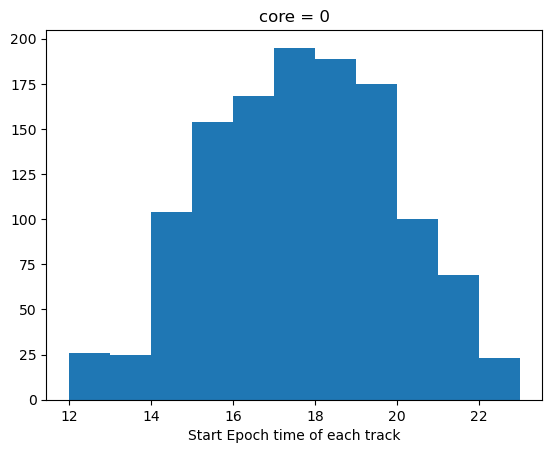

In [15]:
ds_d2.start_basetime.dt.hour.plot.hist(bins=np.arange(12,24,1))
# ds.start_basetime.dt.hour.plot.hist(bins=np.arange(12,24,1))

(array([  6.,  31., 143., 246., 313., 295., 315., 244., 118.,  28.,   9.]),
 array([12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23.]),
 <BarContainer object of 11 artists>)

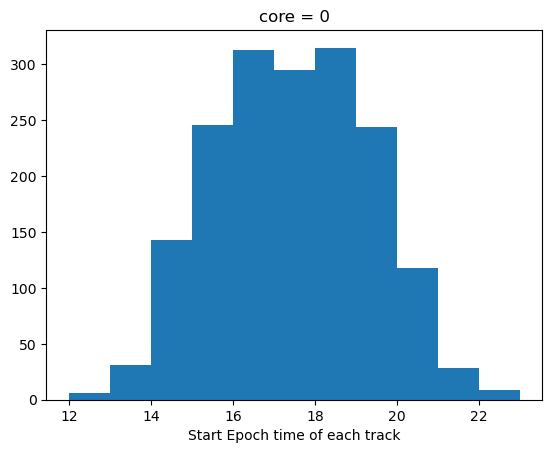

In [16]:
ds_d3.start_basetime.dt.hour.plot.hist(bins=np.arange(12,24,1))

(array([ 12.,  20., 104., 150., 247., 258., 260., 245., 112.,  31.,   3.]),
 array([12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23.]),
 <BarContainer object of 11 artists>)

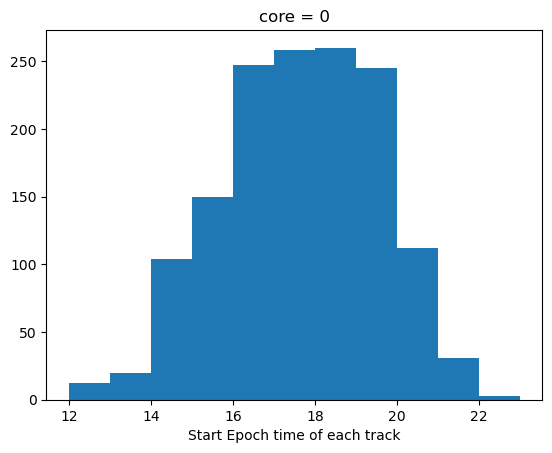

In [17]:
ds_d4.start_basetime.dt.hour.plot.hist(bins=np.arange(12,24,1))

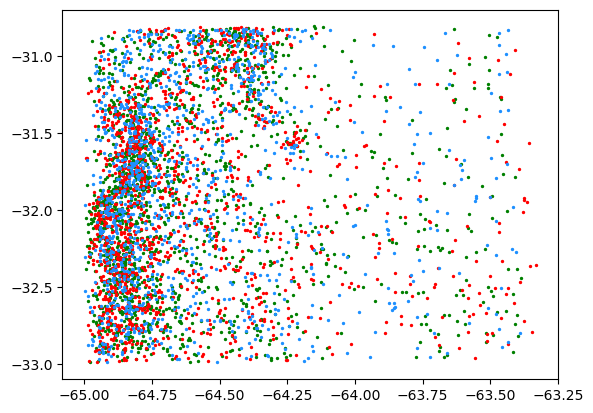

In [18]:
plt.scatter(ds_d3['meanlon'].mean(dim='times'), ds_d3['meanlat'].mean(dim='times'), s=2, c='g')
plt.scatter(ds_d4['meanlon'].mean(dim='times'), ds_d4['meanlat'].mean(dim='times'), s=2, c='r')
plt.scatter(ds_d2['meanlon'].mean(dim='times'), ds_d2['meanlat'].mean(dim='times'), s=2, c='dodgerblue')

## Find merge/split track indices

In [19]:
def find_merge_split_tracks(ds, time_window):
    """
    Find merge/split track indices.
    """
    # Get track lifetime
    lifetime = ds.track_duration.load() * time_res

    # Non-split tracks
    idx_nsplit = np.isnan(ds.start_split_cloudnumber.load())

    # Non-merge tracks
    idx_nmerge = np.isnan(ds.end_merge_cloudnumber.load())

    # Merge after time window tracks
    idx_merge_after = ~np.isnan(ds.end_merge_cloudnumber.load()) & (lifetime > np.max(time_window))

    # Combine conditions (satisfy both):
    # - Non-merge or merge after time window
    # - Non-split
    idx_nms = np.logical_and(idx_nsplit, (np.logical_or(idx_nmerge, idx_merge_after)))

    # Group outputs to dictionary
    out_dict = {
        'ns': idx_nsplit,
        'nm': idx_nmerge,
        'ms': idx_merge_after,
        'nms': idx_nms,
    }
    return out_dict

## Subset DataSets with non-merge/non-split tracks

In [20]:
# Constents common for all Datasets
# time_res = 5.0  # [min]
xtime = ds_d2.times * time_res
# height = ds_d2.z / 1000.
height = ds_d2.height

time_window = (ds_d2.attrs['time_start'], ds_d2.attrs['time_end'])
time_window

(0, 60)

# Modify the first two times (pre-CI) time values (unit: minutes)
## This is hardcoded specific to the average environments files where the extracted time frequencies are 15 min
### Refer to the config files: 
`config_lasso_wrf100m_template.yml`
`config_lasso_wrf500m_template.yml`
`config_lasso_wrf2.5km_template.yml`
- minutes_prior: 30
- freq_prior: 15

In [21]:
xtime.isel(times=slice(0,3))[:] = [-30., -15., 0.]
xtime

<xarray.DataArray 'times' (times: 202)>
array([-30., -15.,   0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,
        45.,  50.,  55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95.,
       100., 105., 110., 115., 120., 125., 130., 135., 140., 145., 150.,
       155., 160., 165., 170., 175., 180., 185., 190., 195., 200., 205.,
       210., 215., 220., 225., 230., 235., 240., 245., 250., 255., 260.,
       265., 270., 275., 280., 285., 290., 295., 300., 305., 310., 315.,
       320., 325., 330., 335., 340., 345., 350., 355., 360., 365., 370.,
       375., 380., 385., 390., 395., 400., 405., 410., 415., 420., 425.,
       430., 435., 440., 445., 450., 455., 460., 465., 470., 475., 480.,
       485., 490., 495., 500., 505., 510., 515., 520., 525., 530., 535.,
       540., 545., 550., 555., 560., 565., 570., 575., 580., 585., 590.,
       595., 600., 605., 610., 615., 620., 625., 630., 635., 640., 645.,
       650., 655., 660., 665., 670., 675., 680., 685., 690., 695., 700.,
       705., 710., 715., 720., 725., 730., 735., 740., 745., 750., 755.,
       760., 765., 770., 775., 780., 785., 790., 795., 800., 805., 810.,
       815., 820., 825., 830., 835., 840., 845., 850., 855., 860., 865.,
       870., 875., 880., 885., 890., 895., 900., 905., 910., 915., 920.,
       925., 930., 935., 940., 945., 950., 955., 960., 965., 970., 975.,
       980., 985., 990., 995.])
Coordinates:
  * times    (times) int64 -2 -1 0 1 2 3 4 5 ... 192 193 194 195 196 197 198 199
    core     int64 0

In [22]:
tid_d2 = find_merge_split_tracks(ds_d2, time_window)
tid_d3 = find_merge_split_tracks(ds_d3, time_window)
tid_d4 = find_merge_split_tracks(ds_d4, time_window)

In [23]:
# Get number of tracks
ntracks_d2 = ds_d2.sizes['tracks']
ntracks_d3 = ds_d3.sizes['tracks']
ntracks_d4 = ds_d4.sizes['tracks']
print(f'D2 all tracks: {ntracks_d2}')
print(f'D3 all tracks: {ntracks_d3}')
print(f'D4 all tracks: {ntracks_d4}')

D2 all tracks: 1228
D3 all tracks: 1748
D4 all tracks: 1442


In [24]:
dsnms_d2 = ds_d2.isel(tracks=tid_d2['nms'])
dsnms_d3 = ds_d3.isel(tracks=tid_d3['nms'])
dsnms_d4 = ds_d4.isel(tracks=tid_d4['nms'])

# Get number of tracks
ntracks_nms_d2 = dsnms_d2.sizes['tracks']
ntracks_nms_d3 = dsnms_d3.sizes['tracks']
ntracks_nms_d4 = dsnms_d4.sizes['tracks']
print(f'D2 non-merge-split tracks: {ntracks_nms_d2} ({100*ntracks_nms_d2/ntracks_d2:.0f}% of all tracks)')
print(f'D3 non-merge-split tracks: {ntracks_nms_d3} ({100*ntracks_nms_d3/ntracks_d3:.0f}% of all tracks)')
print(f'D4 non-merge-split tracks: {ntracks_nms_d4} ({100*ntracks_nms_d4/ntracks_d4:.0f}% of all tracks)')

D2 non-merge-split tracks: 646 (53% of all tracks)
D3 non-merge-split tracks: 1155 (66% of all tracks)
D4 non-merge-split tracks: 1031 (71% of all tracks)


## Check number of merge after time_window tracks

In [25]:
# Tracks where merging occurs after the time_window
lifetime_merge_after_d2 = dsnms_d2.track_duration.where(~np.isnan(dsnms_d2.end_merge_cloudnumber), drop=True) * time_res
minlifetime_merge_after_d2 = lifetime_merge_after_d2.min().values
ntracks_merge_after_d2 = (lifetime_merge_after_d2).sizes['tracks']
print(f'D2 merge after time_window tracks: {ntracks_merge_after_d2}, min lifetime: {minlifetime_merge_after_d2} min')

# Tracks where merging occurs after the time_window
lifetime_merge_after_d3 = dsnms_d3.track_duration.where(~np.isnan(dsnms_d3.end_merge_cloudnumber), drop=True) * time_res
minlifetime_merge_after_d3 = lifetime_merge_after_d3.min().values
ntracks_merge_after_d3 = (lifetime_merge_after_d3).sizes['tracks']
print(f'D3 merge after time_window tracks: {ntracks_merge_after_d3}, min lifetime: {minlifetime_merge_after_d3} min')

# Tracks where merging occurs after the time_window
lifetime_merge_after_d4 = dsnms_d4.track_duration.where(~np.isnan(dsnms_d4.end_merge_cloudnumber), drop=True) * time_res
minlifetime_merge_after_d4 = lifetime_merge_after_d4.min().values
ntracks_merge_after_d4 = (lifetime_merge_after_d4).sizes['tracks']
print(f'D4 merge after time_window tracks: {ntracks_merge_after_d4}, min lifetime: {minlifetime_merge_after_d4} min')

D2 merge after time_window tracks: 83, min lifetime: 65.0 min
D3 merge after time_window tracks: 57, min lifetime: 65.0 min
D4 merge after time_window tracks: 44, min lifetime: 65.0 min


### Convert MU LPL from HAGL to HAMSL and add it back to the DataSets

In [26]:
# Convert MU parcel height from AGL to MSL
mu_parcel_ht_msl_d2 = dsnms_d2.initial_ht_parcel_mu + dsnms_d2.Z_surface
mu_parcel_ht_msl_d3 = dsnms_d3.initial_ht_parcel_mu + dsnms_d3.Z_surface
mu_parcel_ht_msl_d4 = dsnms_d4.initial_ht_parcel_mu + dsnms_d4.Z_surface

mu_parcel_ht_msl_d2.attrs = {
    'long_name': 'Height above MSL of the MU parcel origin',
    'units': 'm',
}
mu_parcel_ht_msl_d3.attrs = {
    'long_name': 'Height above MSL of the MU parcel origin',
    'units': 'm',
}
mu_parcel_ht_msl_d4.attrs = {
    'long_name': 'Height above MSL of the MU parcel origin',
    'units': 'm',
}
# Add to DataSet
dsnms_d2['mu_parcel_ht_msl'] = mu_parcel_ht_msl_d2
dsnms_d3['mu_parcel_ht_msl'] = mu_parcel_ht_msl_d3
dsnms_d4['mu_parcel_ht_msl'] = mu_parcel_ht_msl_d4

(array([144., 129., 234., 201., 228., 303., 159., 279., 162.,  99.]),
 array([ 189.5231781 ,  369.81716919,  550.11114502,  730.40515137,
         910.69915771, 1090.99316406, 1271.28710938, 1451.58117676,
        1631.87512207, 1812.16918945, 1992.46313477]),
 <BarContainer object of 10 artists>)

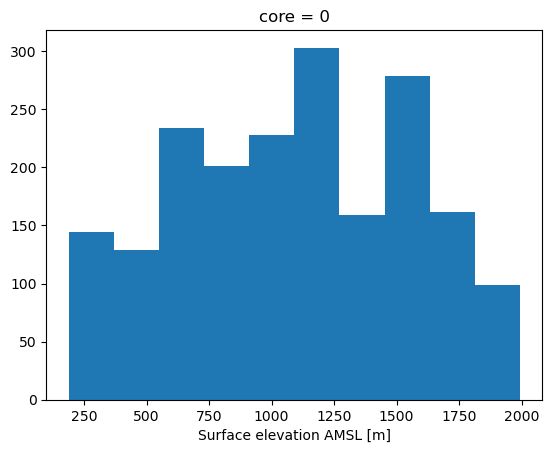

In [27]:
dsnms_d2.Z_surface.sel(times=slice(-2,0)).plot.hist()
# dsnms_d2.initial_ht_parcel_mu.sel(times=slice(-2,0)).plot.hist()
# dsnms_d2.mu_parcel_ht_msl.sel(times=slice(-2,0)).plot.hist()

## Subset cell area/ETH stats to **CI time window** and get their CI-period max values

In [28]:
xtime, time_window

(<xarray.DataArray 'times' (times: 202)>
 array([-30., -15.,   0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,
         45.,  50.,  55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95.,
        100., 105., 110., 115., 120., 125., 130., 135., 140., 145., 150.,
        155., 160., 165., 170., 175., 180., 185., 190., 195., 200., 205.,
        210., 215., 220., 225., 230., 235., 240., 245., 250., 255., 260.,
        265., 270., 275., 280., 285., 290., 295., 300., 305., 310., 315.,
        320., 325., 330., 335., 340., 345., 350., 355., 360., 365., 370.,
        375., 380., 385., 390., 395., 400., 405., 410., 415., 420., 425.,
        430., 435., 440., 445., 450., 455., 460., 465., 470., 475., 480.,
        485., 490., 495., 500., 505., 510., 515., 520., 525., 530., 535.,
        540., 545., 550., 555., 560., 565., 570., 575., 580., 585., 590.,
        595., 600., 605., 610., 615., 620., 625., 630., 635., 640., 645.,
        650., 655., 660., 665., 670., 675., 680., 685., 690., 695., 700

In [29]:
# Find time coordinate index of the time_window
tidx_start = np.abs(xtime - np.min(time_window)).argmin().item()
tidx_end = np.abs(xtime - np.max(time_window)).argmin().item()
print(f"CI time window start index: {tidx_start}, end index: {tidx_end}")

CI time window start index: 2, end index: 14


In [30]:
# Subset DataSet to CI time_window
dsCI_d2 = dsnms_d2.isel(times=slice(tidx_start, tidx_end))
dsCI_d3 = dsnms_d3.isel(times=slice(tidx_start, tidx_end))
dsCI_d4 = dsnms_d4.isel(times=slice(tidx_start, tidx_end))

# Cell max reflectivity
maxdbz_d2 = dsCI_d2['max_dbz'].load()
maxdbz_d3 = dsCI_d3['max_dbz'].load()
maxdbz_d4 = dsCI_d4['max_dbz'].load()
# Cell ETH
maxETH_10dbz_d2 = dsCI_d2['maxETH_10dbz'].load()
maxETH_10dbz_d3 = dsCI_d3['maxETH_10dbz'].load()
maxETH_10dbz_d4 = dsCI_d4['maxETH_10dbz'].load()
# Cell diameter
cellarea_d2 = dsCI_d2['cell_area'].load()
cellarea_d3 = dsCI_d3['cell_area'].load()
cellarea_d4 = dsCI_d4['cell_area'].load()
celldiam_d2 = 2 * np.sqrt(cellarea_d2 / np.pi)
celldiam_d3 = 2 * np.sqrt(cellarea_d3 / np.pi)
celldiam_d4 = 2 * np.sqrt(cellarea_d4 / np.pi)
# Max updraft top height
trackmaxWtop_d2 = dsCI_d2.Wtop.max(dim='times')
trackmaxWtop_d3 = dsCI_d3.Wtop.max(dim='times')
trackmaxWtop_d4 = dsCI_d4.Wtop.max(dim='times')
# Calculate max W diameter (Warea_max has no times dimension)
maxWdiam_d2 = 2*np.sqrt(dsCI_d2.Warea_max/np.pi)
maxWdiam_d3 = 2*np.sqrt(dsCI_d3.Warea_max/np.pi)
maxWdiam_d4 = 2*np.sqrt(dsCI_d4.Warea_max/np.pi)

## Get **CI-max** 10dBZ ETH and cell diameter percentile values

In [31]:
trackmaxETH_10dbz_d2 = maxETH_10dbz_d2.max(dim='times')
trackmaxCellDiam_d2 = celldiam_d2.max(dim='times')
trackmaxdbz_d2 = maxdbz_d2.max(dim='times')

trackmaxETH_10dbz_d3 = maxETH_10dbz_d3.max(dim='times')
trackmaxCellDiam_d3 = celldiam_d3.max(dim='times')
trackmaxdbz_d3 = maxdbz_d3.max(dim='times')

trackmaxETH_10dbz_d4 = maxETH_10dbz_d4.max(dim='times')
trackmaxCellDiam_d4 = celldiam_d4.max(dim='times')
trackmaxdbz_d4 = maxdbz_d4.max(dim='times')

In [32]:
# Add CI-period variables to DataSet
dsnms_d2['CImaxCellDiam'] = trackmaxCellDiam_d2
dsnms_d2['CImaxETH_10dbz'] = trackmaxETH_10dbz_d2
dsnms_d2['CImaxdbz'] = trackmaxdbz_d2
dsnms_d2['CImaxWDiam'] = maxWdiam_d2

# Add CI-period variables to DataSet
dsnms_d3['CImaxCellDiam'] = trackmaxCellDiam_d3
dsnms_d3['CImaxETH_10dbz'] = trackmaxETH_10dbz_d3
dsnms_d3['CImaxdbz'] = trackmaxdbz_d3
dsnms_d3['CImaxWDiam'] = maxWdiam_d3

# Add CI-period variables to DataSet
dsnms_d4['CImaxCellDiam'] = trackmaxCellDiam_d4
dsnms_d4['CImaxETH_10dbz'] = trackmaxETH_10dbz_d4
dsnms_d4['CImaxdbz'] = trackmaxdbz_d4
dsnms_d4['CImaxWDiam'] = maxWdiam_d4

## Separate narrow vs. wide cell DataSets

In [33]:
narrow_diam_d2 = 12.93  # km 
narrow_diam_d3 = 7.05  # km  
narrow_diam_d4 = 7.44  # km

wide_diam_d2 = 15.71  # km
wide_diam_d3 = 9.10  # km
wide_diam_d4 = 8.97  # km

In [34]:
# MU LNB threshold, cells must have LNB > this to be retained in the subsequent analysis
MULNB_thresh = 6.0  # [km]
# Threshold for max distance between updraft base and LCL height [km]
max_Wbase_LCL_dist = 2.0  # [km]
# Threshold for updraft top fit line slope
min_Wtop_slope = 0

(array([450., 104.,  31.,  14.,  13.,   8.,   2.,   6.,   4.,   1.]),
 array([4.17232513e-05, 3.89411902e-01, 7.78782082e-01, 1.16815226e+00,
        1.55752244e+00, 1.94689262e+00, 2.33626280e+00, 2.72563298e+00,
        3.11500316e+00, 3.50437334e+00, 3.89374352e+00]),
 <BarContainer object of 10 artists>)

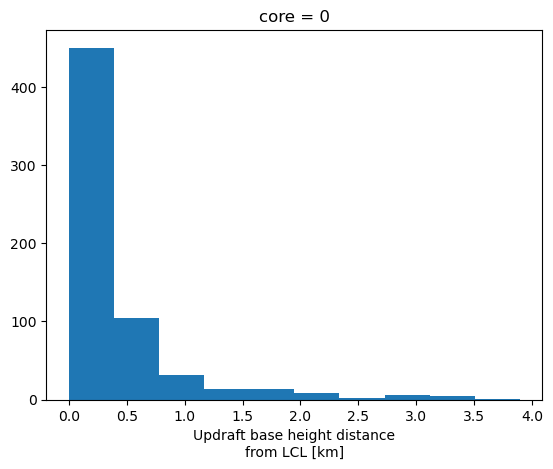

In [35]:
dsnms_d2.Wbase_LCL_diff.plot.hist()

## Get preCI MU LNB

In [36]:
# Select preCI time, the drop the times coordinate (this avoids conflict with cell lifetime-max variables that has no times coordinate)
# Add surface elevation to convert LNB from HAMSL to HAGL
# MULNB_d2 = ((dsnms_d2.EL_height_mu + dsnms_d2.Z_surface).sel(times=time_env)/1000).reset_coords('times', drop=True)
# MULNB_d3 = ((dsnms_d3.EL_height_mu + dsnms_d3.Z_surface).sel(times=time_env)/1000).reset_coords('times', drop=True)
# MULNB_d4 = ((dsnms_d4.EL_height_mu + dsnms_d4.Z_surface).sel(times=time_env)/1000).reset_coords('times', drop=True)
MULNB_d2 = ((dsnms_d2.EL_height_mu).sel(times=time_env)/1000).reset_coords('times', drop=True)
MULNB_d3 = ((dsnms_d3.EL_height_mu).sel(times=time_env)/1000).reset_coords('times', drop=True)
MULNB_d4 = ((dsnms_d4.EL_height_mu).sel(times=time_env)/1000).reset_coords('times', drop=True)

# MUCAPE_d2 = dsnms_d2.pCAPE_mu.sel(times=time_env).reset_coords('times', drop=True)
# MUCAPE_d3 = dsnms_d3.pCAPE_mu.sel(times=time_env).reset_coords('times', drop=True)
# MUCAPE_d4 = dsnms_d4.pCAPE_mu.sel(times=time_env).reset_coords('times', drop=True)

(array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.00195122, 0.        , 0.00195122,
        0.00195122, 0.        , 0.00780488, 0.01560976, 0.03512195,
        0.13073171, 0.30634146, 0.19707317, 0.09365854, 0.03707317,
        0.0097561 , 0.02341463, 0.07414634, 0.08390244, 0.15219512,
        0.19902439, 0.15219512, 0.1404878 , 0.14243902, 0.06439024,
        0.07414634, 0.05463415, 0.        , 0.        , 0.        ,
        0.        ]),
 array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
         5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5,
        11. , 11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. ,
        16.5, 17. , 17.5, 18. ]),
 <BarContainer object of 36 artists>)

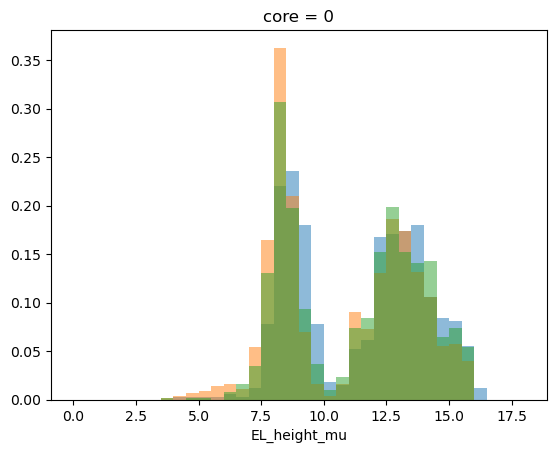

In [37]:
bins = np.arange(0, 18.1, 0.5)
MULNB_d2.plot.hist(bins=bins, alpha=0.5, label='D2', density=True)
MULNB_d3.plot.hist(bins=bins, alpha=0.5, label='D3', density=True)
MULNB_d4.plot.hist(bins=bins, alpha=0.5, label='D4', density=True)

In [38]:
# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
# 3. Updraft base height close to LCL
narrow_tracks_d2 = ((dsnms_d2.CImaxCellDiam < narrow_diam_d2) & (MULNB_d2 > MULNB_thresh) \
                    & (dsnms_d2.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d2 = ((dsnms_d2.CImaxCellDiam >= wide_diam_d2) & (MULNB_d2 > MULNB_thresh) \
                  & (dsnms_d2.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d2.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_d2 = dsnms_d2.where(narrow_tracks_d2, drop=True)
ds_wide_d2 = dsnms_d2.where(wide_tracks_d2, drop=True)
ntracks_narrow_d2 = ds_narrow_d2.sizes['tracks']
ntracks_wide_d2 = ds_wide_d2.sizes['tracks']
print(f'Number of narrow cells (D2): {ntracks_narrow_d2}')
print(f'Number of wide cells (D2): {ntracks_wide_d2}')

# CI-window lifetime (count number of time a cell exists in the CI window)
narrow_track_lifetime_d2 = (ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
wide_track_lifetime_d2 = (ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# CI-max reflectivity
narrow_maxdbz_d2 = ds_narrow_d2.CImaxdbz
wide_maxdbz_d2 = ds_wide_d2.CImaxdbz
# CI-max 10dBZ ETH
narrow_maxETH10dbz_d2 = ds_narrow_d2.CImaxETH_10dbz
wide_maxETH10dbz_d2 = ds_wide_d2.CImaxETH_10dbz
# CI-max cell diameter
narrow_maxdiam_d2 = ds_narrow_d2.CImaxCellDiam
wide_maxdiam_d2 = ds_wide_d2.CImaxCellDiam
# CI-window cloud-base updraft diameter
narrow_maxWdiam_d2 = ds_narrow_d2.CImaxWDiam
wide_maxWdiam_d2 = ds_wide_d2.CImaxWDiam
# CI-window cloud-base updraft speed
narrow_maxWspeed_d2 = ds_narrow_d2.Wspeed_max
wide_maxWspeed_d2 = ds_wide_d2.Wspeed_max

Number of narrow cells (D2): 425
Number of wide cells (D2): 84


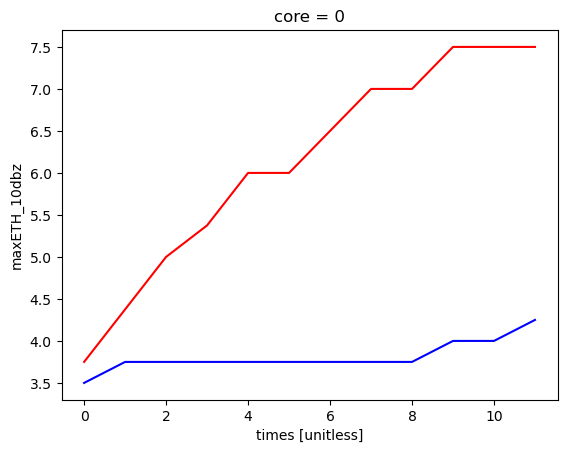

In [39]:
ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.median(dim='tracks').plot(color='b')
ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.median(dim='tracks').plot(color='r')

(array([ 0.,  0.,  0.,  1.,  0., 13.,  6., 12., 14., 13.,  7.,  3.,  5.,
         5.,  3.,  2.,  0.,  0.,  0.,  0.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20.]),
 <BarContainer object of 20 artists>)

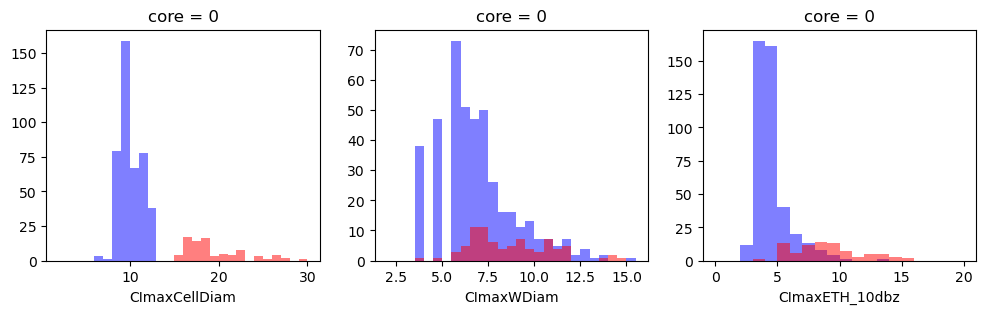

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(12,3), dpi=100)
ax0 = axes[0]
bins = np.arange(2, 31, 1)
narrow_maxdiam_d2.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax0)
wide_maxdiam_d2.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax0)
ax1 = axes[1]
bins = np.arange(2, 16, 0.5)
narrow_maxWdiam_d2.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax1)
wide_maxWdiam_d2.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax1)
ax2 = axes[2]
bins = np.arange(0, 21, 1)
narrow_maxETH10dbz_d2.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax2)
wide_maxETH10dbz_d2.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax2)

In [41]:
# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
# 3. Updraft base height close to LCL
narrow_tracks_d3 = ((dsnms_d3.CImaxCellDiam < narrow_diam_d3) & (MULNB_d3 > MULNB_thresh) \
                    & (dsnms_d3.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d3 = ((dsnms_d3.CImaxCellDiam >= wide_diam_d3) & (MULNB_d3 > MULNB_thresh) \
                  & (dsnms_d3.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d3.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_d3 = dsnms_d3.where(narrow_tracks_d3, drop=True)
ds_wide_d3 = dsnms_d3.where(wide_tracks_d3, drop=True)
ntracks_narrow_d3 = ds_narrow_d3.sizes['tracks']
ntracks_wide_d3 = ds_wide_d3.sizes['tracks']
print(f'Number of narrow cells (d3): {ntracks_narrow_d3}')
print(f'Number of wide cells (d3): {ntracks_wide_d3}')

# CI-window lifetime (count number of time a cell exists in the CI window)
narrow_track_lifetime_d3 = (ds_narrow_d3.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
wide_track_lifetime_d3 = (ds_wide_d3.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# CI-max reflectivity
narrow_maxdbz_d3 = ds_narrow_d3.CImaxdbz
wide_maxdbz_d3 = ds_wide_d3.CImaxdbz
# CI-max 10dBZ ETH
narrow_maxETH10dbz_d3 = ds_narrow_d3.CImaxETH_10dbz
wide_maxETH10dbz_d3 = ds_wide_d3.CImaxETH_10dbz
# CI-max cell diameter
narrow_maxdiam_d3 = ds_narrow_d3.CImaxCellDiam
wide_maxdiam_d3 = ds_wide_d3.CImaxCellDiam
# CI-window cloud-base updraft diameter
narrow_maxWdiam_d3 = ds_narrow_d3.CImaxWDiam
wide_maxWdiam_d3 = ds_wide_d3.CImaxWDiam
# CI-window cloud-base updraft speed
narrow_maxWspeed_d3 = ds_narrow_d3.Wspeed_max
wide_maxWspeed_d3 = ds_wide_d3.Wspeed_max

Number of narrow cells (d3): 713
Number of wide cells (d3): 218


(array([ 0.,  0.,  0.,  0.,  0.,  0.,  6., 14., 16., 63., 52., 25., 18.,
        12.,  8.,  1.,  3.,  0.,  0.,  0.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20.]),
 <BarContainer object of 20 artists>)

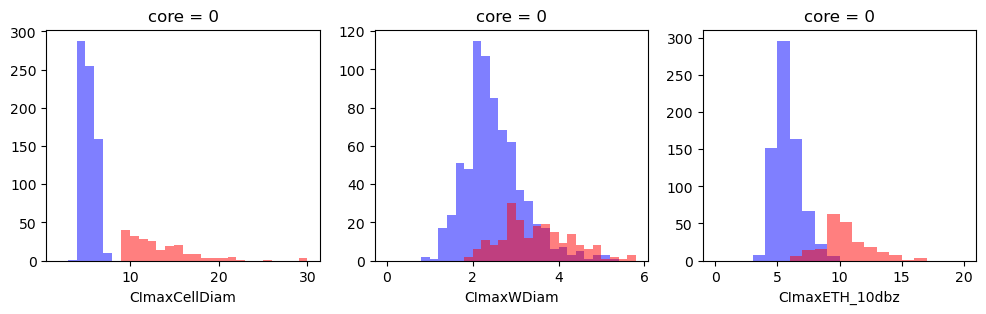

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(12,3), dpi=100)
ax0 = axes[0]
bins = np.arange(2, 31, 1)
narrow_maxdiam_d3.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax0)
wide_maxdiam_d3.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax0)
ax1 = axes[1]
bins = np.arange(0, 6, 0.2)
narrow_maxWdiam_d3.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax1)
wide_maxWdiam_d3.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax1)
ax2 = axes[2]
bins = np.arange(0, 21, 1)
narrow_maxETH10dbz_d3.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax2)
wide_maxETH10dbz_d3.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax2)

In [43]:
# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
# 3. Updraft base height close to LCL
narrow_tracks_d4 = ((dsnms_d4.CImaxCellDiam < narrow_diam_d4) & (MULNB_d4 > MULNB_thresh) \
                    & (dsnms_d4.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d4 = ((dsnms_d4.CImaxCellDiam >= wide_diam_d4) & (MULNB_d4 > MULNB_thresh) \
                  & (dsnms_d4.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d4.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_d4 = dsnms_d4.where(narrow_tracks_d4, drop=True)
ds_wide_d4 = dsnms_d4.where(wide_tracks_d4, drop=True)
ntracks_narrow_d4 = ds_narrow_d4.sizes['tracks']
ntracks_wide_d4 = ds_wide_d4.sizes['tracks']
print(f'Number of narrow cells (d4): {ntracks_narrow_d4}')
print(f'Number of wide cells (d4): {ntracks_wide_d4}')

# CI-window lifetime (count number of time a cell exists in the CI window)
narrow_track_lifetime_d4 = (ds_narrow_d4.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
wide_track_lifetime_d4 = (ds_wide_d4.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# CI-max reflectivity
narrow_maxdbz_d4 = ds_narrow_d4.CImaxdbz
wide_maxdbz_d4 = ds_wide_d4.CImaxdbz
# CI-max 10dBZ ETH
narrow_maxETH10dbz_d4 = ds_narrow_d4.CImaxETH_10dbz
wide_maxETH10dbz_d4 = ds_wide_d4.CImaxETH_10dbz
# CI-max cell diameter
narrow_maxdiam_d4 = ds_narrow_d4.CImaxCellDiam
wide_maxdiam_d4 = ds_wide_d4.CImaxCellDiam
# CI-window cloud-base updraft diameter
narrow_maxWdiam_d4 = ds_narrow_d4.CImaxWDiam
wide_maxWdiam_d4 = ds_wide_d4.CImaxWDiam
# CI-window cloud-base updraft speed
narrow_maxWspeed_d4 = ds_narrow_d4.Wspeed_max
wide_maxWspeed_d4 = ds_wide_d4.Wspeed_max

Number of narrow cells (d4): 707
Number of wide cells (d4): 190


(array([ 0.,  0.,  0.,  0.,  1.,  2.,  9., 19., 39., 52., 30.,  9., 11.,
         6.,  4.,  8.,  0.,  0.,  0.,  0.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20.]),
 <BarContainer object of 20 artists>)

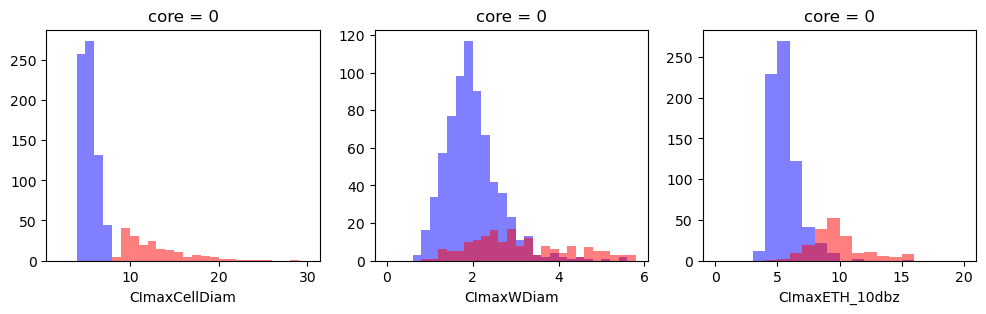

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(12,3), dpi=100)
ax0 = axes[0]
bins = np.arange(2, 31, 1)
narrow_maxdiam_d4.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax0)
wide_maxdiam_d4.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax0)
ax1 = axes[1]
bins = np.arange(0, 6, 0.2)
narrow_maxWdiam_d4.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax1)
wide_maxWdiam_d4.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax1)
ax2 = axes[2]
bins = np.arange(0, 21, 1)
narrow_maxETH10dbz_d4.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax2)
wide_maxETH10dbz_d4.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax2)

# TODO: This is where futher filtering of cells based on updraft properties can be added

## Find median lifetime-max 10-dBZ ETH as threshold to further separate shallow vs. deep cells for narrow vs. wide DataSets separately

## Get lifetime-max 10-dBZ ETH median values as shallow vs. deep cell threhsolds for both narrow & wide cells

In [45]:
# max10dbz_pts_d2 = trackmaxETH_10dbz_d2.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
# print(f"Max 10dBZ percentile values (D2): {max10dbz_pts_d2.values}")

In [46]:
maxETH10dbz_thresh_d2 = trackmaxETH_10dbz_d2.quantile(0.5).item()
print(f"D2 all cells max 10dBZ ETH threshold: {maxETH10dbz_thresh_d2} km")

maxETH10dbz_thresh_d3 = trackmaxETH_10dbz_d3.quantile(0.5).item()
print(f"D3 all cells max 10dBZ ETH threshold: {maxETH10dbz_thresh_d3} km")

maxETH10dbz_thresh_d4 = trackmaxETH_10dbz_d4.quantile(0.5).item()
print(f"D4 all cells max 10dBZ ETH threshold: {maxETH10dbz_thresh_d4} km")

D2 all cells max 10dBZ ETH threshold: 4.5 km
D3 all cells max 10dBZ ETH threshold: 6.0 km
D4 all cells max 10dBZ ETH threshold: 5.5 km


### D2 wide cell DataSet

In [47]:
wide_maxETH10dbz_d2.sizes, ds_wide_d2.sizes

(Frozen({'tracks': 84}),
 Frozen({'tracks': 84, 'times': 202, 'height': 101, 'z': 40}))

In [48]:
# Get median lifetime-max 10dBZ ETH as threshold to further separate shallow vs. deep cells
wide_maxETH10dbz_thresh_d2 = wide_maxETH10dbz_d2.median()
print(f'D2 wide cells 10-dBZ ETH median: {wide_maxETH10dbz_thresh_d2:.01f} km')

# Separate shallow & deep DataSets
ds_wide_deep_d2 = ds_wide_d2.where(wide_maxETH10dbz_d2 > wide_maxETH10dbz_thresh_d2, drop=True)
ds_wide_shallow_d2 = ds_wide_d2.where(wide_maxETH10dbz_d2 <= wide_maxETH10dbz_thresh_d2, drop=True)

# Get number of tracks
ntracks_wide_deep_d2 = ds_wide_deep_d2.sizes['tracks']
ntracks_wide_shallow_d2 = ds_wide_shallow_d2.sizes['tracks']
print(f'D2 number of wide & deep tracks: {ntracks_wide_deep_d2}')
print(f'D2 number of wide & shallow tracks: {ntracks_wide_shallow_d2}')

D2 wide cells 10-dBZ ETH median: 8.0 km
D2 number of wide & deep tracks: 38
D2 number of wide & shallow tracks: 46


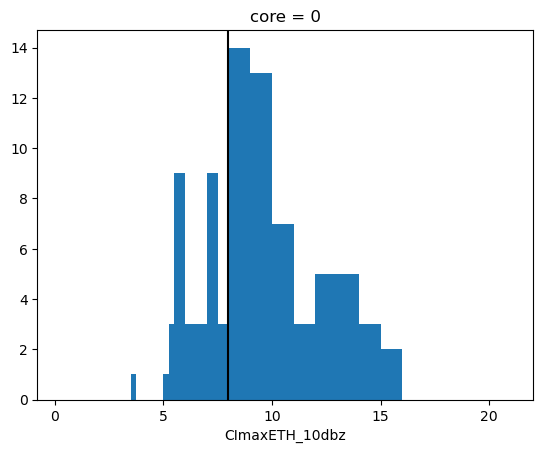

In [49]:
z_km = ds_d4.z/1000
wide_maxETH10dbz_d2.plot.hist(bins=z_km)
plt.axvline(wide_maxETH10dbz_thresh_d2, color='k')

### D2 narrow cell DataSet

In [50]:
# Get median lifetime-max 10dBZ ETH as threshold to further separate shallow vs. deep cells
narrow_maxETH10dbz_thresh_d2 = narrow_maxETH10dbz_d2.median()
print(f'D2 narrow cells 10-dBZ ETH median: {narrow_maxETH10dbz_thresh_d2:.01f} km')

# Separate shallow & deep DataSets
ds_narrow_deep_d2 = ds_narrow_d2.where(narrow_maxETH10dbz_d2 > narrow_maxETH10dbz_thresh_d2, drop=True)
ds_narrow_shallow_d2 = ds_narrow_d2.where(narrow_maxETH10dbz_d2 <= narrow_maxETH10dbz_thresh_d2, drop=True)

# Get number of tracks
ntracks_narrow_deep_d2 = ds_narrow_deep_d2.sizes['tracks']
ntracks_narrow_shallow_d2 = ds_narrow_shallow_d2.sizes['tracks']
print(f'D2 number of narrow & deep tracks: {ntracks_narrow_deep_d2}')
print(f'D2 number of narrow & shallow tracks: {ntracks_narrow_shallow_d2}')

D2 narrow cells 10-dBZ ETH median: 4.0 km
D2 number of narrow & deep tracks: 199
D2 number of narrow & shallow tracks: 226


### D3 wide cell DataSet

In [51]:
# Get median lifetime-max 10dBZ ETH as threshold to further separate shallow vs. deep cells
wide_maxETH10dbz_thresh_d3 = wide_maxETH10dbz_d3.median()
print(f'd3 wide cells 10-dBZ ETH median: {wide_maxETH10dbz_thresh_d3:.01f} km')

# Separate shallow & deep DataSets
ds_wide_deep_d3 = ds_wide_d3.where(wide_maxETH10dbz_d3 >= wide_maxETH10dbz_thresh_d3, drop=True)
ds_wide_shallow_d3 = ds_wide_d3.where(wide_maxETH10dbz_d3 < wide_maxETH10dbz_thresh_d3, drop=True)

# Get number of tracks
ntracks_wide_deep_d3 = ds_wide_deep_d3.sizes['tracks']
ntracks_wide_shallow_d3 = ds_wide_shallow_d3.sizes['tracks']
print(f'D3 number of wide & deep tracks: {ntracks_wide_deep_d3}')
print(f'D3 number of wide & shallow tracks: {ntracks_wide_shallow_d3}')

d3 wide cells 10-dBZ ETH median: 10.0 km
D3 number of wide & deep tracks: 119
D3 number of wide & shallow tracks: 99


### D3 narrow cell DataSet

In [52]:
# Get median lifetime-max 10dBZ ETH as threshold to further separate shallow vs. deep cells
narrow_maxETH10dbz_thresh_d3 = narrow_maxETH10dbz_d3.median()
print(f'd3 narrow cells 10-dBZ ETH median: {narrow_maxETH10dbz_thresh_d3:.01f} km')

# Separate shallow & deep DataSets
ds_narrow_deep_d3 = ds_narrow_d3.where(narrow_maxETH10dbz_d3 >= narrow_maxETH10dbz_thresh_d3, drop=True)
ds_narrow_shallow_d3 = ds_narrow_d3.where(narrow_maxETH10dbz_d3 < narrow_maxETH10dbz_thresh_d3, drop=True)

# Get number of tracks
ntracks_narrow_deep_d3 = ds_narrow_deep_d3.sizes['tracks']
ntracks_narrow_shallow_d3 = ds_narrow_shallow_d3.sizes['tracks']
print(f'D3 number of narrow & deep tracks: {ntracks_narrow_deep_d3}')
print(f'D3 number of narrow & shallow tracks: {ntracks_narrow_shallow_d3}')

d3 narrow cells 10-dBZ ETH median: 5.5 km
D3 number of narrow & deep tracks: 384
D3 number of narrow & shallow tracks: 329


### D4 wide cell DataSet

In [53]:
# Get median lifetime-max 10dBZ ETH as threshold to further separate shallow vs. deep cells
wide_maxETH10dbz_thresh_d4 = wide_maxETH10dbz_d4.median()
print(f'd4 wide cells 10-dBZ ETH median: {wide_maxETH10dbz_thresh_d4:.01f} km')

# Separate shallow & deep DataSets
ds_wide_deep_d4 = ds_wide_d4.where(wide_maxETH10dbz_d4 >= wide_maxETH10dbz_thresh_d4, drop=True)
ds_wide_shallow_d4 = ds_wide_d4.where(wide_maxETH10dbz_d4 < wide_maxETH10dbz_thresh_d4, drop=True)

# Get number of tracks
ntracks_wide_deep_d4 = ds_wide_deep_d4.sizes['tracks']
ntracks_wide_shallow_d4 = ds_wide_shallow_d4.sizes['tracks']
print(f'D4 number of wide & deep tracks: {ntracks_wide_deep_d4}')
print(f'D4 number of wide & shallow tracks: {ntracks_wide_shallow_d4}')

d4 wide cells 10-dBZ ETH median: 9.0 km
D4 number of wide & deep tracks: 120
D4 number of wide & shallow tracks: 70


### D4 narrow cell DataSet

In [54]:
# Get median lifetime-max 10dBZ ETH as threshold to further separate shallow vs. deep cells
narrow_maxETH10dbz_thresh_d4 = narrow_maxETH10dbz_d4.median()
print(f'd4 narrow cells 10-dBZ ETH median: {narrow_maxETH10dbz_thresh_d4:.01f} km')

# Separate shallow & deep DataSets
ds_narrow_deep_d4 = ds_narrow_d4.where(narrow_maxETH10dbz_d4 >= narrow_maxETH10dbz_thresh_d4, drop=True)
ds_narrow_shallow_d4 = ds_narrow_d4.where(narrow_maxETH10dbz_d4 < narrow_maxETH10dbz_thresh_d4, drop=True)

# Get number of tracks
ntracks_narrow_deep_d4 = ds_narrow_deep_d4.sizes['tracks']
ntracks_narrow_shallow_d4 = ds_narrow_shallow_d4.sizes['tracks']
print(f'D4 number of narrow & deep tracks: {ntracks_narrow_deep_d4}')
print(f'D4 number of narrow & shallow tracks: {ntracks_narrow_shallow_d4}')

d4 narrow cells 10-dBZ ETH median: 5.2 km
D4 number of narrow & deep tracks: 373
D4 number of narrow & shallow tracks: 334


Text(0.5, 1.0, 'D4')

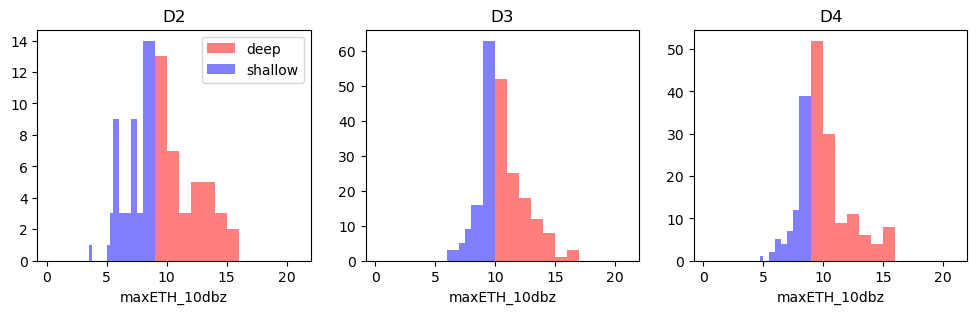

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(12,3), dpi=100)
# bins = np.arange(0, 18.1, 0.5)
bins = ds_d2.z.values/1000.
ax1 = axes[0]
ds_wide_deep_d2.maxETH_10dbz.isel(times=slice(tidx_start, tidx_end)).max(dim='times').plot.hist(bins=bins, color='r', alpha=0.5, ax=ax1, label='deep')
ds_wide_shallow_d2.maxETH_10dbz.isel(times=slice(tidx_start, tidx_end)).max(dim='times').plot.hist(bins=bins, color='b', alpha=0.5, ax=ax1, label='shallow')
ax1.legend()
ax1.set_title('D2')
ax2 = axes[1]
ds_wide_deep_d3.maxETH_10dbz.isel(times=slice(tidx_start, tidx_end)).max(dim='times').plot.hist(bins=bins, color='r', alpha=0.5, ax=ax2)
ds_wide_shallow_d3.maxETH_10dbz.isel(times=slice(tidx_start, tidx_end)).max(dim='times').plot.hist(bins=bins, color='b', alpha=0.5, ax=ax2)
ax2.set_title('D3')
ax3 = axes[2]
ds_wide_deep_d4.maxETH_10dbz.isel(times=slice(tidx_start, tidx_end)).max(dim='times').plot.hist(bins=bins, color='r', alpha=0.5, ax=ax3)
ds_wide_shallow_d4.maxETH_10dbz.isel(times=slice(tidx_start, tidx_end)).max(dim='times').plot.hist(bins=bins, color='b', alpha=0.5, ax=ax3)
ax3.set_title('D4')

Text(0.5, 1.0, 'D4')

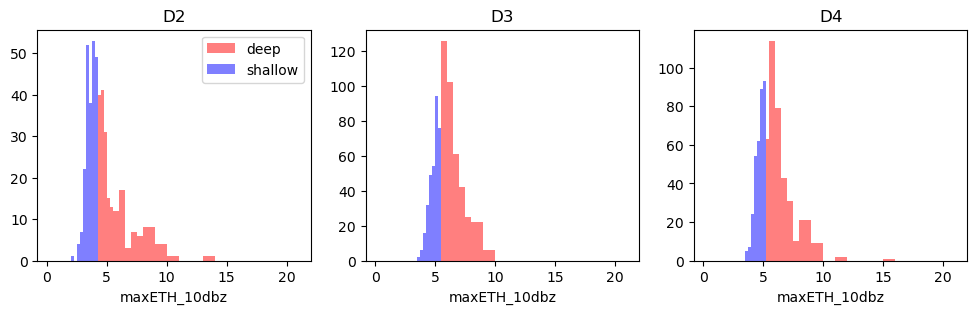

In [56]:
# bins = np.arange(0, 18.1, 1)
# ds_narrow_deep_d2.maxETH_10dbz.max(dim='times').plot.hist(bins=bins, color='r', alpha=0.5)
# ds_narrow_shallow_d2.maxETH_10dbz.max(dim='times').plot.hist(bins=bins, color='b', alpha=0.5)

fig, axes = plt.subplots(1, 3, figsize=(12,3), dpi=100)
# bins = np.arange(0, 18.1, 0.5)
bins = ds_d2.z.values/1000.
ax1 = axes[0]
ds_narrow_deep_d2.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times').plot.hist(bins=bins, color='r', alpha=0.5, ax=ax1, label='deep')
ds_narrow_shallow_d2.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times').plot.hist(bins=bins, color='b', alpha=0.5, ax=ax1, label='shallow')
ax1.legend()
ax1.set_title('D2')
ax2 = axes[1]
ds_narrow_deep_d3.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times').plot.hist(bins=bins, color='r', alpha=0.5, ax=ax2)
ds_narrow_shallow_d3.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times').plot.hist(bins=bins, color='b', alpha=0.5, ax=ax2)
ax2.set_title('D3')
ax3 = axes[2]
ds_narrow_deep_d4.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times').plot.hist(bins=bins, color='r', alpha=0.5, ax=ax3)
ds_narrow_shallow_d4.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times').plot.hist(bins=bins, color='b', alpha=0.5, ax=ax3)
ax3.set_title('D4')

## Composite DataSets to get mean

In [57]:
# preCI_nt = -12  # number of preCI times
preCI_nt = -2  # number of preCI times
xtime_preCI = xtime.sel(times=slice(preCI_nt,0))
xtime_preCI

<xarray.DataArray 'times' (times: 3)>
array([-30., -15.,   0.])
Coordinates:
  * times    (times) int64 -2 -1 0
    core     int64 0

In [58]:
# ds_wide_deep_avg_d2 = ds_wide_deep_d2.sel(times=slice(preCI_nt,0)).mean(dim='tracks').transpose()
# ds_wide_shallow_avg_d2 = ds_wide_shallow_d2.sel(times=slice(preCI_nt,0)).mean(dim='tracks').transpose()

In [59]:
# ds_narrow_deep_avg_d2 = ds_narrow_deep_d2.sel(times=slice(preCI_nt,0)).mean(dim='tracks').transpose()
# ds_narrow_shallow_avg_d2 = ds_narrow_shallow_d2.sel(times=slice(preCI_nt,0)).mean(dim='tracks').transpose()

In [60]:
# ds_narrow_avg_d3 = ds_narrow_d3.sel(times=slice(preCI_nt,0)).isel(core=0).mean(dim='tracks').transpose()
# ds_wide_avg_d3 = ds_wide_d3.sel(times=slice(preCI_nt,0)).isel(core=0).mean(dim='tracks').transpose()

In [63]:
# ds_narrow_avg_d4 = ds_narrow_d4.sel(times=slice(preCI_nt,0)).isel(core=0).mean(dim='tracks').transpose()
# ds_wide_avg_d4 = ds_wide_d4.sel(times=slice(preCI_nt,0)).isel(core=0).mean(dim='tracks').transpose()

In [64]:
def theta_e_bolton(TEMPERATURE, QVAPOR, PRESSURE):
    # theta-e following Bolton (1980); error of < 0.3 K between -35 and 35C; from Thompson scheme
    # more accurate formula from Emanuel could be implemented; ice effects also excluded
    es = PRESSURE*QVAPOR/(0.622*QVAPOR)
    TDEW = (35.86*np.log(es) - 4947.2325)/(np.log(es) - 23.6837)
    TLCL = 1/(1/(TDEW - 56) + np.log(TEMPERATURE/TDEW)/800) + 56
    p1 = 3.376/TLCL - 0.00254
    p2 = 1e3*QVAPOR*(1 + 0.81*QVAPOR)
    THETAE_Bolton = (TEMPERATURE*(100000./PRESSURE)**(0.2854*(1 - 0.28*QVAPOR)))*np.exp(p1*p2) #K
    return THETAE_Bolton

In [65]:
def calc_thetas(ds, preCI_nt):
    # Get T, P, Qv profiles pre-CI
    temp = ds.temperature.sel(times=slice(preCI_nt,0))
    pres = ds.pressure.sel(times=slice(preCI_nt,0))
    qv = ds.qv.sel(times=slice(preCI_nt,0))
    # Compute Theta
    Theta = temp * (1e5 / pres)**0.286
    # Compute ThetaE
    ThetaE = theta_e_bolton(temp, qv, pres)
    return (Theta, ThetaE)

In [66]:
# # Get domain min Theta, ThetaE
# Theta_narrow_deep_d2 = ds_narrow_deep_d2.theta_min.sel(times=slice(preCI_nt,0))
# ThetaE_narrow_deep_d2 = ds_narrow_deep_d2.thetaE_min.sel(times=slice(preCI_nt,0))
# Theta_narrow_shallow_d2 = ds_narrow_shallow_d2.theta_min.sel(times=slice(preCI_nt,0))
# ThetaE_narrow_shallow_d2 = ds_narrow_shallow_d2.thetaE_min.sel(times=slice(preCI_nt,0))

In [87]:
# # Calculate Theta & ThetaE
# Theta_wide_deep_d2, ThetaE_wide_deep_d2 = calc_thetas(ds_wide_deep_d2, preCI_nt)
# Theta_wide_shallow_d2, ThetaE_wide_shallow_d2 = calc_thetas(ds_wide_shallow_d2, preCI_nt)
# Get domain min Theta, ThetaE
Theta_wide_deep_d2 = ds_wide_deep_d2.theta_min.sel(times=slice(preCI_nt,0))
ThetaE_wide_deep_d2 = ds_wide_deep_d2.thetaE_min.sel(times=slice(preCI_nt,0))
Theta_wide_shallow_d2 = ds_wide_shallow_d2.theta_min.sel(times=slice(preCI_nt,0))
ThetaE_wide_shallow_d2 = ds_wide_shallow_d2.thetaE_min.sel(times=slice(preCI_nt,0))
# Number of samples in the tracks composite
ns_wide_deep_d2 = (ds_wide_deep_d2.temperature.sel(times=slice(preCI_nt,0)) > 0).sum(dim='tracks')
ns_wide_shallow_d2 = (ds_wide_shallow_d2.temperature.sel(times=slice(preCI_nt,0)) > 0).sum(dim='tracks')

# # Calculate Theta & ThetaE
# Theta_narrow_deep_d2, ThetaE_narrow_deep_d2 = calc_thetas(ds_narrow_deep_d2, preCI_nt)
# Theta_narrow_shallow_d2, ThetaE_narrow_shallow_d2 = calc_thetas(ds_narrow_shallow_d2, preCI_nt)
# Get domain min Theta, ThetaE
Theta_narrow_deep_d2 = ds_narrow_deep_d2.theta_min.sel(times=slice(preCI_nt,0))
ThetaE_narrow_deep_d2 = ds_narrow_deep_d2.thetaE_min.sel(times=slice(preCI_nt,0))
Theta_narrow_shallow_d2 = ds_narrow_shallow_d2.theta_min.sel(times=slice(preCI_nt,0))
ThetaE_narrow_shallow_d2 = ds_narrow_shallow_d2.thetaE_min.sel(times=slice(preCI_nt,0))
# Number of samples in the tracks composite
ns_narrow_deep_d2 = (ds_narrow_deep_d2.temperature.sel(times=slice(preCI_nt,0)) > 0).sum(dim='tracks')
ns_narrow_shallow_d2 = (ds_narrow_shallow_d2.temperature.sel(times=slice(preCI_nt,0)) > 0).sum(dim='tracks')

In [67]:
# ns_narrow_deep_d2.plot()

In [88]:
# # Calculate Theta & ThetaE
# Theta_wide_deep_d3, ThetaE_wide_deep_d3 = calc_thetas(ds_wide_deep_d3, preCI_nt)
# Theta_wide_shallow_d3, ThetaE_wide_shallow_d3 = calc_thetas(ds_wide_shallow_d3, preCI_nt)
# Get domain min Theta, ThetaE
Theta_wide_deep_d3 = ds_wide_deep_d3.theta_min.sel(times=slice(preCI_nt,0))
ThetaE_wide_deep_d3 = ds_wide_deep_d3.thetaE_min.sel(times=slice(preCI_nt,0))
Theta_wide_shallow_d3 = ds_wide_shallow_d3.theta_min.sel(times=slice(preCI_nt,0))
ThetaE_wide_shallow_d3 = ds_wide_shallow_d3.thetaE_min.sel(times=slice(preCI_nt,0))
# Number of samples in the tracks composite
ns_wide_deep_d3 = (ds_wide_deep_d3.temperature.sel(times=slice(preCI_nt,0)) > 0).sum(dim='tracks')
ns_wide_shallow_d3 = (ds_wide_shallow_d3.temperature.sel(times=slice(preCI_nt,0)) > 0).sum(dim='tracks')

# # Calculate Theta & ThetaE
# Theta_narrow_deep_d3, ThetaE_narrow_deep_d3 = calc_thetas(ds_narrow_deep_d3, preCI_nt)
# Theta_narrow_shallow_d3, ThetaE_narrow_shallow_d3 = calc_thetas(ds_narrow_shallow_d3, preCI_nt)
# Get domain min Theta, ThetaE
Theta_narrow_deep_d3 = ds_narrow_deep_d3.theta_min.sel(times=slice(preCI_nt,0))
ThetaE_narrow_deep_d3 = ds_narrow_deep_d3.thetaE_min.sel(times=slice(preCI_nt,0))
Theta_narrow_shallow_d3 = ds_narrow_shallow_d3.theta_min.sel(times=slice(preCI_nt,0))
ThetaE_narrow_shallow_d3 = ds_narrow_shallow_d3.thetaE_min.sel(times=slice(preCI_nt,0))
# Number of samples in the tracks composite
ns_narrow_deep_d3 = (ds_narrow_deep_d3.temperature.sel(times=slice(preCI_nt,0)) > 0).sum(dim='tracks')
ns_narrow_shallow_d3 = (ds_narrow_shallow_d3.temperature.sel(times=slice(preCI_nt,0)) > 0).sum(dim='tracks')

In [103]:
# # Calculate Theta & ThetaE
# Theta_wide_deep_d4, ThetaE_wide_deep_d4 = calc_thetas(ds_wide_deep_d4, preCI_nt)
# Theta_wide_shallow_d4, ThetaE_wide_shallow_d4 = calc_thetas(ds_wide_shallow_d4, preCI_nt)
# Get domain min Theta, ThetaE
Theta_wide_deep_d4 = ds_wide_deep_d4.theta_min.sel(times=slice(preCI_nt,0))
ThetaE_wide_deep_d4 = ds_wide_deep_d4.thetaE_min.sel(times=slice(preCI_nt,0))
Theta_wide_shallow_d4 = ds_wide_shallow_d4.theta_min.sel(times=slice(preCI_nt,0))
ThetaE_wide_shallow_d4 = ds_wide_shallow_d4.thetaE_min.sel(times=slice(preCI_nt,0))
# Number of samples in the tracks composite
ns_wide_deep_d4 = (ds_wide_deep_d4.temperature.sel(times=slice(preCI_nt,0)) > 0).sum(dim='tracks')
ns_wide_shallow_d4 = (ds_wide_shallow_d4.temperature.sel(times=slice(preCI_nt,0)) > 0).sum(dim='tracks')

# # Calculate Theta & ThetaE
# Theta_narrow_deep_d4, ThetaE_narrow_deep_d4 = calc_thetas(ds_narrow_deep_d4, preCI_nt)
# Theta_narrow_shallow_d4, ThetaE_narrow_shallow_d4 = calc_thetas(ds_narrow_shallow_d4, preCI_nt)
# Get domain min Theta, ThetaE
Theta_narrow_deep_d4 = ds_narrow_deep_d4.theta_min.sel(times=slice(preCI_nt,0))
ThetaE_narrow_deep_d4 = ds_narrow_deep_d4.thetaE_min.sel(times=slice(preCI_nt,0))
Theta_narrow_shallow_d4 = ds_narrow_shallow_d4.theta_min.sel(times=slice(preCI_nt,0))
ThetaE_narrow_shallow_d4 = ds_narrow_shallow_d4.thetaE_min.sel(times=slice(preCI_nt,0))
# Number of samples in the tracks composite
ns_narrow_deep_d4 = (ds_narrow_deep_d4.temperature.sel(times=slice(preCI_nt,0)) > 0).sum(dim='tracks')
ns_narrow_shallow_d4 = (ds_narrow_shallow_d4.temperature.sel(times=slice(preCI_nt,0)) > 0).sum(dim='tracks')

In [70]:
# # Get T, P, Qv profiles
# temp_wide_deep_d2 = ds_wide_deep_d2.temperature.sel(times=slice(preCI_nt,0))
# pres_wide_deep_d2 = ds_wide_deep_d2.pressure.sel(times=slice(preCI_nt,0))
# qv_wide_deep_d2 = ds_wide_deep_d2.qv.sel(times=slice(preCI_nt,0))
# # Compute Theta
# Theta_wide_deep_d2 = temp_wide_deep_d2 * (1e5 / pres_wide_deep_d2)**0.286
# # Compute ThetaE
# ThetaE_wide_deep_d2 = theta_e_bolton(temp_wide_deep_d2, qv_wide_deep_d2, pres_wide_deep_d2)
# # Number of samples in the tracks composite
# ns_wide_deep_d2 = (temp_wide_deep_d2 > 0).sum(dim='tracks')

# # Get T, P, Qv profiles
# temp_wide_shallow_d2 = ds_wide_shallow_d2.temperature.sel(times=slice(preCI_nt,0))
# pres_wide_shallow_d2 = ds_wide_shallow_d2.pressure.sel(times=slice(preCI_nt,0))
# qv_wide_shallow_d2 = ds_wide_shallow_d2.qv.sel(times=slice(preCI_nt,0))
# # Compute Theta
# Theta_wide_shallow_d2 = temp_wide_shallow_d2 * (1e5 / pres_wide_shallow_d2)**0.286
# # Compute ThetaE
# ThetaE_wide_shallow_d2 = theta_e_bolton(temp_wide_shallow_d2, qv_wide_shallow_d2, pres_wide_shallow_d2)
# # Number of samples in the tracks composite
# ns_wide_shallow_d2 = (temp_wide_shallow_d2 > 0).sum(dim='tracks')

In [71]:
# # Get T, P, Qv profiles
# temp_narrow_deep_d2 = ds_narrow_deep_d2.temperature.sel(times=slice(preCI_nt,0))
# pres_narrow_deep_d2 = ds_narrow_deep_d2.pressure.sel(times=slice(preCI_nt,0))
# qv_narrow_deep_d2 = ds_narrow_deep_d2.qv.sel(times=slice(preCI_nt,0))
# # Compute Theta
# Theta_narrow_deep_d2 = temp_narrow_deep_d2 * (1e5 / pres_narrow_deep_d2)**0.286
# # Compute ThetaE
# ThetaE_narrow_deep_d2 = theta_e_bolton(temp_narrow_deep_d2, qv_narrow_deep_d2, pres_narrow_deep_d2)
# # Number of samples in the tracks composite
# ns_narrow_deep_d2 = (temp_narrow_deep_d2 > 0).sum(dim='tracks')

# # Get T, P, Qv profiles
# temp_narrow_shallow_d2 = ds_narrow_shallow_d2.temperature.sel(times=slice(preCI_nt,0))
# pres_narrow_shallow_d2 = ds_narrow_shallow_d2.pressure.sel(times=slice(preCI_nt,0))
# qv_narrow_shallow_d2 = ds_narrow_shallow_d2.qv.sel(times=slice(preCI_nt,0))
# # Compute Theta
# Theta_narrow_shallow_d2 = temp_narrow_shallow_d2 * (1e5 / pres_narrow_shallow_d2)**0.286
# # Compute ThetaE
# ThetaE_narrow_shallow_d2 = theta_e_bolton(temp_narrow_shallow_d2, qv_narrow_shallow_d2, pres_narrow_shallow_d2)
# # Number of samples in the tracks composite
# ns_narrow_shallow_d2 = (temp_narrow_shallow_d2 > 0).sum(dim='tracks')

In [72]:
height

<xarray.DataArray 'height' (height: 101)>
array([    0.,   200.,   400.,   600.,   800.,  1000.,  1200.,  1400.,  1600.,
        1800.,  2000.,  2200.,  2400.,  2600.,  2800.,  3000.,  3200.,  3400.,
        3600.,  3800.,  4000.,  4200.,  4400.,  4600.,  4800.,  5000.,  5200.,
        5400.,  5600.,  5800.,  6000.,  6200.,  6400.,  6600.,  6800.,  7000.,
        7200.,  7400.,  7600.,  7800.,  8000.,  8200.,  8400.,  8600.,  8800.,
        9000.,  9200.,  9400.,  9600.,  9800., 10000., 10200., 10400., 10600.,
       10800., 11000., 11200., 11400., 11600., 11800., 12000., 12200., 12400.,
       12600., 12800., 13000., 13200., 13400., 13600., 13800., 14000., 14200.,
       14400., 14600., 14800., 15000., 15200., 15400., 15600., 15800., 16000.,
       16200., 16400., 16600., 16800., 17000., 17200., 17400., 17600., 17800.,
       18000., 18200., 18400., 18600., 18800., 19000., 19200., 19400., 19600.,
       19800., 20000.])
Coordinates:
  * height   (height) float64 0.0 200.0 400.0 600.0 ... 1.96e+04 1.98e+04 2e+04
    core     int64 0
Attributes:
    long_name:  Height above mean sea level
    units:      m

In [73]:
# itrack = 10
# ThetaE_wide_deep_d2.isel(tracks=itrack).where(height >= ds_wide_deep_d2.mu_parcel_ht_msl.isel(tracks=itrack)).transpose().sel(height=slice(0,10000)).plot()
# ds_wide_deep_d2.mu_parcel_ht_msl.isel(tracks=itrack).plot(color='r')

In [74]:
# itrack = 0
# ds_wide_deep_d3.mu_parcel_ht_msl.isel(tracks=itrack)

In [75]:
# itrack = 10
# ThetaE_wide_deep_d3.isel(tracks=itrack).transpose().sel(height=slice(0,10000)).plot()

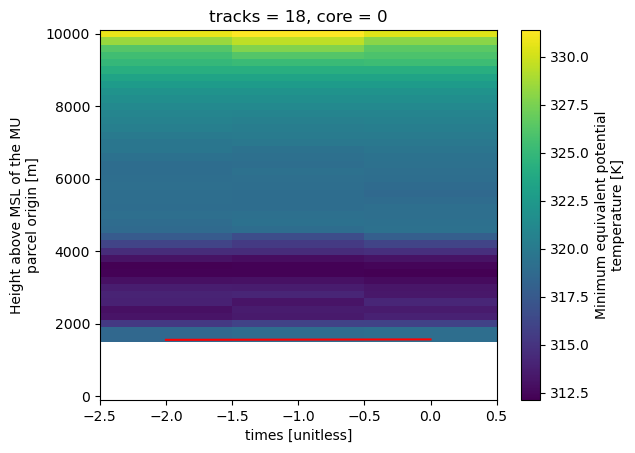

In [76]:
itrack = 1
ThetaE_wide_deep_d3.isel(tracks=itrack).where(height >= ds_wide_deep_d3.mu_parcel_ht_msl.isel(tracks=itrack)).transpose().sel(height=slice(0,10000)).plot()
ds_wide_deep_d3.mu_parcel_ht_msl.isel(tracks=itrack).plot(color='r')

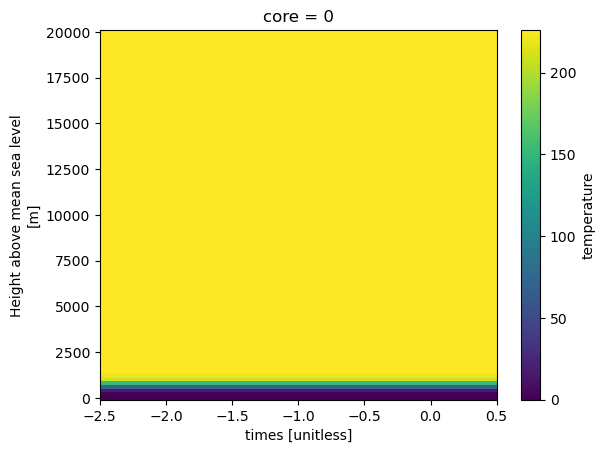

In [77]:
ns_narrow_shallow_d2.transpose().plot()

## Get domain min Qv & RH (most hostile moisture environments)

In [118]:
qv_wide_deep_d2 = ds_wide_deep_d2.qv_min.sel(times=slice(preCI_nt,0))
qv_wide_shallow_d2 = ds_wide_shallow_d2.qv_min.sel(times=slice(preCI_nt,0))

rh_wide_deep_d2 = ds_wide_deep_d2.rh_min.sel(times=slice(preCI_nt,0))
rh_wide_shallow_d2 = ds_wide_shallow_d2.rh_min.sel(times=slice(preCI_nt,0))

qv_narrow_deep_d2 = ds_narrow_deep_d2.qv_min.sel(times=slice(preCI_nt,0))
qv_narrow_shallow_d2 = ds_narrow_shallow_d2.qv_min.sel(times=slice(preCI_nt,0))

rh_narrow_deep_d2 = ds_narrow_deep_d2.rh_min.sel(times=slice(preCI_nt,0))
rh_narrow_shallow_d2 = ds_narrow_shallow_d2.rh_min.sel(times=slice(preCI_nt,0))

In [119]:
qv_wide_deep_d3 = ds_wide_deep_d3.qv_min.sel(times=slice(preCI_nt,0))
qv_wide_shallow_d3 = ds_wide_shallow_d3.qv_min.sel(times=slice(preCI_nt,0))

rh_wide_deep_d3 = ds_wide_deep_d3.rh_min.sel(times=slice(preCI_nt,0))
rh_wide_shallow_d3 = ds_wide_shallow_d3.rh_min.sel(times=slice(preCI_nt,0))

qv_narrow_deep_d3 = ds_narrow_deep_d3.qv_min.sel(times=slice(preCI_nt,0))
qv_narrow_shallow_d3 = ds_narrow_shallow_d3.qv_min.sel(times=slice(preCI_nt,0))

rh_narrow_deep_d3 = ds_narrow_deep_d3.rh_min.sel(times=slice(preCI_nt,0))
rh_narrow_shallow_d3 = ds_narrow_shallow_d3.rh_min.sel(times=slice(preCI_nt,0))

In [120]:
qv_wide_deep_d4 = ds_wide_deep_d4.qv_min.sel(times=slice(preCI_nt,0))
qv_wide_shallow_d4 = ds_wide_shallow_d4.qv_min.sel(times=slice(preCI_nt,0))

rh_wide_deep_d4 = ds_wide_deep_d4.rh_min.sel(times=slice(preCI_nt,0))
rh_wide_shallow_d4 = ds_wide_shallow_d4.rh_min.sel(times=slice(preCI_nt,0))

qv_narrow_deep_d4 = ds_narrow_deep_d4.qv_min.sel(times=slice(preCI_nt,0))
qv_narrow_shallow_d4 = ds_narrow_shallow_d4.qv_min.sel(times=slice(preCI_nt,0))

rh_narrow_deep_d4 = ds_narrow_deep_d4.rh_min.sel(times=slice(preCI_nt,0))
rh_narrow_shallow_d4 = ds_narrow_shallow_d4.rh_min.sel(times=slice(preCI_nt,0))

## Domain mean Qv & RH

In [79]:
# qv_wide_deep_d2 = ds_wide_deep_d2.qv.sel(times=slice(preCI_nt,0))
# qv_wide_shallow_d2 = ds_wide_shallow_d2.qv.sel(times=slice(preCI_nt,0))

# rh_wide_deep_d2 = ds_wide_deep_d2.rh.sel(times=slice(preCI_nt,0))
# rh_wide_shallow_d2 = ds_wide_shallow_d2.rh.sel(times=slice(preCI_nt,0))

# qv_narrow_deep_d2 = ds_narrow_deep_d2.qv.sel(times=slice(preCI_nt,0))
# qv_narrow_shallow_d2 = ds_narrow_shallow_d2.qv.sel(times=slice(preCI_nt,0))

# rh_narrow_deep_d2 = ds_narrow_deep_d2.rh.sel(times=slice(preCI_nt,0))
# rh_narrow_shallow_d2 = ds_narrow_shallow_d2.rh.sel(times=slice(preCI_nt,0))

In [80]:
# qv_wide_deep_d3 = ds_wide_deep_d3.qv.sel(times=slice(preCI_nt,0))
# qv_wide_shallow_d3 = ds_wide_shallow_d3.qv.sel(times=slice(preCI_nt,0))

# rh_wide_deep_d3 = ds_wide_deep_d3.rh.sel(times=slice(preCI_nt,0))
# rh_wide_shallow_d3 = ds_wide_shallow_d3.rh.sel(times=slice(preCI_nt,0))

# qv_narrow_deep_d3 = ds_narrow_deep_d3.qv.sel(times=slice(preCI_nt,0))
# qv_narrow_shallow_d3 = ds_narrow_shallow_d3.qv.sel(times=slice(preCI_nt,0))

# rh_narrow_deep_d3 = ds_narrow_deep_d3.rh.sel(times=slice(preCI_nt,0))
# rh_narrow_shallow_d3 = ds_narrow_shallow_d3.rh.sel(times=slice(preCI_nt,0))

In [117]:
# qv_wide_deep_d4 = ds_wide_deep_d4.qv.sel(times=slice(preCI_nt,0))
# qv_wide_shallow_d4 = ds_wide_shallow_d4.qv.sel(times=slice(preCI_nt,0))

# rh_wide_deep_d4 = ds_wide_deep_d4.rh.sel(times=slice(preCI_nt,0))
# rh_wide_shallow_d4 = ds_wide_shallow_d4.rh.sel(times=slice(preCI_nt,0))

# qv_narrow_deep_d4 = ds_narrow_deep_d4.qv.sel(times=slice(preCI_nt,0))
# qv_narrow_shallow_d4 = ds_narrow_shallow_d4.qv.sel(times=slice(preCI_nt,0))

# rh_narrow_deep_d4 = ds_narrow_deep_d4.rh.sel(times=slice(preCI_nt,0))
# rh_narrow_shallow_d4 = ds_narrow_shallow_d4.rh.sel(times=slice(preCI_nt,0))

In [121]:
# ThetaE_wide_deep_d2.isel(tracks=itrack).where(height >= ds_wide_deep_d2.mu_parcel_ht_msl.isel(tracks=itrack))
ThetaE_wide_deep_d2.shape, ds_wide_deep_d2.mu_parcel_ht_msl.sel(times=slice(preCI_nt,0)).shape

((38, 3, 101), (38, 3))

## Calculate composite preCI environmental profiles

### D2 wide cells 

In [122]:
tidx_start, tidx_end

(2, 14)

In [123]:
preCI_nt, time_env

(-2, -1)

In [124]:
prof_quantiles = [0.25, 0.75]

# Suppress the "All-NaN slice encountered" warning
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', r'All-NaN slice encountered')
    
    # Get MU parcel height prior to CI
    mu_parcel_ht_wide_deep_d2 = ds_wide_deep_d2.mu_parcel_ht_msl.sel(times=slice(preCI_nt,0))
    mu_parcel_ht_wide_shallow_d2 = ds_wide_shallow_d2.mu_parcel_ht_msl.sel(times=slice(preCI_nt,0))

    # Filter heights below MU parcel height, select a preCI time, then calculate median over the tracks
    ThetaE_wide_deep_med_d2 = ThetaE_wide_deep_d2.where(height >= mu_parcel_ht_wide_deep_d2).sel(times=time_env).median(dim='tracks').compute()
    ThetaE_wide_shallow_med_d2 = ThetaE_wide_shallow_d2.where(height >= mu_parcel_ht_wide_shallow_d2).sel(times=time_env).median(dim='tracks').compute()

    Theta_wide_deep_med_d2 = Theta_wide_deep_d2.where(height >= mu_parcel_ht_wide_deep_d2).sel(times=time_env).median(dim='tracks').compute()
    Theta_wide_shallow_med_d2 = Theta_wide_shallow_d2.where(height >= mu_parcel_ht_wide_shallow_d2).sel(times=time_env).median(dim='tracks').compute()

    qv_wide_deep_med_d2 = qv_wide_deep_d2.where(height >= mu_parcel_ht_wide_deep_d2).sel(times=time_env).median(dim='tracks').compute()
    qv_wide_shallow_med_d2 = qv_wide_shallow_d2.where(height >= mu_parcel_ht_wide_shallow_d2).sel(times=time_env).median(dim='tracks').compute()

    rh_wide_deep_med_d2 = rh_wide_deep_d2.where(height >= mu_parcel_ht_wide_deep_d2).sel(times=time_env).median(dim='tracks').compute()
    rh_wide_shallow_med_d2 = rh_wide_shallow_d2.where(height >= mu_parcel_ht_wide_shallow_d2).sel(times=time_env).median(dim='tracks').compute()
    
    # Mean
    ThetaE_wide_deep_avg_d2 = ThetaE_wide_deep_d2.where(height >= mu_parcel_ht_wide_deep_d2).sel(times=time_env).mean(dim='tracks').compute()
    ThetaE_wide_shallow_avg_d2 = ThetaE_wide_shallow_d2.where(height >= mu_parcel_ht_wide_shallow_d2).sel(times=time_env).mean(dim='tracks').compute()

    Theta_wide_deep_avg_d2 = Theta_wide_deep_d2.where(height >= mu_parcel_ht_wide_deep_d2).sel(times=time_env).mean(dim='tracks').compute()
    Theta_wide_shallow_avg_d2 = Theta_wide_shallow_d2.where(height >= mu_parcel_ht_wide_shallow_d2).sel(times=time_env).mean(dim='tracks').compute()

    qv_wide_deep_avg_d2 = qv_wide_deep_d2.where(height >= mu_parcel_ht_wide_deep_d2).sel(times=time_env).mean(dim='tracks').compute()
    qv_wide_shallow_avg_d2 = qv_wide_shallow_d2.where(height >= mu_parcel_ht_wide_shallow_d2).sel(times=time_env).mean(dim='tracks').compute()

    rh_wide_deep_avg_d2 = rh_wide_deep_d2.where(height >= mu_parcel_ht_wide_deep_d2).sel(times=time_env).mean(dim='tracks').compute()
    rh_wide_shallow_avg_d2 = rh_wide_shallow_d2.where(height >= mu_parcel_ht_wide_shallow_d2).sel(times=time_env).mean(dim='tracks').compute()
    
    # Get profile number of samples 
    ns_wide_deep_prof_d2 = (Theta_wide_deep_d2.where(height >= mu_parcel_ht_wide_deep_d2).sel(times=time_env) > 0).sum(dim='tracks').compute()
    ns_wide_shallow_prof_d2 = (Theta_wide_shallow_d2.where(height >= mu_parcel_ht_wide_shallow_d2).sel(times=time_env) > 0).sum(dim='tracks').compute()
    
    # Calculate interquartile range
    ThetaE_wide_deep_inqt_d2 = ThetaE_wide_deep_d2.where(height >= mu_parcel_ht_wide_deep_d2).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    ThetaE_wide_shallow_inqt_d2 = ThetaE_wide_shallow_d2.where(height >= mu_parcel_ht_wide_shallow_d2).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    
    Theta_wide_deep_inqt_d2 = Theta_wide_deep_d2.where(height >= mu_parcel_ht_wide_deep_d2).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    Theta_wide_shallow_inqt_d2 = Theta_wide_shallow_d2.where(height >= mu_parcel_ht_wide_shallow_d2).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    
    qv_wide_deep_inqt_d2 = qv_wide_deep_d2.where(height >= mu_parcel_ht_wide_deep_d2).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    qv_wide_shallow_inqt_d2 = qv_wide_shallow_d2.where(height >= mu_parcel_ht_wide_shallow_d2).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    
    rh_wide_deep_inqt_d2 = rh_wide_deep_d2.where(height >= mu_parcel_ht_wide_deep_d2).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    rh_wide_shallow_inqt_d2 = rh_wide_shallow_d2.where(height >= mu_parcel_ht_wide_shallow_d2).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()

In [125]:
# Height coordinate for updraft variables
height_core = ds_d2.z

# Get lowest MU parcel height preCI period
min_mu_parcel_ht_wide_deep_d2 = mu_parcel_ht_wide_deep_d2.min(dim='times')
min_mu_parcel_ht_wide_shallow_d2 = mu_parcel_ht_wide_shallow_d2.min(dim='times')
# Undiluted max ThetaE in updraft cores during CI-period: filter heights below MU parcel height
CoreThetaEMax_wide_deep_d2 = ds_wide_deep_d2.CoreThteMax_up.isel(times=slice(tidx_start, tidx_end)).where(height_core >= min_mu_parcel_ht_wide_deep_d2)
CoreThetaEMax_wide_shallow_d2 = ds_wide_shallow_d2.CoreThteMax_up.isel(times=slice(tidx_start, tidx_end)).where(height_core >= min_mu_parcel_ht_wide_shallow_d2)
# Take max over times, average over the tracks
MaxThetaE_wide_deep_avg_d2 = CoreThetaEMax_wide_deep_d2.max(dim='times').mean(dim='tracks').compute()
MaxThetaE_wide_shallow_avg_d2 = CoreThetaEMax_wide_shallow_d2.max(dim='times').mean(dim='tracks').compute()

# Number of samples
nsMaxThetaE_wide_deep_prof_d2 = (CoreThetaEMax_wide_deep_d2.max(dim='times') > 0).sum(dim='tracks').compute()
nsMaxThetaE_wide_shallow_prof_d2 = (CoreThetaEMax_wide_shallow_d2.max(dim='times') > 0).sum(dim='tracks').compute()

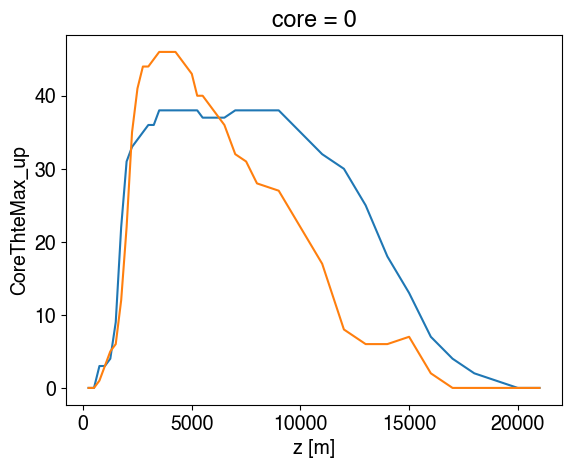

In [126]:
nsMaxThetaE_wide_deep_prof_d2.plot()
nsMaxThetaE_wide_shallow_prof_d2.plot()

### D2 narrow cells

In [127]:
# Suppress the "All-NaN slice encountered" warning
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', r'All-NaN slice encountered')
    
    # Get MU parcel height prior to CI
    mu_parcel_ht_narrow_deep_d2 = ds_narrow_deep_d2.mu_parcel_ht_msl.sel(times=slice(preCI_nt,0))
    mu_parcel_ht_narrow_shallow_d2 = ds_narrow_shallow_d2.mu_parcel_ht_msl.sel(times=slice(preCI_nt,0))

    # Filter heights below MU parcel height, select a preCI time, then calculate median over the tracks
    ThetaE_narrow_deep_med_d2 = ThetaE_narrow_deep_d2.where(height >= mu_parcel_ht_narrow_deep_d2).sel(times=time_env).median(dim='tracks').compute()
    ThetaE_narrow_shallow_med_d2 = ThetaE_narrow_shallow_d2.where(height >= mu_parcel_ht_narrow_shallow_d2).sel(times=time_env).median(dim='tracks').compute()

    Theta_narrow_deep_med_d2 = Theta_narrow_deep_d2.where(height >= mu_parcel_ht_narrow_deep_d2).sel(times=time_env).median(dim='tracks').compute()
    Theta_narrow_shallow_med_d2 = Theta_narrow_shallow_d2.where(height >= mu_parcel_ht_narrow_shallow_d2).sel(times=time_env).median(dim='tracks').compute()

    qv_narrow_deep_med_d2 = qv_narrow_deep_d2.where(height >= mu_parcel_ht_narrow_deep_d2).sel(times=time_env).median(dim='tracks').compute()
    qv_narrow_shallow_med_d2 = qv_narrow_shallow_d2.where(height >= mu_parcel_ht_narrow_shallow_d2).sel(times=time_env).median(dim='tracks').compute()

    rh_narrow_deep_med_d2 = rh_narrow_deep_d2.where(height >= mu_parcel_ht_narrow_deep_d2).sel(times=time_env).median(dim='tracks').compute()
    rh_narrow_shallow_med_d2 = rh_narrow_shallow_d2.where(height >= mu_parcel_ht_narrow_shallow_d2).sel(times=time_env).median(dim='tracks').compute()
    
    # Mean
    ThetaE_narrow_deep_avg_d2 = ThetaE_narrow_deep_d2.where(height >= mu_parcel_ht_narrow_deep_d2).sel(times=time_env).mean(dim='tracks').compute()
    ThetaE_narrow_shallow_avg_d2 = ThetaE_narrow_shallow_d2.where(height >= mu_parcel_ht_narrow_shallow_d2).sel(times=time_env).mean(dim='tracks').compute()

    Theta_narrow_deep_avg_d2 = Theta_narrow_deep_d2.where(height >= mu_parcel_ht_narrow_deep_d2).sel(times=time_env).mean(dim='tracks').compute()
    Theta_narrow_shallow_avg_d2 = Theta_narrow_shallow_d2.where(height >= mu_parcel_ht_narrow_shallow_d2).sel(times=time_env).mean(dim='tracks').compute()

    qv_narrow_deep_avg_d2 = qv_narrow_deep_d2.where(height >= mu_parcel_ht_narrow_deep_d2).sel(times=time_env).mean(dim='tracks').compute()
    qv_narrow_shallow_avg_d2 = qv_narrow_shallow_d2.where(height >= mu_parcel_ht_narrow_shallow_d2).sel(times=time_env).mean(dim='tracks').compute()

    rh_narrow_deep_avg_d2 = rh_narrow_deep_d2.where(height >= mu_parcel_ht_narrow_deep_d2).sel(times=time_env).mean(dim='tracks').compute()
    rh_narrow_shallow_avg_d2 = rh_narrow_shallow_d2.where(height >= mu_parcel_ht_narrow_shallow_d2).sel(times=time_env).mean(dim='tracks').compute()
    
    # Get profile number of samples 
    ns_narrow_deep_prof_d2 = (Theta_narrow_deep_d2.where(height >= mu_parcel_ht_narrow_deep_d2).sel(times=time_env) > 0).sum(dim='tracks').compute()
    ns_narrow_shallow_prof_d2 = (Theta_narrow_shallow_d2.where(height >= mu_parcel_ht_narrow_shallow_d2).sel(times=time_env) > 0).sum(dim='tracks').compute()
    
    # Calculate interquartile range
    ThetaE_narrow_deep_inqt_d2 = ThetaE_narrow_deep_d2.where(height >= mu_parcel_ht_narrow_deep_d2).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    ThetaE_narrow_shallow_inqt_d2 = ThetaE_narrow_shallow_d2.where(height >= mu_parcel_ht_narrow_shallow_d2).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    
    Theta_narrow_deep_inqt_d2 = Theta_narrow_deep_d2.where(height >= mu_parcel_ht_narrow_deep_d2).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    Theta_narrow_shallow_inqt_d2 = Theta_narrow_shallow_d2.where(height >= mu_parcel_ht_narrow_shallow_d2).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    
    qv_narrow_deep_inqt_d2 = qv_narrow_deep_d2.where(height >= mu_parcel_ht_narrow_deep_d2).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    qv_narrow_shallow_inqt_d2 = qv_narrow_shallow_d2.where(height >= mu_parcel_ht_narrow_shallow_d2).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    
    rh_narrow_deep_inqt_d2 = rh_narrow_deep_d2.where(height >= mu_parcel_ht_narrow_deep_d2).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    rh_narrow_shallow_inqt_d2 = rh_narrow_shallow_d2.where(height >= mu_parcel_ht_narrow_shallow_d2).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()

In [128]:
# Get lowest MU parcel height preCI period
min_mu_parcel_ht_narrow_deep_d2 = mu_parcel_ht_narrow_deep_d2.min(dim='times')
min_mu_parcel_ht_narrow_shallow_d2 = mu_parcel_ht_narrow_shallow_d2.min(dim='times')
# Undiluted max ThetaE in updraft cores during CI-period: filter heights below MU parcel height
CoreThetaEMax_narrow_deep_d2 = ds_narrow_deep_d2.CoreThteMax_up.isel(times=slice(tidx_start, tidx_end)).where(height_core >= min_mu_parcel_ht_narrow_deep_d2)
CoreThetaEMax_narrow_shallow_d2 = ds_narrow_shallow_d2.CoreThteMax_up.isel(times=slice(tidx_start, tidx_end)).where(height_core >= min_mu_parcel_ht_narrow_shallow_d2)
# Take max over times, average over the tracks
MaxThetaE_narrow_deep_avg_d2 = CoreThetaEMax_narrow_deep_d2.max(dim='times').mean(dim='tracks').compute()
MaxThetaE_narrow_shallow_avg_d2 = CoreThetaEMax_narrow_shallow_d2.max(dim='times').mean(dim='tracks').compute()

# Number of samples
nsMaxThetaE_narrow_deep_prof_d2 = (CoreThetaEMax_narrow_deep_d2.max(dim='times') > 0).sum(dim='tracks').compute()
nsMaxThetaE_narrow_shallow_prof_d2 = (CoreThetaEMax_narrow_shallow_d2.max(dim='times') > 0).sum(dim='tracks').compute()

In [129]:
# fig, axes = plt.subplots(1, 2, figsize=(8,4), dpi=100)
# ax0 = axes[0]
# ax0.plot(MaxThetaE_wide_deep_avg_d2, height_core, color='r')
# ax0.plot(MaxThetaE_wide_shallow_avg_d2, height_core, color='b')
# ax0.set_xlim(320, 365)
# ax0.set_ylim(0,12000)

# ax1 = axes[1]
# ax1.plot(MaxThetaE_narrow_deep_avg_d2, height_core, color='r')
# ax1.plot(MaxThetaE_narrow_shallow_avg_d2, height_core, color='b')
# ax1.set_xlim(320, 365)
# ax1.set_ylim(0,12000)

### D3 wide cells

In [130]:
# Suppress the "All-NaN slice encountered" warning
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', r'All-NaN slice encountered')
    
    # Get MU parcel height prior to CI
    mu_parcel_ht_wide_deep_d3 = ds_wide_deep_d3.mu_parcel_ht_msl.sel(times=slice(preCI_nt,0))
    mu_parcel_ht_wide_shallow_d3 = ds_wide_shallow_d3.mu_parcel_ht_msl.sel(times=slice(preCI_nt,0))

    # Filter heights below MU parcel height, select a preCI time, then calculate median over the tracks
    ThetaE_wide_deep_med_d3 = ThetaE_wide_deep_d3.where(height >= mu_parcel_ht_wide_deep_d3).sel(times=time_env).median(dim='tracks').compute()
    ThetaE_wide_shallow_med_d3 = ThetaE_wide_shallow_d3.where(height >= mu_parcel_ht_wide_shallow_d3).sel(times=time_env).median(dim='tracks').compute()

    Theta_wide_deep_med_d3 = Theta_wide_deep_d3.where(height >= mu_parcel_ht_wide_deep_d3).sel(times=time_env).median(dim='tracks').compute()
    Theta_wide_shallow_med_d3 = Theta_wide_shallow_d3.where(height >= mu_parcel_ht_wide_shallow_d3).sel(times=time_env).median(dim='tracks').compute()

    qv_wide_deep_med_d3 = qv_wide_deep_d3.where(height >= mu_parcel_ht_wide_deep_d3).sel(times=time_env).median(dim='tracks').compute()
    qv_wide_shallow_med_d3 = qv_wide_shallow_d3.where(height >= mu_parcel_ht_wide_shallow_d3).sel(times=time_env).median(dim='tracks').compute()

    rh_wide_deep_med_d3 = rh_wide_deep_d3.where(height >= mu_parcel_ht_wide_deep_d3).sel(times=time_env).median(dim='tracks').compute()
    rh_wide_shallow_med_d3 = rh_wide_shallow_d3.where(height >= mu_parcel_ht_wide_shallow_d3).sel(times=time_env).median(dim='tracks').compute()
    
    # Mean
    ThetaE_wide_deep_avg_d3 = ThetaE_wide_deep_d3.where(height >= mu_parcel_ht_wide_deep_d3).sel(times=time_env).mean(dim='tracks').compute()
    ThetaE_wide_shallow_avg_d3 = ThetaE_wide_shallow_d3.where(height >= mu_parcel_ht_wide_shallow_d3).sel(times=time_env).mean(dim='tracks').compute()

    Theta_wide_deep_avg_d3 = Theta_wide_deep_d3.where(height >= mu_parcel_ht_wide_deep_d3).sel(times=time_env).mean(dim='tracks').compute()
    Theta_wide_shallow_avg_d3 = Theta_wide_shallow_d3.where(height >= mu_parcel_ht_wide_shallow_d3).sel(times=time_env).mean(dim='tracks').compute()

    qv_wide_deep_avg_d3 = qv_wide_deep_d3.where(height >= mu_parcel_ht_wide_deep_d3).sel(times=time_env).mean(dim='tracks').compute()
    qv_wide_shallow_avg_d3 = qv_wide_shallow_d3.where(height >= mu_parcel_ht_wide_shallow_d3).sel(times=time_env).mean(dim='tracks').compute()

    rh_wide_deep_avg_d3 = rh_wide_deep_d3.where(height >= mu_parcel_ht_wide_deep_d3).sel(times=time_env).mean(dim='tracks').compute()
    rh_wide_shallow_avg_d3 = rh_wide_shallow_d3.where(height >= mu_parcel_ht_wide_shallow_d3).sel(times=time_env).mean(dim='tracks').compute()
    
    # Get profile number of samples 
    ns_wide_deep_prof_d3 = (Theta_wide_deep_d3.where(height >= mu_parcel_ht_wide_deep_d3).sel(times=time_env) > 0).sum(dim='tracks').compute()
    ns_wide_shallow_prof_d3 = (Theta_wide_shallow_d3.where(height >= mu_parcel_ht_wide_shallow_d3).sel(times=time_env) > 0).sum(dim='tracks').compute()
    
    # Calculate interquartile range
    ThetaE_wide_deep_inqt_d3 = ThetaE_wide_deep_d3.where(height >= mu_parcel_ht_wide_deep_d3).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    ThetaE_wide_shallow_inqt_d3 = ThetaE_wide_shallow_d3.where(height >= mu_parcel_ht_wide_shallow_d3).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    
    Theta_wide_deep_inqt_d3 = Theta_wide_deep_d3.where(height >= mu_parcel_ht_wide_deep_d3).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    Theta_wide_shallow_inqt_d3 = Theta_wide_shallow_d3.where(height >= mu_parcel_ht_wide_shallow_d3).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    
    qv_wide_deep_inqt_d3 = qv_wide_deep_d3.where(height >= mu_parcel_ht_wide_deep_d3).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    qv_wide_shallow_inqt_d3 = qv_wide_shallow_d3.where(height >= mu_parcel_ht_wide_shallow_d3).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    
    rh_wide_deep_inqt_d3 = rh_wide_deep_d3.where(height >= mu_parcel_ht_wide_deep_d3).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    rh_wide_shallow_inqt_d3 = rh_wide_shallow_d3.where(height >= mu_parcel_ht_wide_shallow_d3).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()

In [131]:
# Get lowest MU parcel height preCI period
min_mu_parcel_ht_wide_deep_d3 = mu_parcel_ht_wide_deep_d3.min(dim='times')
min_mu_parcel_ht_wide_shallow_d3 = mu_parcel_ht_wide_shallow_d3.min(dim='times')
# Undiluted max ThetaE in updraft cores during CI-period: filter heights below MU parcel height
CoreThetaEMax_wide_deep_d3 = ds_wide_deep_d3.CoreThteMax_up.isel(times=slice(tidx_start, tidx_end)).where(height_core >= min_mu_parcel_ht_wide_deep_d3)
CoreThetaEMax_wide_shallow_d3 = ds_wide_shallow_d3.CoreThteMax_up.isel(times=slice(tidx_start, tidx_end)).where(height_core >= min_mu_parcel_ht_wide_shallow_d3)
# Take max over times, average over the tracks
MaxThetaE_wide_deep_avg_d3 = CoreThetaEMax_wide_deep_d3.max(dim='times').mean(dim='tracks').compute()
MaxThetaE_wide_shallow_avg_d3 = CoreThetaEMax_wide_shallow_d3.max(dim='times').mean(dim='tracks').compute()

# Number of samples
nsMaxThetaE_wide_deep_prof_d3 = (CoreThetaEMax_wide_deep_d3.max(dim='times') > 0).sum(dim='tracks').compute()
nsMaxThetaE_wide_shallow_prof_d3 = (CoreThetaEMax_wide_shallow_d3.max(dim='times') > 0).sum(dim='tracks').compute()

### D3 narrow cells

In [132]:
# Suppress the "All-NaN slice encountered" warning
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', r'All-NaN slice encountered')
    
    # Get MU parcel height prior to CI
    mu_parcel_ht_narrow_deep_d3 = ds_narrow_deep_d3.mu_parcel_ht_msl.sel(times=slice(preCI_nt,0))
    mu_parcel_ht_narrow_shallow_d3 = ds_narrow_shallow_d3.mu_parcel_ht_msl.sel(times=slice(preCI_nt,0))

    # Filter heights below MU parcel height, select a preCI time, then calculate median over the tracks
    ThetaE_narrow_deep_med_d3 = ThetaE_narrow_deep_d3.where(height >= mu_parcel_ht_narrow_deep_d3).sel(times=time_env).median(dim='tracks').compute()
    ThetaE_narrow_shallow_med_d3 = ThetaE_narrow_shallow_d3.where(height >= mu_parcel_ht_narrow_shallow_d3).sel(times=time_env).median(dim='tracks').compute()

    Theta_narrow_deep_med_d3 = Theta_narrow_deep_d3.where(height >= mu_parcel_ht_narrow_deep_d3).sel(times=time_env).median(dim='tracks').compute()
    Theta_narrow_shallow_med_d3 = Theta_narrow_shallow_d3.where(height >= mu_parcel_ht_narrow_shallow_d3).sel(times=time_env).median(dim='tracks').compute()

    qv_narrow_deep_med_d3 = qv_narrow_deep_d3.where(height >= mu_parcel_ht_narrow_deep_d3).sel(times=time_env).median(dim='tracks').compute()
    qv_narrow_shallow_med_d3 = qv_narrow_shallow_d3.where(height >= mu_parcel_ht_narrow_shallow_d3).sel(times=time_env).median(dim='tracks').compute()

    rh_narrow_deep_med_d3 = rh_narrow_deep_d3.where(height >= mu_parcel_ht_narrow_deep_d3).sel(times=time_env).median(dim='tracks').compute()
    rh_narrow_shallow_med_d3 = rh_narrow_shallow_d3.where(height >= mu_parcel_ht_narrow_shallow_d3).sel(times=time_env).median(dim='tracks').compute()
    
    # Mean
    ThetaE_narrow_deep_avg_d3 = ThetaE_narrow_deep_d3.where(height >= mu_parcel_ht_narrow_deep_d3).sel(times=time_env).mean(dim='tracks').compute()
    ThetaE_narrow_shallow_avg_d3 = ThetaE_narrow_shallow_d3.where(height >= mu_parcel_ht_narrow_shallow_d3).sel(times=time_env).mean(dim='tracks').compute()

    Theta_narrow_deep_avg_d3 = Theta_narrow_deep_d3.where(height >= mu_parcel_ht_narrow_deep_d3).sel(times=time_env).mean(dim='tracks').compute()
    Theta_narrow_shallow_avg_d3 = Theta_narrow_shallow_d3.where(height >= mu_parcel_ht_narrow_shallow_d3).sel(times=time_env).mean(dim='tracks').compute()

    qv_narrow_deep_avg_d3 = qv_narrow_deep_d3.where(height >= mu_parcel_ht_narrow_deep_d3).sel(times=time_env).mean(dim='tracks').compute()
    qv_narrow_shallow_avg_d3 = qv_narrow_shallow_d3.where(height >= mu_parcel_ht_narrow_shallow_d3).sel(times=time_env).mean(dim='tracks').compute()

    rh_narrow_deep_avg_d3 = rh_narrow_deep_d3.where(height >= mu_parcel_ht_narrow_deep_d3).sel(times=time_env).mean(dim='tracks').compute()
    rh_narrow_shallow_avg_d3 = rh_narrow_shallow_d3.where(height >= mu_parcel_ht_narrow_shallow_d3).sel(times=time_env).mean(dim='tracks').compute()
    
    # Get profile number of samples 
    ns_narrow_deep_prof_d3 = (Theta_narrow_deep_d3.where(height >= mu_parcel_ht_narrow_deep_d3).sel(times=time_env) > 0).sum(dim='tracks').compute()
    ns_narrow_shallow_prof_d3 = (Theta_narrow_shallow_d3.where(height >= mu_parcel_ht_narrow_shallow_d3).sel(times=time_env) > 0).sum(dim='tracks').compute()
    
    # Calculate interquartile range
    ThetaE_narrow_deep_inqt_d3 = ThetaE_narrow_deep_d3.where(height >= mu_parcel_ht_narrow_deep_d3).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    ThetaE_narrow_shallow_inqt_d3 = ThetaE_narrow_shallow_d3.where(height >= mu_parcel_ht_narrow_shallow_d3).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    
    Theta_narrow_deep_inqt_d3 = Theta_narrow_deep_d3.where(height >= mu_parcel_ht_narrow_deep_d3).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    Theta_narrow_shallow_inqt_d3 = Theta_narrow_shallow_d3.where(height >= mu_parcel_ht_narrow_shallow_d3).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    
    qv_narrow_deep_inqt_d3 = qv_narrow_deep_d3.where(height >= mu_parcel_ht_narrow_deep_d3).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    qv_narrow_shallow_inqt_d3 = qv_narrow_shallow_d3.where(height >= mu_parcel_ht_narrow_shallow_d3).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    
    rh_narrow_deep_inqt_d3 = rh_narrow_deep_d3.where(height >= mu_parcel_ht_narrow_deep_d3).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    rh_narrow_shallow_inqt_d3 = rh_narrow_shallow_d3.where(height >= mu_parcel_ht_narrow_shallow_d3).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()

In [133]:
# Get lowest MU parcel height preCI period
min_mu_parcel_ht_narrow_deep_d3 = mu_parcel_ht_narrow_deep_d3.min(dim='times')
min_mu_parcel_ht_narrow_shallow_d3 = mu_parcel_ht_narrow_shallow_d3.min(dim='times')
# Undiluted max ThetaE in updraft cores during CI-period: filter heights below MU parcel height
CoreThetaEMax_narrow_deep_d3 = ds_narrow_deep_d3.CoreThteMax_up.isel(times=slice(tidx_start, tidx_end)).where(height_core >= min_mu_parcel_ht_narrow_deep_d3)
CoreThetaEMax_narrow_shallow_d3 = ds_narrow_shallow_d3.CoreThteMax_up.isel(times=slice(tidx_start, tidx_end)).where(height_core >= min_mu_parcel_ht_narrow_shallow_d3)
# Take max over times, average over the tracks
MaxThetaE_narrow_deep_avg_d3 = CoreThetaEMax_narrow_deep_d3.max(dim='times').mean(dim='tracks').compute()
MaxThetaE_narrow_shallow_avg_d3 = CoreThetaEMax_narrow_shallow_d3.max(dim='times').mean(dim='tracks').compute()

# Number of samples
nsMaxThetaE_narrow_deep_prof_d3 = (CoreThetaEMax_narrow_deep_d3.max(dim='times') > 0).sum(dim='tracks').compute()
nsMaxThetaE_narrow_shallow_prof_d3 = (CoreThetaEMax_narrow_shallow_d3.max(dim='times') > 0).sum(dim='tracks').compute()

### D4 wide cells

In [134]:
# Suppress the "All-NaN slice encountered" warning
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', r'All-NaN slice encountered')
    
    # Get MU parcel height prior to CI
    mu_parcel_ht_wide_deep_d4 = ds_wide_deep_d4.mu_parcel_ht_msl.sel(times=slice(preCI_nt,0))
    mu_parcel_ht_wide_shallow_d4 = ds_wide_shallow_d4.mu_parcel_ht_msl.sel(times=slice(preCI_nt,0))

    # Filter heights below MU parcel height, select a preCI time, then calculate median over the tracks
    ThetaE_wide_deep_med_d4 = ThetaE_wide_deep_d4.where(height >= mu_parcel_ht_wide_deep_d4).sel(times=time_env).median(dim='tracks').compute()
    ThetaE_wide_shallow_med_d4 = ThetaE_wide_shallow_d4.where(height >= mu_parcel_ht_wide_shallow_d4).sel(times=time_env).median(dim='tracks').compute()

    Theta_wide_deep_med_d4 = Theta_wide_deep_d4.where(height >= mu_parcel_ht_wide_deep_d4).sel(times=time_env).median(dim='tracks').compute()
    Theta_wide_shallow_med_d4 = Theta_wide_shallow_d4.where(height >= mu_parcel_ht_wide_shallow_d4).sel(times=time_env).median(dim='tracks').compute()

    qv_wide_deep_med_d4 = qv_wide_deep_d4.where(height >= mu_parcel_ht_wide_deep_d4).sel(times=time_env).median(dim='tracks').compute()
    qv_wide_shallow_med_d4 = qv_wide_shallow_d4.where(height >= mu_parcel_ht_wide_shallow_d4).sel(times=time_env).median(dim='tracks').compute()

    rh_wide_deep_med_d4 = rh_wide_deep_d4.where(height >= mu_parcel_ht_wide_deep_d4).sel(times=time_env).median(dim='tracks').compute()
    rh_wide_shallow_med_d4 = rh_wide_shallow_d4.where(height >= mu_parcel_ht_wide_shallow_d4).sel(times=time_env).median(dim='tracks').compute()
    
    # Mean
    ThetaE_wide_deep_avg_d4 = ThetaE_wide_deep_d4.where(height >= mu_parcel_ht_wide_deep_d4).sel(times=time_env).mean(dim='tracks').compute()
    ThetaE_wide_shallow_avg_d4 = ThetaE_wide_shallow_d4.where(height >= mu_parcel_ht_wide_shallow_d4).sel(times=time_env).mean(dim='tracks').compute()

    Theta_wide_deep_avg_d4 = Theta_wide_deep_d4.where(height >= mu_parcel_ht_wide_deep_d4).sel(times=time_env).mean(dim='tracks').compute()
    Theta_wide_shallow_avg_d4 = Theta_wide_shallow_d4.where(height >= mu_parcel_ht_wide_shallow_d4).sel(times=time_env).mean(dim='tracks').compute()

    qv_wide_deep_avg_d4 = qv_wide_deep_d4.where(height >= mu_parcel_ht_wide_deep_d4).sel(times=time_env).mean(dim='tracks').compute()
    qv_wide_shallow_avg_d4 = qv_wide_shallow_d4.where(height >= mu_parcel_ht_wide_shallow_d4).sel(times=time_env).mean(dim='tracks').compute()

    rh_wide_deep_avg_d4 = rh_wide_deep_d4.where(height >= mu_parcel_ht_wide_deep_d4).sel(times=time_env).mean(dim='tracks').compute()
    rh_wide_shallow_avg_d4 = rh_wide_shallow_d4.where(height >= mu_parcel_ht_wide_shallow_d4).sel(times=time_env).mean(dim='tracks').compute()
    
    # Get profile number of samples 
    ns_wide_deep_prof_d4 = (Theta_wide_deep_d4.where(height >= mu_parcel_ht_wide_deep_d4).sel(times=time_env) > 0).sum(dim='tracks').compute()
    ns_wide_shallow_prof_d4 = (Theta_wide_shallow_d4.where(height >= mu_parcel_ht_wide_shallow_d4).sel(times=time_env) > 0).sum(dim='tracks').compute()
    
    # Calculate interquartile range
    ThetaE_wide_deep_inqt_d4 = ThetaE_wide_deep_d4.where(height >= mu_parcel_ht_wide_deep_d4).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    ThetaE_wide_shallow_inqt_d4 = ThetaE_wide_shallow_d4.where(height >= mu_parcel_ht_wide_shallow_d4).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    
    Theta_wide_deep_inqt_d4 = Theta_wide_deep_d4.where(height >= mu_parcel_ht_wide_deep_d4).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    Theta_wide_shallow_inqt_d4 = Theta_wide_shallow_d4.where(height >= mu_parcel_ht_wide_shallow_d4).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    
    qv_wide_deep_inqt_d4 = qv_wide_deep_d4.where(height >= mu_parcel_ht_wide_deep_d4).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    qv_wide_shallow_inqt_d4 = qv_wide_shallow_d4.where(height >= mu_parcel_ht_wide_shallow_d4).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    
    rh_wide_deep_inqt_d4 = rh_wide_deep_d4.where(height >= mu_parcel_ht_wide_deep_d4).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    rh_wide_shallow_inqt_d4 = rh_wide_shallow_d4.where(height >= mu_parcel_ht_wide_shallow_d4).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()

In [135]:
# Get lowest MU parcel height preCI period
min_mu_parcel_ht_wide_deep_d4 = mu_parcel_ht_wide_deep_d4.min(dim='times')
min_mu_parcel_ht_wide_shallow_d4 = mu_parcel_ht_wide_shallow_d4.min(dim='times')
# Undiluted max ThetaE in updraft cores during CI-period: filter heights below MU parcel height
CoreThetaEMax_wide_deep_d4 = ds_wide_deep_d4.CoreThteMax_up.isel(times=slice(tidx_start, tidx_end)).where(height_core >= min_mu_parcel_ht_wide_deep_d4)
CoreThetaEMax_wide_shallow_d4 = ds_wide_shallow_d4.CoreThteMax_up.isel(times=slice(tidx_start, tidx_end)).where(height_core >= min_mu_parcel_ht_wide_shallow_d4)
# Take max over times, average over the tracks
MaxThetaE_wide_deep_avg_d4 = CoreThetaEMax_wide_deep_d4.max(dim='times').mean(dim='tracks').compute()
MaxThetaE_wide_shallow_avg_d4 = CoreThetaEMax_wide_shallow_d4.max(dim='times').mean(dim='tracks').compute()

# Number of samples
nsMaxThetaE_wide_deep_prof_d4 = (CoreThetaEMax_wide_deep_d4.max(dim='times') > 0).sum(dim='tracks').compute()
nsMaxThetaE_wide_shallow_prof_d4 = (CoreThetaEMax_wide_shallow_d4.max(dim='times') > 0).sum(dim='tracks').compute()

### D4 narrow cells

In [136]:
# Suppress the "All-NaN slice encountered" warning
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', r'All-NaN slice encountered')
    
    # Get MU parcel height prior to CI
    mu_parcel_ht_narrow_deep_d4 = ds_narrow_deep_d4.mu_parcel_ht_msl.sel(times=slice(preCI_nt,0))
    mu_parcel_ht_narrow_shallow_d4 = ds_narrow_shallow_d4.mu_parcel_ht_msl.sel(times=slice(preCI_nt,0))

    # Filter heights below MU parcel height, select a preCI time, then calculate median over the tracks
    ThetaE_narrow_deep_med_d4 = ThetaE_narrow_deep_d4.where(height >= mu_parcel_ht_narrow_deep_d4).sel(times=time_env).median(dim='tracks').compute()
    ThetaE_narrow_shallow_med_d4 = ThetaE_narrow_shallow_d4.where(height >= mu_parcel_ht_narrow_shallow_d4).sel(times=time_env).median(dim='tracks').compute()

    Theta_narrow_deep_med_d4 = Theta_narrow_deep_d4.where(height >= mu_parcel_ht_narrow_deep_d4).sel(times=time_env).median(dim='tracks').compute()
    Theta_narrow_shallow_med_d4 = Theta_narrow_shallow_d4.where(height >= mu_parcel_ht_narrow_shallow_d4).sel(times=time_env).median(dim='tracks').compute()

    qv_narrow_deep_med_d4 = qv_narrow_deep_d4.where(height >= mu_parcel_ht_narrow_deep_d4).sel(times=time_env).median(dim='tracks').compute()
    qv_narrow_shallow_med_d4 = qv_narrow_shallow_d4.where(height >= mu_parcel_ht_narrow_shallow_d4).sel(times=time_env).median(dim='tracks').compute()

    rh_narrow_deep_med_d4 = rh_narrow_deep_d4.where(height >= mu_parcel_ht_narrow_deep_d4).sel(times=time_env).median(dim='tracks').compute()
    rh_narrow_shallow_med_d4 = rh_narrow_shallow_d4.where(height >= mu_parcel_ht_narrow_shallow_d4).sel(times=time_env).median(dim='tracks').compute()
    
    # Mean
    ThetaE_narrow_deep_avg_d4 = ThetaE_narrow_deep_d4.where(height >= mu_parcel_ht_narrow_deep_d4).sel(times=time_env).mean(dim='tracks').compute()
    ThetaE_narrow_shallow_avg_d4 = ThetaE_narrow_shallow_d4.where(height >= mu_parcel_ht_narrow_shallow_d4).sel(times=time_env).mean(dim='tracks').compute()

    Theta_narrow_deep_avg_d4 = Theta_narrow_deep_d4.where(height >= mu_parcel_ht_narrow_deep_d4).sel(times=time_env).mean(dim='tracks').compute()
    Theta_narrow_shallow_avg_d4 = Theta_narrow_shallow_d4.where(height >= mu_parcel_ht_narrow_shallow_d4).sel(times=time_env).mean(dim='tracks').compute()

    qv_narrow_deep_avg_d4 = qv_narrow_deep_d4.where(height >= mu_parcel_ht_narrow_deep_d4).sel(times=time_env).mean(dim='tracks').compute()
    qv_narrow_shallow_avg_d4 = qv_narrow_shallow_d4.where(height >= mu_parcel_ht_narrow_shallow_d4).sel(times=time_env).mean(dim='tracks').compute()

    rh_narrow_deep_avg_d4 = rh_narrow_deep_d4.where(height >= mu_parcel_ht_narrow_deep_d4).sel(times=time_env).mean(dim='tracks').compute()
    rh_narrow_shallow_avg_d4 = rh_narrow_shallow_d4.where(height >= mu_parcel_ht_narrow_shallow_d4).sel(times=time_env).mean(dim='tracks').compute()
    
    # Get profile number of samples 
    ns_narrow_deep_prof_d4 = (Theta_narrow_deep_d4.where(height >= mu_parcel_ht_narrow_deep_d4).sel(times=time_env) > 0).sum(dim='tracks').compute()
    ns_narrow_shallow_prof_d4 = (Theta_narrow_shallow_d4.where(height >= mu_parcel_ht_narrow_shallow_d4).sel(times=time_env) > 0).sum(dim='tracks').compute()
    
    # Calculate interquartile range
    ThetaE_narrow_deep_inqt_d4 = ThetaE_narrow_deep_d4.where(height >= mu_parcel_ht_narrow_deep_d4).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    ThetaE_narrow_shallow_inqt_d4 = ThetaE_narrow_shallow_d4.where(height >= mu_parcel_ht_narrow_shallow_d4).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    
    Theta_narrow_deep_inqt_d4 = Theta_narrow_deep_d4.where(height >= mu_parcel_ht_narrow_deep_d4).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    Theta_narrow_shallow_inqt_d4 = Theta_narrow_shallow_d4.where(height >= mu_parcel_ht_narrow_shallow_d4).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    
    qv_narrow_deep_inqt_d4 = qv_narrow_deep_d4.where(height >= mu_parcel_ht_narrow_deep_d4).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    qv_narrow_shallow_inqt_d4 = qv_narrow_shallow_d4.where(height >= mu_parcel_ht_narrow_shallow_d4).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    
    rh_narrow_deep_inqt_d4 = rh_narrow_deep_d4.where(height >= mu_parcel_ht_narrow_deep_d4).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()
    rh_narrow_shallow_inqt_d4 = rh_narrow_shallow_d4.where(height >= mu_parcel_ht_narrow_shallow_d4).sel(times=time_env).chunk(dict(tracks=-1)).quantile(prof_quantiles, dim='tracks').compute()

In [137]:
# Get lowest MU parcel height preCI period
min_mu_parcel_ht_narrow_deep_d4 = mu_parcel_ht_narrow_deep_d4.min(dim='times')
min_mu_parcel_ht_narrow_shallow_d4 = mu_parcel_ht_narrow_shallow_d4.min(dim='times')
# Undiluted max ThetaE in updraft cores during CI-period: filter heights below MU parcel height
CoreThetaEMax_narrow_deep_d4 = ds_narrow_deep_d4.CoreThteMax_up.isel(times=slice(tidx_start, tidx_end)).where(height_core >= min_mu_parcel_ht_narrow_deep_d4)
CoreThetaEMax_narrow_shallow_d4 = ds_narrow_shallow_d4.CoreThteMax_up.isel(times=slice(tidx_start, tidx_end)).where(height_core >= min_mu_parcel_ht_narrow_shallow_d4)
# Take max over times, average over the tracks
MaxThetaE_narrow_deep_avg_d4 = CoreThetaEMax_narrow_deep_d4.max(dim='times').mean(dim='tracks').compute()
MaxThetaE_narrow_shallow_avg_d4 = CoreThetaEMax_narrow_shallow_d4.max(dim='times').mean(dim='tracks').compute()

# Number of samples
nsMaxThetaE_narrow_deep_prof_d4 = (CoreThetaEMax_narrow_deep_d4.max(dim='times') > 0).sum(dim='tracks').compute()
nsMaxThetaE_narrow_shallow_prof_d4 = (CoreThetaEMax_narrow_shallow_d4.max(dim='times') > 0).sum(dim='tracks').compute()

## Function to plot profiles in MxN panels

In [138]:
def plot_mxn_profs(nrow, ncol, prof1, prof2, inqt, height, height_core,
                  xlabels=None, ylabels=None, xlims=None, ylims=None, z_thresh=None,
                  titles=None, fontsize=None, figsize=None, figname=None):

    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize, dpi=100)
    # lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
    lcolors = {'d': 'red', 's': 'blue'}
    lstyles = {'min':'--', 'max':'-'}
    lw = 3
    name_map1 = {'d':'Deep preCI', 's':'Shallow preCI'}
    name_map2 = {'d':'Deep CI-Max', 's':'Shallow CI-Max'}
    alpha = 0.3
    
    for row in range(nrow):
        for col in range(ncol):
            ax = axes[row][col]
            prof1_data = prof1[row][col]
            prof2_data = prof2[row][col]
            inqt_data = inqt[row]
            ax.plot(prof1_data['s'], height, color=lcolors['s'], label=name_map1['s'], lw=lw, ls=lstyles['min'])
            ax.plot(prof1_data['d'], height, color=lcolors['d'], label=name_map1['d'], lw=lw, ls=lstyles['min'])
            if col == 0:
                ax.plot(prof2_data['s'], height_core, color=lcolors['s'], label=name_map2['s'], lw=lw, ls=lstyles['max'])
                ax.plot(prof2_data['d'], height_core, color=lcolors['d'], label=name_map2['d'], lw=lw, ls=lstyles['max'])
                # ax.fill_betweenx(height, inqt_data['s'][0], inqt_data['s'][1], facecolor=lcolors['s'], alpha=alpha)
                # ax.fill_betweenx(height, inqt_data['d'][0], inqt_data['d'][1], facecolor=lcolors['d'], alpha=alpha)
            ax.legend()
            if (z_thresh is not None): 
                _z_thresh = z_thresh[row]
                ax.axhline(_z_thresh, linestyle='--', lw=2, color='k')
            if (xlims is not None): ax.set_xlim(min(xlims[row][col]), max(xlims[row][col]))
            if (ylims is not None): ax.set_ylim(min(ylims), max(ylims))
            ax.set_xlabel(xlabels[row][col])
            ax.set_ylabel(ylabels[row][col])
            ax.set_title(titles[row][col], loc='left')
            ax.grid(ls=':')
            
    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

/pscratch/sd/f/feng045/lasso/les/figures_avgenv40km/narrow_wide_CI_2.5km+2h/PreCI_CIMax_Profile_NarrowWide_ThetaE_d2.png


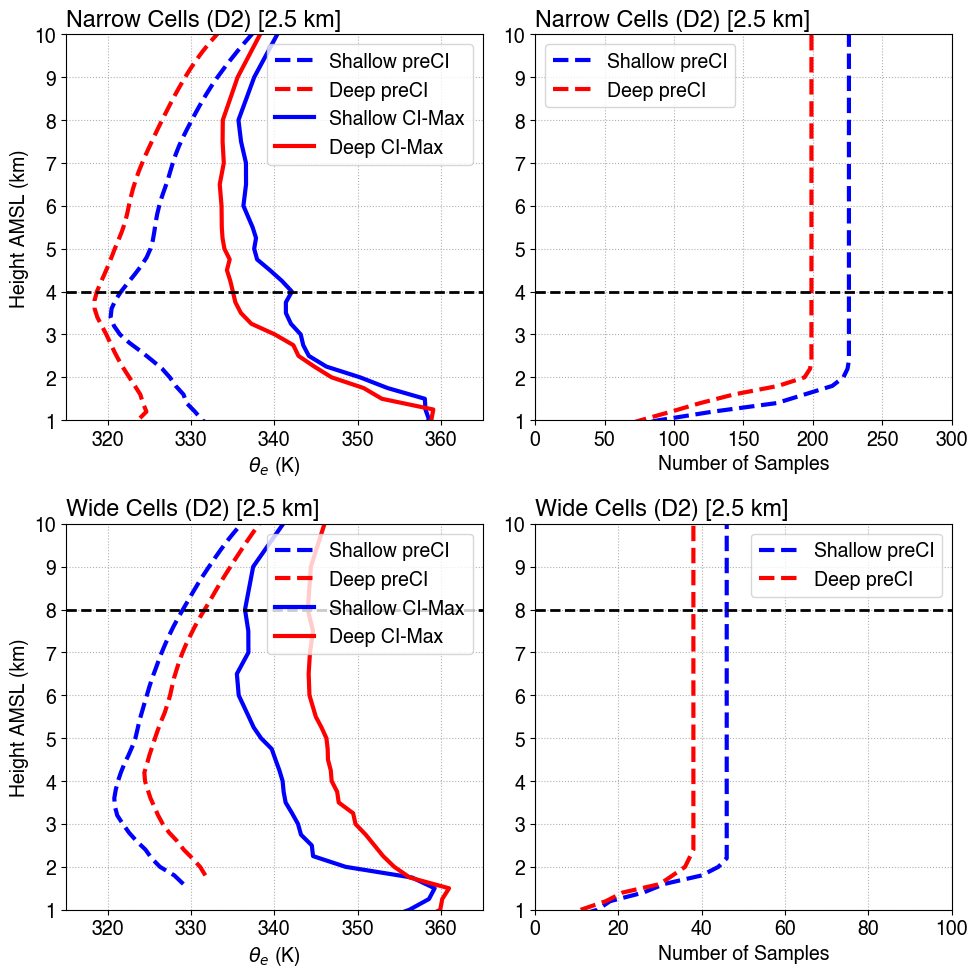

In [139]:
# min_ns_prof = 50
min_ns_prof = 30

prof1 = [
    [{'d':ThetaE_narrow_deep_avg_d2.where(ns_narrow_deep_prof_d2 > min_ns_prof), 's':ThetaE_narrow_shallow_avg_d2.where(ns_narrow_shallow_prof_d2 > min_ns_prof)},
     {'d':ns_narrow_deep_prof_d2, 's':ns_narrow_shallow_prof_d2}],
    [{'d':ThetaE_wide_deep_avg_d2.where(ns_wide_deep_prof_d2 > min_ns_prof), 's':ThetaE_wide_shallow_avg_d2.where(ns_wide_shallow_prof_d2 > min_ns_prof)},
     {'d':ns_wide_deep_prof_d2, 's':ns_wide_shallow_prof_d2}],
]
# prof2 = [
#     [{'d':MaxThetaE_narrow_deep_avg_d2.where(nsMaxThetaE_narrow_deep_prof_d2 > min_ns_prof), 's':MaxThetaE_narrow_shallow_avg_d2.where(nsMaxThetaE_narrow_shallow_prof_d2 > min_ns_prof)},
#      {'d':nsMaxThetaE_narrow_deep_prof_d2, 's':nsMaxThetaE_narrow_shallow_prof_d2}],
#     [{'d':MaxThetaE_wide_deep_avg_d2.where(nsMaxThetaE_wide_deep_prof_d2 > min_ns_prof), 's':MaxThetaE_wide_shallow_avg_d2.where(nsMaxThetaE_wide_shallow_prof_d2 > min_ns_prof)},
#      {'d':nsMaxThetaE_wide_deep_prof_d2, 's':nsMaxThetaE_wide_shallow_prof_d2}],
# ]
prof2 = [
    [{'d':MaxThetaE_narrow_deep_avg_d2, 's':MaxThetaE_narrow_shallow_avg_d2},
     {'d':nsMaxThetaE_narrow_deep_prof_d2, 's':nsMaxThetaE_narrow_shallow_prof_d2}],
    [{'d':MaxThetaE_wide_deep_avg_d2, 's':MaxThetaE_wide_shallow_avg_d2},
     {'d':nsMaxThetaE_wide_deep_prof_d2, 's':nsMaxThetaE_wide_shallow_prof_d2}],
]
z_thresh = [narrow_maxETH10dbz_thresh_d2, wide_maxETH10dbz_thresh_d2]
# prof = [
#     [{'d':ThetaE_narrow_deep_med_d2.where(ns_narrow_deep_prof_d2 > min_ns_prof), 's':ThetaE_narrow_shallow_med_d2.where(ns_narrow_shallow_prof_d2 > min_ns_prof)},
#      {'d':ns_narrow_deep_prof_d2, 's':ns_narrow_shallow_prof_d2}],
#     [{'d':ThetaE_wide_deep_med_d2.where(ns_wide_deep_prof_d2 > min_ns_prof), 's':ThetaE_wide_shallow_med_d2.where(ns_wide_shallow_prof_d2 > min_ns_prof)},
#      {'d':ns_wide_deep_prof_d2, 's':ns_wide_shallow_prof_d2}],
# ]
inqt25_w_d = ThetaE_wide_deep_inqt_d2.sel(quantile=0.25).where(ns_wide_deep_prof_d2 > min_ns_prof)
inqt75_w_d = ThetaE_wide_deep_inqt_d2.sel(quantile=0.75).where(ns_wide_deep_prof_d2 > min_ns_prof)
inqt25_w_s = ThetaE_wide_shallow_inqt_d2.sel(quantile=0.25).where(ns_wide_shallow_prof_d2 > min_ns_prof)
inqt75_w_s = ThetaE_wide_shallow_inqt_d2.sel(quantile=0.75).where(ns_wide_shallow_prof_d2 > min_ns_prof)
inqt25_n_d = ThetaE_narrow_deep_inqt_d2.sel(quantile=0.25).where(ns_narrow_deep_prof_d2 > min_ns_prof)
inqt75_n_d = ThetaE_narrow_deep_inqt_d2.sel(quantile=0.75).where(ns_narrow_deep_prof_d2 > min_ns_prof)
inqt25_n_s = ThetaE_narrow_shallow_inqt_d2.sel(quantile=0.25).where(ns_narrow_shallow_prof_d2 > min_ns_prof)
inqt75_n_s = ThetaE_narrow_shallow_inqt_d2.sel(quantile=0.75).where(ns_narrow_shallow_prof_d2 > min_ns_prof)
inqt = [{'d':(inqt25_n_d, inqt75_n_d), 's':(inqt25_n_s, inqt75_n_s)}, {'d':(inqt25_w_d, inqt75_w_d), 's':(inqt25_w_s, inqt75_w_s)}, ]
nrow = len(prof1)
ncol = len(prof1[0])
# nrow, ncol
xlabels = [
    [r'$\theta_e$ '+'(K)', 'Number of Samples'],
    [r'$\theta_e$ '+'(K)', 'Number of Samples'],
]
ylabels = [
    ['Height AMSL (km)', ''],
    ['Height AMSL (km)', ''],
]
titles = [
    ['Narrow Cells (D2) [2.5 km]', 'Narrow Cells (D2) [2.5 km]'],
    ['Wide Cells (D2) [2.5 km]', 'Wide Cells (D2) [2.5 km]'],
]
ylims = (1,10)
xlims = [
    [(315, 365), (0,300)],
    [(315, 365), (0,100)],
]
fontsize = 14
figsize = [10, 10]
figname = f'{figdir}PreCI_CIMax_Profile_NarrowWide_ThetaE_d2.png'
print(figname)
fig = plot_mxn_profs(nrow, ncol, prof1, prof2, inqt, height/1e3, height_core/1e3, z_thresh=z_thresh,
                    xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

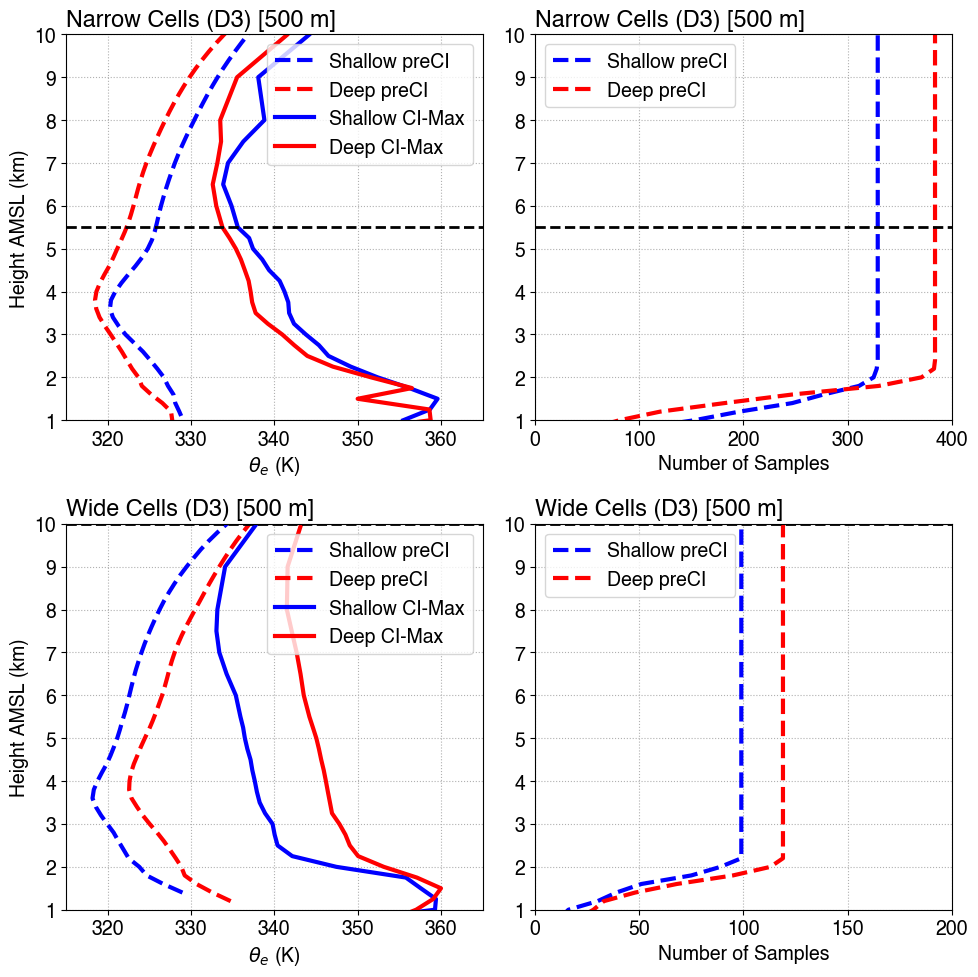

In [140]:
# prof = [
#     [{'d':ThetaE_narrow_deep_med_d3.where(ns_narrow_deep_prof_d3 > min_ns_prof), 's':ThetaE_narrow_shallow_med_d3.where(ns_narrow_shallow_prof_d3 > min_ns_prof)},
#      {'d':ns_narrow_deep_prof_d3, 's':ns_narrow_shallow_prof_d3}],
#     [{'d':ThetaE_wide_deep_med_d3.where(ns_wide_deep_prof_d3 > min_ns_prof), 's':ThetaE_wide_shallow_med_d3.where(ns_wide_shallow_prof_d3 > min_ns_prof)},
#      {'d':ns_wide_deep_prof_d3, 's':ns_wide_shallow_prof_d3}],
# ]
prof1 = [
    [{'d':ThetaE_narrow_deep_avg_d3.where(ns_narrow_deep_prof_d3 > min_ns_prof), 's':ThetaE_narrow_shallow_avg_d3.where(ns_narrow_shallow_prof_d3 > min_ns_prof)},
     {'d':ns_narrow_deep_prof_d3, 's':ns_narrow_shallow_prof_d3}],
    [{'d':ThetaE_wide_deep_avg_d3.where(ns_wide_deep_prof_d3 > min_ns_prof), 's':ThetaE_wide_shallow_avg_d3.where(ns_wide_shallow_prof_d3 > min_ns_prof)},
     {'d':ns_wide_deep_prof_d3, 's':ns_wide_shallow_prof_d3}],
]
prof2 = [
    [{'d':MaxThetaE_narrow_deep_avg_d3, 's':MaxThetaE_narrow_shallow_avg_d3},
     {'d':nsMaxThetaE_narrow_deep_prof_d3, 's':nsMaxThetaE_narrow_shallow_prof_d3}],
    [{'d':MaxThetaE_wide_deep_avg_d3, 's':MaxThetaE_wide_shallow_avg_d3},
     {'d':nsMaxThetaE_wide_deep_prof_d3, 's':nsMaxThetaE_wide_shallow_prof_d3}],
]
z_thresh = [narrow_maxETH10dbz_thresh_d3, wide_maxETH10dbz_thresh_d3]
inqt25_w_d = ThetaE_wide_deep_inqt_d3.sel(quantile=0.25).where(ns_wide_deep_prof_d3 > min_ns_prof)
inqt75_w_d = ThetaE_wide_deep_inqt_d3.sel(quantile=0.75).where(ns_wide_deep_prof_d3 > min_ns_prof)
inqt25_w_s = ThetaE_wide_shallow_inqt_d3.sel(quantile=0.25).where(ns_wide_shallow_prof_d3 > min_ns_prof)
inqt75_w_s = ThetaE_wide_shallow_inqt_d3.sel(quantile=0.75).where(ns_wide_shallow_prof_d3 > min_ns_prof)
inqt25_n_d = ThetaE_narrow_deep_inqt_d3.sel(quantile=0.25).where(ns_narrow_deep_prof_d3 > min_ns_prof)
inqt75_n_d = ThetaE_narrow_deep_inqt_d3.sel(quantile=0.75).where(ns_narrow_deep_prof_d3 > min_ns_prof)
inqt25_n_s = ThetaE_narrow_shallow_inqt_d3.sel(quantile=0.25).where(ns_narrow_shallow_prof_d3 > min_ns_prof)
inqt75_n_s = ThetaE_narrow_shallow_inqt_d3.sel(quantile=0.75).where(ns_narrow_shallow_prof_d3 > min_ns_prof)
inqt = [{'d':(inqt25_n_d, inqt75_n_d), 's':(inqt25_n_s, inqt75_n_s)}, {'d':(inqt25_w_d, inqt75_w_d), 's':(inqt25_w_s, inqt75_w_s)}, ]
nrow = len(prof1)
ncol = len(prof1[0])
# nrow, ncol
xlabels = [
    [r'$\theta_e$ '+'(K)', 'Number of Samples'],
    [r'$\theta_e$ '+'(K)', 'Number of Samples'],
]
ylabels = [
    ['Height AMSL (km)', ''],
    ['Height AMSL (km)', ''],
]
titles = [
    ['Narrow Cells (D3) [500 m]', 'Narrow Cells (D3) [500 m]'],
    ['Wide Cells (D3) [500 m]', 'Wide Cells (D3) [500 m]'],
]
ylims = (1,10)
xlims = [
    [(315, 365), (0,400)],
    [(315, 365), (0,200)],
]
fontsize = 14
figsize = [10, 10]
figname = f'{figdir}PreCI_CIMax_Profile_NarrowWide_ThetaE_d3.png'
fig = plot_mxn_profs(nrow, ncol, prof1, prof2, inqt, height/1e3, height_core/1e3, z_thresh=z_thresh,
                    xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

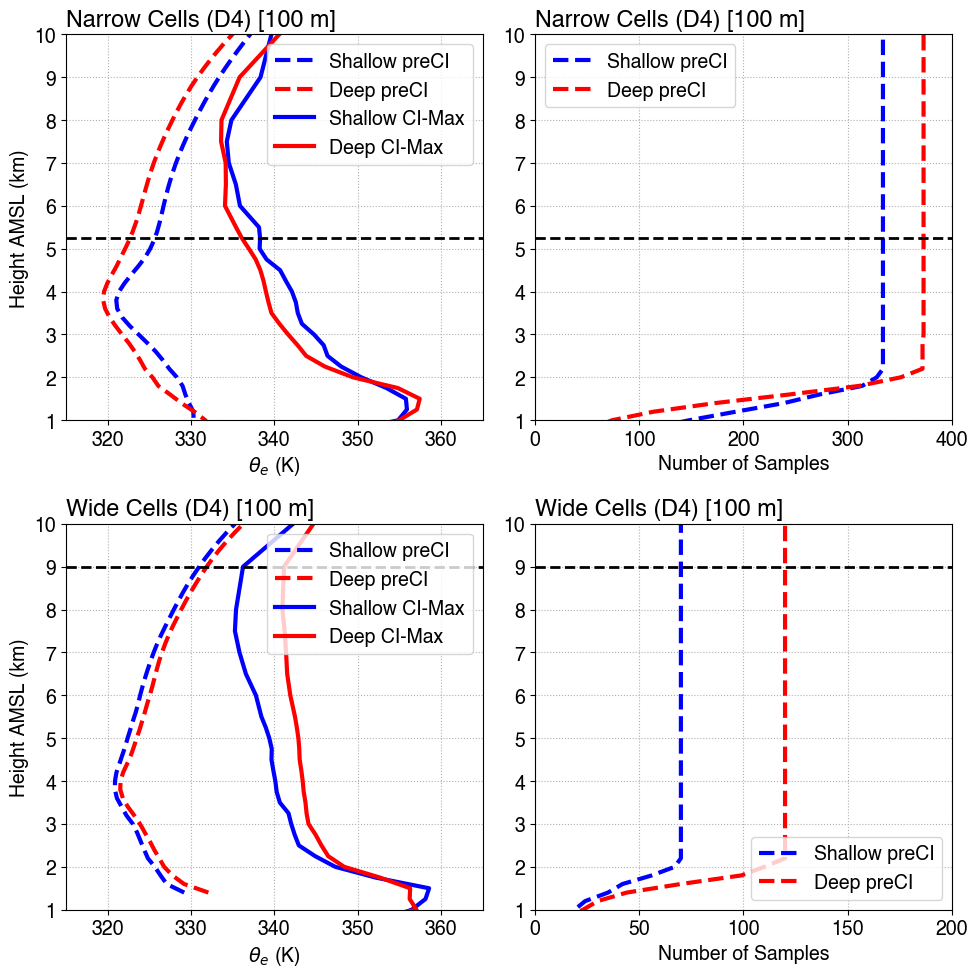

In [141]:
# prof = [
#     [{'d':ThetaE_narrow_deep_med_d4.where(ns_narrow_deep_prof_d4 > min_ns_prof), 's':ThetaE_narrow_shallow_med_d4.where(ns_narrow_shallow_prof_d4 > min_ns_prof)},
#      {'d':ns_narrow_deep_prof_d4, 's':ns_narrow_shallow_prof_d4}],
#     [{'d':ThetaE_wide_deep_med_d4.where(ns_wide_deep_prof_d4 > min_ns_prof), 's':ThetaE_wide_shallow_med_d4.where(ns_wide_shallow_prof_d4 > min_ns_prof)},
#      {'d':ns_wide_deep_prof_d4, 's':ns_wide_shallow_prof_d4}],
# ]
prof1 = [
    [{'d':ThetaE_narrow_deep_avg_d4.where(ns_narrow_deep_prof_d4 > min_ns_prof), 's':ThetaE_narrow_shallow_avg_d4.where(ns_narrow_shallow_prof_d4 > min_ns_prof)},
     {'d':ns_narrow_deep_prof_d4, 's':ns_narrow_shallow_prof_d4}],
    [{'d':ThetaE_wide_deep_avg_d4.where(ns_wide_deep_prof_d4 > min_ns_prof), 's':ThetaE_wide_shallow_avg_d4.where(ns_wide_shallow_prof_d4 > min_ns_prof)},
     {'d':ns_wide_deep_prof_d4, 's':ns_wide_shallow_prof_d4}],
]
prof2 = [
    [{'d':MaxThetaE_narrow_deep_avg_d4, 's':MaxThetaE_narrow_shallow_avg_d4},
     {'d':nsMaxThetaE_narrow_deep_prof_d4, 's':nsMaxThetaE_narrow_shallow_prof_d4}],
    [{'d':MaxThetaE_wide_deep_avg_d4, 's':MaxThetaE_wide_shallow_avg_d4},
     {'d':nsMaxThetaE_wide_deep_prof_d4, 's':nsMaxThetaE_wide_shallow_prof_d4}],
]
z_thresh = [narrow_maxETH10dbz_thresh_d4, wide_maxETH10dbz_thresh_d4]
inqt25_w_d = ThetaE_wide_deep_inqt_d4.sel(quantile=0.25).where(ns_wide_deep_prof_d4 > min_ns_prof)
inqt75_w_d = ThetaE_wide_deep_inqt_d4.sel(quantile=0.75).where(ns_wide_deep_prof_d4 > min_ns_prof)
inqt25_w_s = ThetaE_wide_shallow_inqt_d4.sel(quantile=0.25).where(ns_wide_shallow_prof_d4 > min_ns_prof)
inqt75_w_s = ThetaE_wide_shallow_inqt_d4.sel(quantile=0.75).where(ns_wide_shallow_prof_d4 > min_ns_prof)
inqt25_n_d = ThetaE_narrow_deep_inqt_d4.sel(quantile=0.25).where(ns_narrow_deep_prof_d4 > min_ns_prof)
inqt75_n_d = ThetaE_narrow_deep_inqt_d4.sel(quantile=0.75).where(ns_narrow_deep_prof_d4 > min_ns_prof)
inqt25_n_s = ThetaE_narrow_shallow_inqt_d4.sel(quantile=0.25).where(ns_narrow_shallow_prof_d4 > min_ns_prof)
inqt75_n_s = ThetaE_narrow_shallow_inqt_d4.sel(quantile=0.75).where(ns_narrow_shallow_prof_d4 > min_ns_prof)
inqt = [{'d':(inqt25_n_d, inqt75_n_d), 's':(inqt25_n_s, inqt75_n_s)}, {'d':(inqt25_w_d, inqt75_w_d), 's':(inqt25_w_s, inqt75_w_s)}, ]
nrow = len(prof1)
ncol = len(prof1[0])
# nrow, ncol
xlabels = [
    [r'$\theta_e$ '+'(K)', 'Number of Samples'],
    [r'$\theta_e$ '+'(K)', 'Number of Samples'],
]
ylabels = [
    ['Height AMSL (km)', ''],
    ['Height AMSL (km)', ''],
]
titles = [
    ['Narrow Cells (D4) [100 m]', 'Narrow Cells (D4) [100 m]'],
    ['Wide Cells (D4) [100 m]', 'Wide Cells (D4) [100 m]'],
]
ylims = (1,10)
xlims = [
    [(315, 365), (0,400)],
    [(315, 365), (0,200)],
]
fontsize = 14
figsize = [10, 10]
figname = f'{figdir}PreCI_CIMax_Profile_NarrowWide_ThetaE_d4.png'
fig = plot_mxn_profs(nrow, ncol, prof1, prof2, inqt, height/1e3, height_core/1e3, z_thresh=z_thresh,
                    xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

In [142]:
def plot_mxn_prof(nrow, ncol, prof, inqt, height, 
                  xlabels=None, ylabels=None, xlims=None, ylims=None, z_thresh=None,
                  titles=None, fontsize=None, figsize=None, figname=None):

    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize, dpi=100)
    # lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
    lcolors = {'d': 'red', 's': 'blue'}
    lstyles = {'min':'-', 'max':'-'}
    lw = 3
    name_map1 = {'d':'Deep preCI', 's':'Shallow preCI'}
    name_map2 = {'d':'Deep CI-Max', 's':'Shallow CI-Max'}
    alpha = 0.3
    
    for row in range(nrow):
        for col in range(ncol):
            ax = axes[row][col]
            prof_data = prof[row][col]
            # prof2_data = prof2[row][col]
            inqt_data = inqt[row]
            ax.plot(prof_data['s'], height, color=lcolors['s'], label=name_map1['s'], lw=lw, ls=lstyles['min'])
            ax.plot(prof_data['d'], height, color=lcolors['d'], label=name_map1['d'], lw=lw, ls=lstyles['min'])
            if col == 0:
                # ax.plot(prof2_data['s'], height_core, color=lcolors['s'], label=name_map2['s'], lw=lw, ls=lstyles['max'])
                # ax.plot(prof2_data['d'], height_core, color=lcolors['d'], label=name_map2['d'], lw=lw, ls=lstyles['max'])
                ax.fill_betweenx(height, inqt_data['s'][0], inqt_data['s'][1], facecolor=lcolors['s'], alpha=alpha)
                ax.fill_betweenx(height, inqt_data['d'][0], inqt_data['d'][1], facecolor=lcolors['d'], alpha=alpha)
            ax.legend()
            if (z_thresh is not None): 
                _z_thresh = z_thresh[row]
                ax.axhline(_z_thresh, linestyle='--', lw=2, color='k')
            if (xlims is not None): ax.set_xlim(min(xlims[row][col]), max(xlims[row][col]))
            if (ylims is not None): ax.set_ylim(min(ylims), max(ylims))
            ax.set_xlabel(xlabels[row][col])
            ax.set_ylabel(ylabels[row][col])
            ax.set_title(titles[row][col], loc='left')
            ax.grid(ls=':')
            
    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

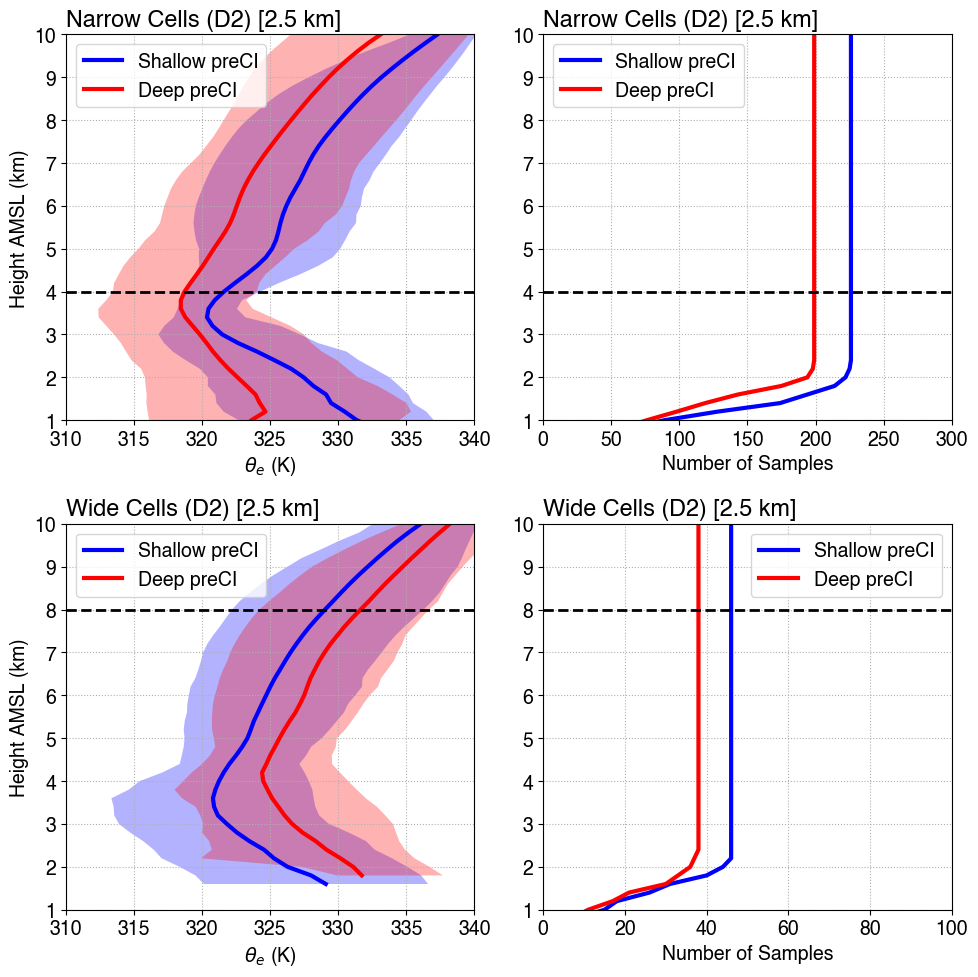

In [144]:
prof = [
    [{'d':ThetaE_narrow_deep_avg_d2.where(ns_narrow_deep_prof_d2 > min_ns_prof), 's':ThetaE_narrow_shallow_avg_d2.where(ns_narrow_shallow_prof_d2 > min_ns_prof)},
     {'d':ns_narrow_deep_prof_d2, 's':ns_narrow_shallow_prof_d2}],
    [{'d':ThetaE_wide_deep_avg_d2.where(ns_wide_deep_prof_d2 > min_ns_prof), 's':ThetaE_wide_shallow_avg_d2.where(ns_wide_shallow_prof_d2 > min_ns_prof)},
     {'d':ns_wide_deep_prof_d2, 's':ns_wide_shallow_prof_d2}],
]
z_thresh = [narrow_maxETH10dbz_thresh_d2, wide_maxETH10dbz_thresh_d2]
inqt25_w_d = ThetaE_wide_deep_inqt_d2.sel(quantile=0.25).where(ns_wide_deep_prof_d2 > min_ns_prof)
inqt75_w_d = ThetaE_wide_deep_inqt_d2.sel(quantile=0.75).where(ns_wide_deep_prof_d2 > min_ns_prof)
inqt25_w_s = ThetaE_wide_shallow_inqt_d2.sel(quantile=0.25).where(ns_wide_shallow_prof_d2 > min_ns_prof)
inqt75_w_s = ThetaE_wide_shallow_inqt_d2.sel(quantile=0.75).where(ns_wide_shallow_prof_d2 > min_ns_prof)
inqt25_n_d = ThetaE_narrow_deep_inqt_d2.sel(quantile=0.25).where(ns_narrow_deep_prof_d2 > min_ns_prof)
inqt75_n_d = ThetaE_narrow_deep_inqt_d2.sel(quantile=0.75).where(ns_narrow_deep_prof_d2 > min_ns_prof)
inqt25_n_s = ThetaE_narrow_shallow_inqt_d2.sel(quantile=0.25).where(ns_narrow_shallow_prof_d2 > min_ns_prof)
inqt75_n_s = ThetaE_narrow_shallow_inqt_d2.sel(quantile=0.75).where(ns_narrow_shallow_prof_d2 > min_ns_prof)
inqt = [{'d':(inqt25_n_d, inqt75_n_d), 's':(inqt25_n_s, inqt75_n_s)}, {'d':(inqt25_w_d, inqt75_w_d), 's':(inqt25_w_s, inqt75_w_s)}, ]
nrow = len(prof)
ncol = len(prof[0])
# nrow, ncol
xlabels = [
    [r'$\theta_e$ '+'(K)', 'Number of Samples'],
    [r'$\theta_e$ '+'(K)', 'Number of Samples'],
]
ylabels = [
    ['Height AMSL (km)', ''],
    ['Height AMSL (km)', ''],
]
titles = [
    ['Narrow Cells (D2) [2.5 km]', 'Narrow Cells (D2) [2.5 km]'],
    ['Wide Cells (D2) [2.5 km]', 'Wide Cells (D2) [2.5 km]'],
]
ylims = (1,10)
xlims = [
    [(310, 340), (0,300)],
    [(310, 340), (0,100)],
]
fontsize = 14
figsize = [10, 10]
figname = f'{figdir}PreCI_Profile_NarrowWide_ThetaE_d2.png'
fig = plot_mxn_prof(nrow, ncol, prof, inqt, height/1e3, z_thresh=z_thresh,
                    xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

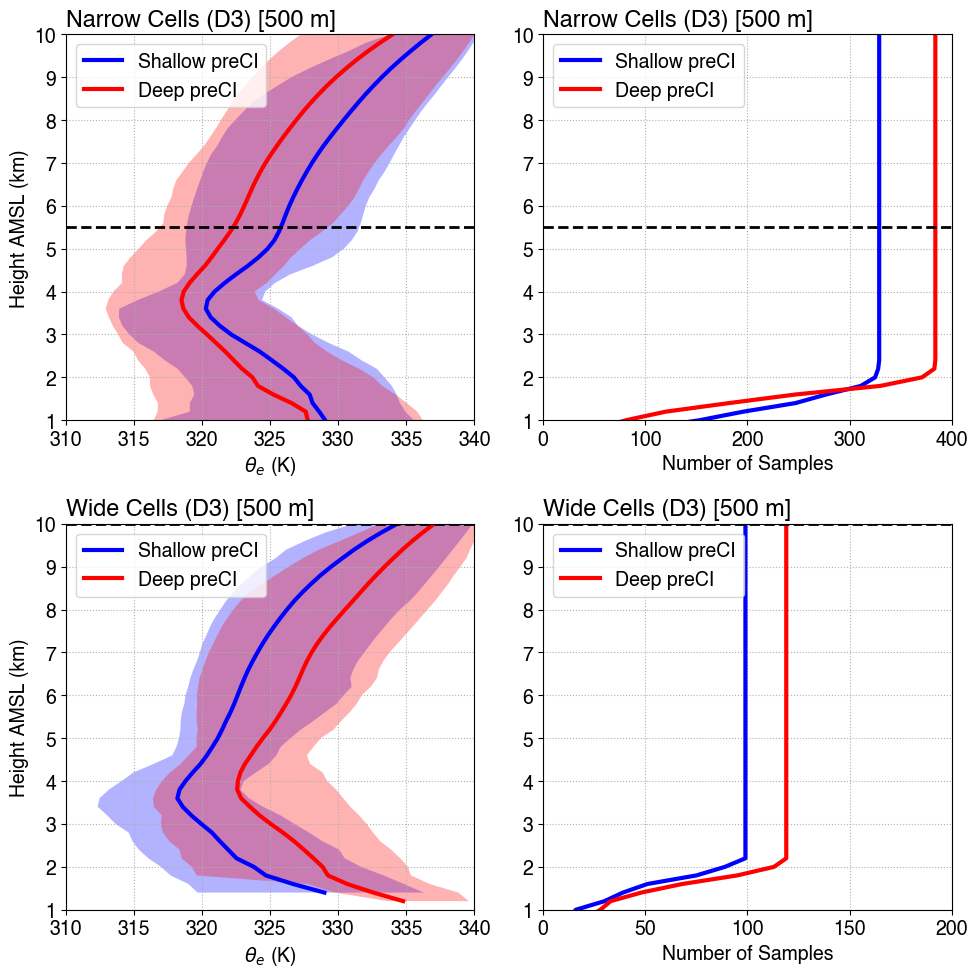

In [145]:
prof = [
    [{'d':ThetaE_narrow_deep_avg_d3.where(ns_narrow_deep_prof_d3 > min_ns_prof), 's':ThetaE_narrow_shallow_avg_d3.where(ns_narrow_shallow_prof_d3 > min_ns_prof)},
     {'d':ns_narrow_deep_prof_d3, 's':ns_narrow_shallow_prof_d3}],
    [{'d':ThetaE_wide_deep_avg_d3.where(ns_wide_deep_prof_d3 > min_ns_prof), 's':ThetaE_wide_shallow_avg_d3.where(ns_wide_shallow_prof_d3 > min_ns_prof)},
     {'d':ns_wide_deep_prof_d3, 's':ns_wide_shallow_prof_d3}],
]
z_thresh = [narrow_maxETH10dbz_thresh_d3, wide_maxETH10dbz_thresh_d3]
inqt25_w_d = ThetaE_wide_deep_inqt_d3.sel(quantile=0.25).where(ns_wide_deep_prof_d3 > min_ns_prof)
inqt75_w_d = ThetaE_wide_deep_inqt_d3.sel(quantile=0.75).where(ns_wide_deep_prof_d3 > min_ns_prof)
inqt25_w_s = ThetaE_wide_shallow_inqt_d3.sel(quantile=0.25).where(ns_wide_shallow_prof_d3 > min_ns_prof)
inqt75_w_s = ThetaE_wide_shallow_inqt_d3.sel(quantile=0.75).where(ns_wide_shallow_prof_d3 > min_ns_prof)
inqt25_n_d = ThetaE_narrow_deep_inqt_d3.sel(quantile=0.25).where(ns_narrow_deep_prof_d3 > min_ns_prof)
inqt75_n_d = ThetaE_narrow_deep_inqt_d3.sel(quantile=0.75).where(ns_narrow_deep_prof_d3 > min_ns_prof)
inqt25_n_s = ThetaE_narrow_shallow_inqt_d3.sel(quantile=0.25).where(ns_narrow_shallow_prof_d3 > min_ns_prof)
inqt75_n_s = ThetaE_narrow_shallow_inqt_d3.sel(quantile=0.75).where(ns_narrow_shallow_prof_d3 > min_ns_prof)
inqt = [{'d':(inqt25_n_d, inqt75_n_d), 's':(inqt25_n_s, inqt75_n_s)}, {'d':(inqt25_w_d, inqt75_w_d), 's':(inqt25_w_s, inqt75_w_s)}, ]
nrow = len(prof)
ncol = len(prof[0])
# nrow, ncol
xlabels = [
    [r'$\theta_e$ '+'(K)', 'Number of Samples'],
    [r'$\theta_e$ '+'(K)', 'Number of Samples'],
]
ylabels = [
    ['Height AMSL (km)', ''],
    ['Height AMSL (km)', ''],
]
titles = [
    ['Narrow Cells (D3) [500 m]', 'Narrow Cells (D3) [500 m]'],
    ['Wide Cells (D3) [500 m]', 'Wide Cells (D3) [500 m]'],
]
ylims = (1,10)
xlims = [
    [(310, 340), (0,400)],
    [(310, 340), (0,200)],
]
fontsize = 14
figsize = [10, 10]
figname = f'{figdir}PreCI_Profile_NarrowWide_ThetaE_d3.png'
fig = plot_mxn_prof(nrow, ncol, prof, inqt, height/1e3, z_thresh=z_thresh,
                    xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

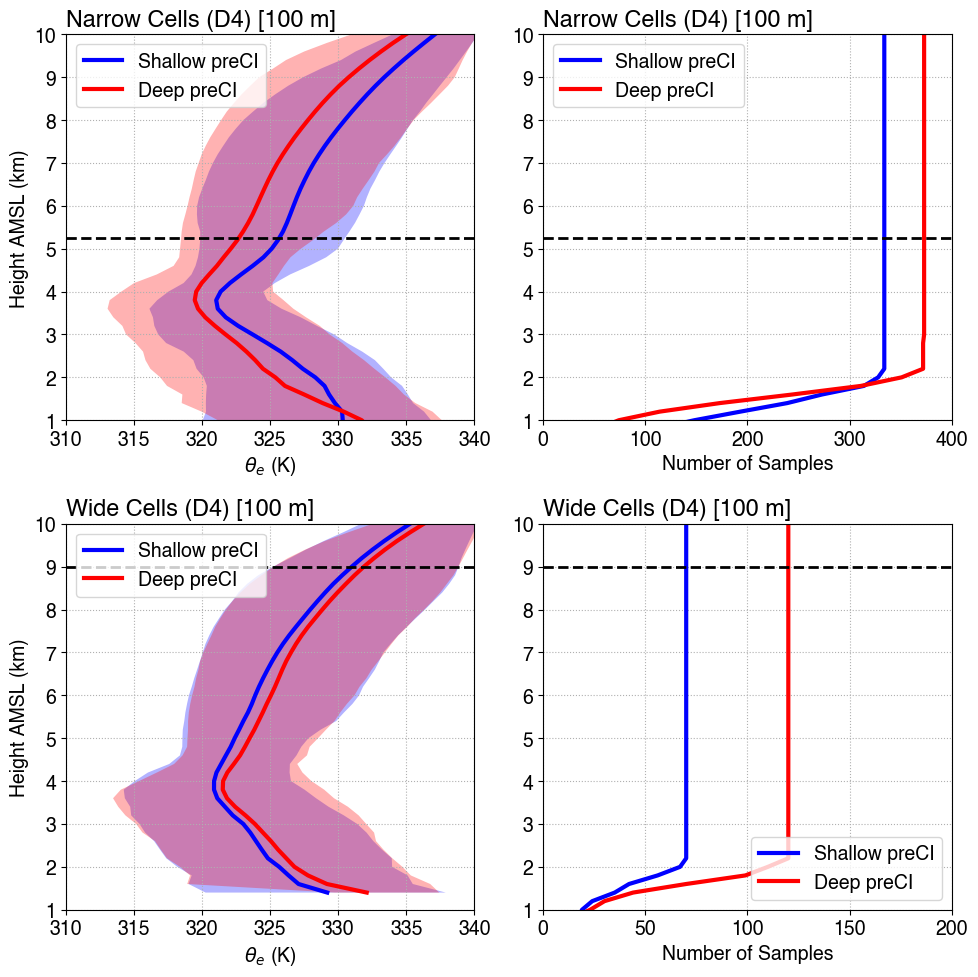

In [146]:
prof = [
    [{'d':ThetaE_narrow_deep_avg_d4.where(ns_narrow_deep_prof_d4 > min_ns_prof), 's':ThetaE_narrow_shallow_avg_d4.where(ns_narrow_shallow_prof_d4 > min_ns_prof)},
     {'d':ns_narrow_deep_prof_d4, 's':ns_narrow_shallow_prof_d4}],
    [{'d':ThetaE_wide_deep_avg_d4.where(ns_wide_deep_prof_d4 > min_ns_prof), 's':ThetaE_wide_shallow_avg_d4.where(ns_wide_shallow_prof_d4 > min_ns_prof)},
     {'d':ns_wide_deep_prof_d4, 's':ns_wide_shallow_prof_d4}],
]
z_thresh = [narrow_maxETH10dbz_thresh_d4, wide_maxETH10dbz_thresh_d4]
inqt25_w_d = ThetaE_wide_deep_inqt_d4.sel(quantile=0.25).where(ns_wide_deep_prof_d4 > min_ns_prof)
inqt75_w_d = ThetaE_wide_deep_inqt_d4.sel(quantile=0.75).where(ns_wide_deep_prof_d4 > min_ns_prof)
inqt25_w_s = ThetaE_wide_shallow_inqt_d4.sel(quantile=0.25).where(ns_wide_shallow_prof_d4 > min_ns_prof)
inqt75_w_s = ThetaE_wide_shallow_inqt_d4.sel(quantile=0.75).where(ns_wide_shallow_prof_d4 > min_ns_prof)
inqt25_n_d = ThetaE_narrow_deep_inqt_d4.sel(quantile=0.25).where(ns_narrow_deep_prof_d4 > min_ns_prof)
inqt75_n_d = ThetaE_narrow_deep_inqt_d4.sel(quantile=0.75).where(ns_narrow_deep_prof_d4 > min_ns_prof)
inqt25_n_s = ThetaE_narrow_shallow_inqt_d4.sel(quantile=0.25).where(ns_narrow_shallow_prof_d4 > min_ns_prof)
inqt75_n_s = ThetaE_narrow_shallow_inqt_d4.sel(quantile=0.75).where(ns_narrow_shallow_prof_d4 > min_ns_prof)
inqt = [{'d':(inqt25_n_d, inqt75_n_d), 's':(inqt25_n_s, inqt75_n_s)}, {'d':(inqt25_w_d, inqt75_w_d), 's':(inqt25_w_s, inqt75_w_s)}, ]
nrow = len(prof)
ncol = len(prof[0])
# nrow, ncol
xlabels = [
    [r'$\theta_e$ '+'(K)', 'Number of Samples'],
    [r'$\theta_e$ '+'(K)', 'Number of Samples'],
]
ylabels = [
    ['Height AMSL (km)', ''],
    ['Height AMSL (km)', ''],
]
titles = [
    ['Narrow Cells (D4) [100 m]', 'Narrow Cells (D4) [100 m]'],
    ['Wide Cells (D4) [100 m]', 'Wide Cells (D4) [100 m]'],
]
ylims = (1,10)
xlims = [
    [(310, 340), (0,400)],
    [(310, 340), (0,200)],
]
fontsize = 14
figsize = [10, 10]
figname = f'{figdir}PreCI_Profile_NarrowWide_ThetaE_d4.png'
fig = plot_mxn_prof(nrow, ncol, prof, inqt, height/1e3, z_thresh=z_thresh,
                    xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

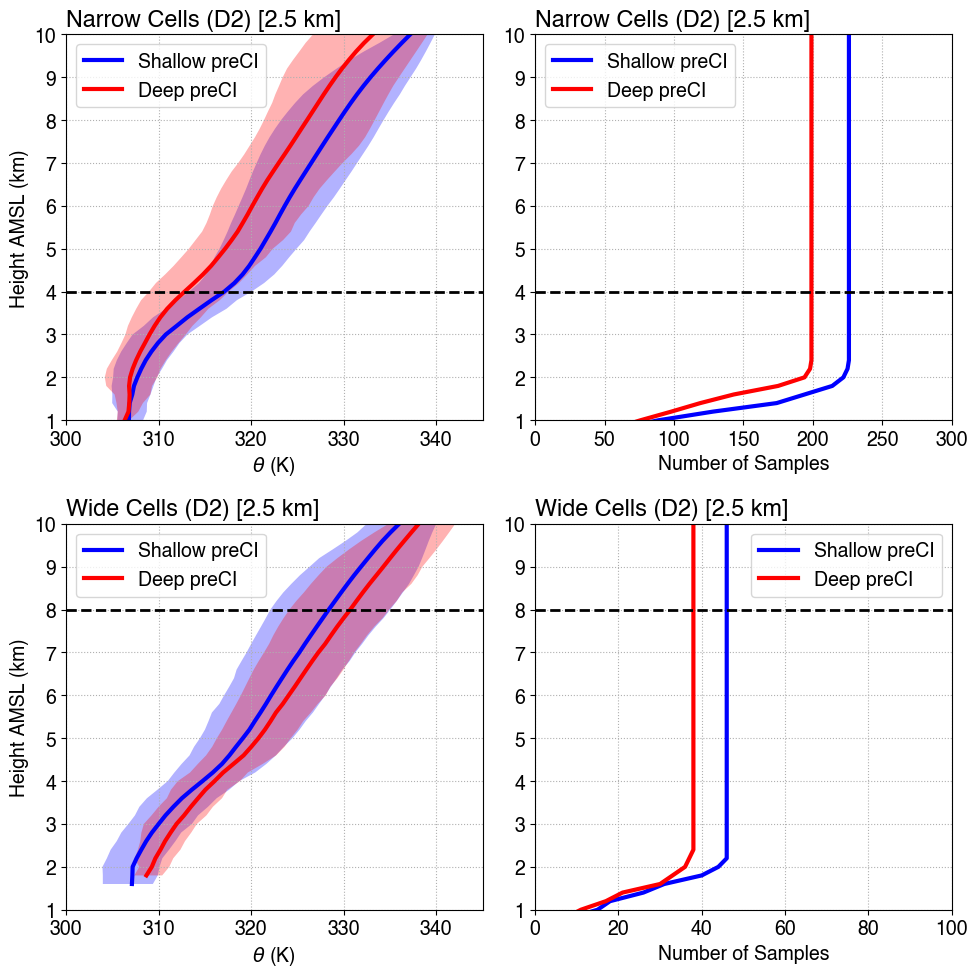

In [147]:
prof = [
    [{'d':Theta_narrow_deep_avg_d2.where(ns_narrow_deep_prof_d2 > min_ns_prof), 's':Theta_narrow_shallow_avg_d2.where(ns_narrow_shallow_prof_d2 > min_ns_prof)},
     {'d':ns_narrow_deep_prof_d2, 's':ns_narrow_shallow_prof_d2}],
    [{'d':Theta_wide_deep_avg_d2.where(ns_wide_deep_prof_d2 > min_ns_prof), 's':Theta_wide_shallow_avg_d2.where(ns_wide_shallow_prof_d2 > min_ns_prof)},
     {'d':ns_wide_deep_prof_d2, 's':ns_wide_shallow_prof_d2}],
]
z_thresh = [narrow_maxETH10dbz_thresh_d2, wide_maxETH10dbz_thresh_d2]
inqt25_w_d = Theta_wide_deep_inqt_d2.sel(quantile=0.25).where(ns_wide_deep_prof_d2 > min_ns_prof)
inqt75_w_d = Theta_wide_deep_inqt_d2.sel(quantile=0.75).where(ns_wide_deep_prof_d2 > min_ns_prof)
inqt25_w_s = Theta_wide_shallow_inqt_d2.sel(quantile=0.25).where(ns_wide_shallow_prof_d2 > min_ns_prof)
inqt75_w_s = Theta_wide_shallow_inqt_d2.sel(quantile=0.75).where(ns_wide_shallow_prof_d2 > min_ns_prof)
inqt25_n_d = Theta_narrow_deep_inqt_d2.sel(quantile=0.25).where(ns_narrow_deep_prof_d2 > min_ns_prof)
inqt75_n_d = Theta_narrow_deep_inqt_d2.sel(quantile=0.75).where(ns_narrow_deep_prof_d2 > min_ns_prof)
inqt25_n_s = Theta_narrow_shallow_inqt_d2.sel(quantile=0.25).where(ns_narrow_shallow_prof_d2 > min_ns_prof)
inqt75_n_s = Theta_narrow_shallow_inqt_d2.sel(quantile=0.75).where(ns_narrow_shallow_prof_d2 > min_ns_prof)
inqt = [{'d':(inqt25_n_d, inqt75_n_d), 's':(inqt25_n_s, inqt75_n_s)}, {'d':(inqt25_w_d, inqt75_w_d), 's':(inqt25_w_s, inqt75_w_s)}, ]
nrow = len(prof)
ncol = len(prof[0])
# nrow, ncol
xlabels = [
    [r'$\theta$ '+'(K)', 'Number of Samples'],
    [r'$\theta$ '+'(K)', 'Number of Samples'],
]
ylabels = [
    ['Height AMSL (km)', ''],
    ['Height AMSL (km)', ''],
]
titles = [
    ['Narrow Cells (D2) [2.5 km]', 'Narrow Cells (D2) [2.5 km]'],
    ['Wide Cells (D2) [2.5 km]', 'Wide Cells (D2) [2.5 km]'],
]
ylims = (1,10)
xlims = [
    [(300, 345), (0,300)],
    [(300, 345), (0,100)],
]
fontsize = 14
figsize = [10, 10]
figname = f'{figdir}PreCI_Profile_NarrowWide_Theta_d2.png'
fig = plot_mxn_prof(nrow, ncol, prof, inqt, height/1e3, z_thresh=z_thresh,
                    xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

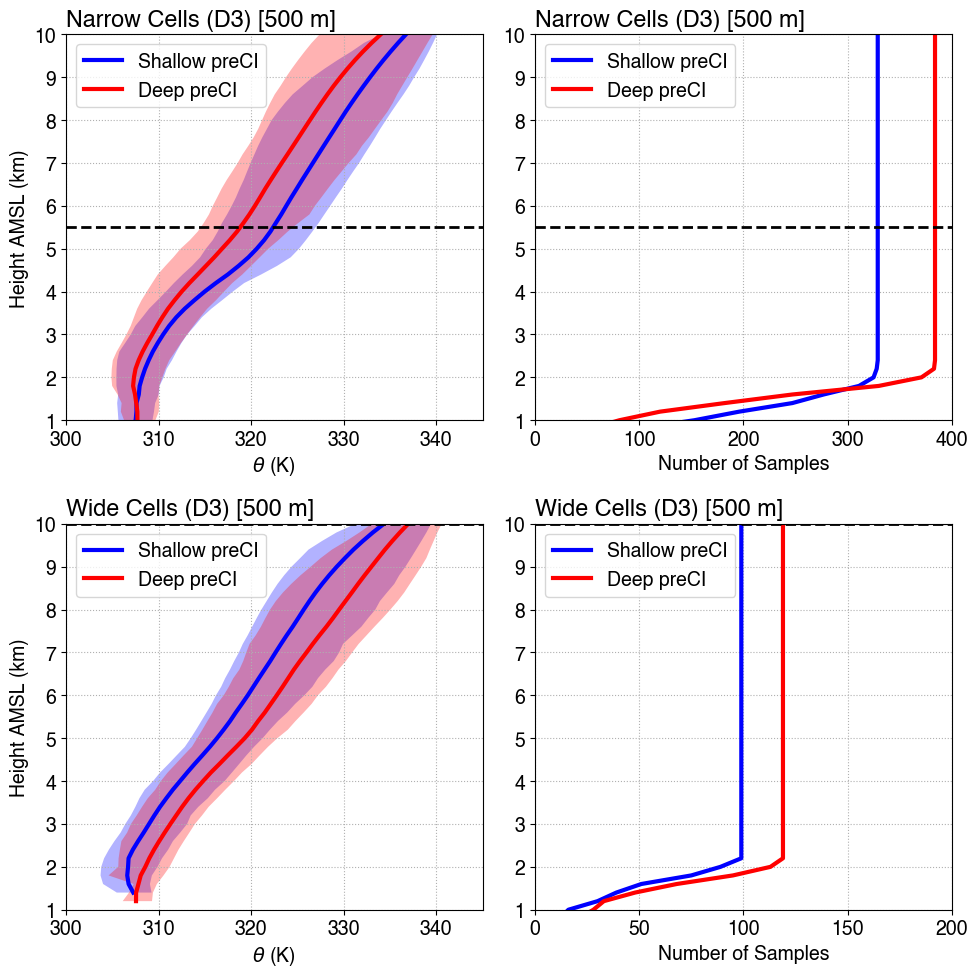

In [148]:
prof = [
    [{'d':Theta_narrow_deep_avg_d3.where(ns_narrow_deep_prof_d3 > min_ns_prof), 's':Theta_narrow_shallow_avg_d3.where(ns_narrow_shallow_prof_d3 > min_ns_prof)},
     {'d':ns_narrow_deep_prof_d3, 's':ns_narrow_shallow_prof_d3}],
    [{'d':Theta_wide_deep_avg_d3.where(ns_wide_deep_prof_d3 > min_ns_prof), 's':Theta_wide_shallow_avg_d3.where(ns_wide_shallow_prof_d3 > min_ns_prof)},
     {'d':ns_wide_deep_prof_d3, 's':ns_wide_shallow_prof_d3}],
]
z_thresh = [narrow_maxETH10dbz_thresh_d3, wide_maxETH10dbz_thresh_d3]
inqt25_w_d = Theta_wide_deep_inqt_d3.sel(quantile=0.25).where(ns_wide_deep_prof_d3 > min_ns_prof)
inqt75_w_d = Theta_wide_deep_inqt_d3.sel(quantile=0.75).where(ns_wide_deep_prof_d3 > min_ns_prof)
inqt25_w_s = Theta_wide_shallow_inqt_d3.sel(quantile=0.25).where(ns_wide_shallow_prof_d3 > min_ns_prof)
inqt75_w_s = Theta_wide_shallow_inqt_d3.sel(quantile=0.75).where(ns_wide_shallow_prof_d3 > min_ns_prof)
inqt25_n_d = Theta_narrow_deep_inqt_d3.sel(quantile=0.25).where(ns_narrow_deep_prof_d3 > min_ns_prof)
inqt75_n_d = Theta_narrow_deep_inqt_d3.sel(quantile=0.75).where(ns_narrow_deep_prof_d3 > min_ns_prof)
inqt25_n_s = Theta_narrow_shallow_inqt_d3.sel(quantile=0.25).where(ns_narrow_shallow_prof_d3 > min_ns_prof)
inqt75_n_s = Theta_narrow_shallow_inqt_d3.sel(quantile=0.75).where(ns_narrow_shallow_prof_d3 > min_ns_prof)
inqt = [{'d':(inqt25_n_d, inqt75_n_d), 's':(inqt25_n_s, inqt75_n_s)}, {'d':(inqt25_w_d, inqt75_w_d), 's':(inqt25_w_s, inqt75_w_s)}, ]
nrow = len(prof)
ncol = len(prof[0])
# nrow, ncol
xlabels = [
    [r'$\theta$ '+'(K)', 'Number of Samples'],
    [r'$\theta$ '+'(K)', 'Number of Samples'],
]
ylabels = [
    ['Height AMSL (km)', ''],
    ['Height AMSL (km)', ''],
]
titles = [
    ['Narrow Cells (D3) [500 m]', 'Narrow Cells (D3) [500 m]'],
    ['Wide Cells (D3) [500 m]', 'Wide Cells (D3) [500 m]'],
]
ylims = (1,10)
xlims = [
    [(300, 345), (0,400)],
    [(300, 345), (0,200)],
]
fontsize = 14
figsize = [10, 10]
figname = f'{figdir}PreCI_Profile_NarrowWide_Theta_d3.png'
fig = plot_mxn_prof(nrow, ncol, prof, inqt, height/1e3, z_thresh=z_thresh,
                    xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

In [260]:
# prof = [
#     [{'d':Theta_narrow_deep_avg_d3.where(ns_narrow_deep_prof_d3 > min_ns_prof), 's':Theta_narrow_shallow_avg_d3.where(ns_narrow_shallow_prof_d3 > min_ns_prof)},
#      {'d':ns_narrow_deep_prof_d3, 's':ns_narrow_shallow_prof_d3}],
#     [{'d':Theta_wide_deep_avg_d3.where(ns_wide_deep_prof_d3 > min_ns_prof), 's':Theta_wide_shallow_avg_d3.where(ns_wide_shallow_prof_d3 > min_ns_prof)},
#      {'d':ns_wide_deep_prof_d3, 's':ns_wide_shallow_prof_d3}],
# ]
# inqt25_w_d = Theta_wide_deep_inqt_d3.sel(quantile=0.25).where(ns_wide_deep_prof_d3 > min_ns_prof)
# inqt75_w_d = Theta_wide_deep_inqt_d3.sel(quantile=0.75).where(ns_wide_deep_prof_d3 > min_ns_prof)
# inqt25_w_s = Theta_wide_shallow_inqt_d3.sel(quantile=0.25).where(ns_wide_shallow_prof_d3 > min_ns_prof)
# inqt75_w_s = Theta_wide_shallow_inqt_d3.sel(quantile=0.75).where(ns_wide_shallow_prof_d3 > min_ns_prof)
# inqt25_n_d = Theta_narrow_deep_inqt_d3.sel(quantile=0.25).where(ns_narrow_deep_prof_d3 > min_ns_prof)
# inqt75_n_d = Theta_narrow_deep_inqt_d3.sel(quantile=0.75).where(ns_narrow_deep_prof_d3 > min_ns_prof)
# inqt25_n_s = Theta_narrow_shallow_inqt_d3.sel(quantile=0.25).where(ns_narrow_shallow_prof_d3 > min_ns_prof)
# inqt75_n_s = Theta_narrow_shallow_inqt_d3.sel(quantile=0.75).where(ns_narrow_shallow_prof_d3 > min_ns_prof)
# inqt = [{'d':(inqt25_n_d, inqt75_n_d), 's':(inqt25_n_s, inqt75_n_s)}, {'d':(inqt25_w_d, inqt75_w_d), 's':(inqt25_w_s, inqt75_w_s)}, ]
# nrow = len(prof)
# ncol = len(prof[0])
# # nrow, ncol
# xlabels = [
#     [r'$\theta$ '+'(K)', 'Number of Samples'],
#     [r'$\theta$ '+'(K)', 'Number of Samples'],
# ]
# ylabels = [
#     ['Height AMSL (km)', ''],
#     ['Height AMSL (km)', ''],
# ]
# titles = [
#     ['Narrow Cells (D3) [500 m]', 'Narrow Cells (D3) [500 m]'],
#     ['Wide Cells (D3) [500 m]', 'Wide Cells (D3) [500 m]'],
# ]
# ylims = (1,10)
# xlims = [
#     [(300, 345), (0,600)],
#     [(300, 345), (0,600)],
# ]
# fontsize = 14
# figsize = [10, 10]
# figname = f'{figdir}PreCI_Profile_NarrowWide_Theta_d3.png'
# fig = plot_mxn_prof(nrow, ncol, prof, inqt, height/1e3, z_thresh=maxETH10dbz_thresh_d3,
#                     xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

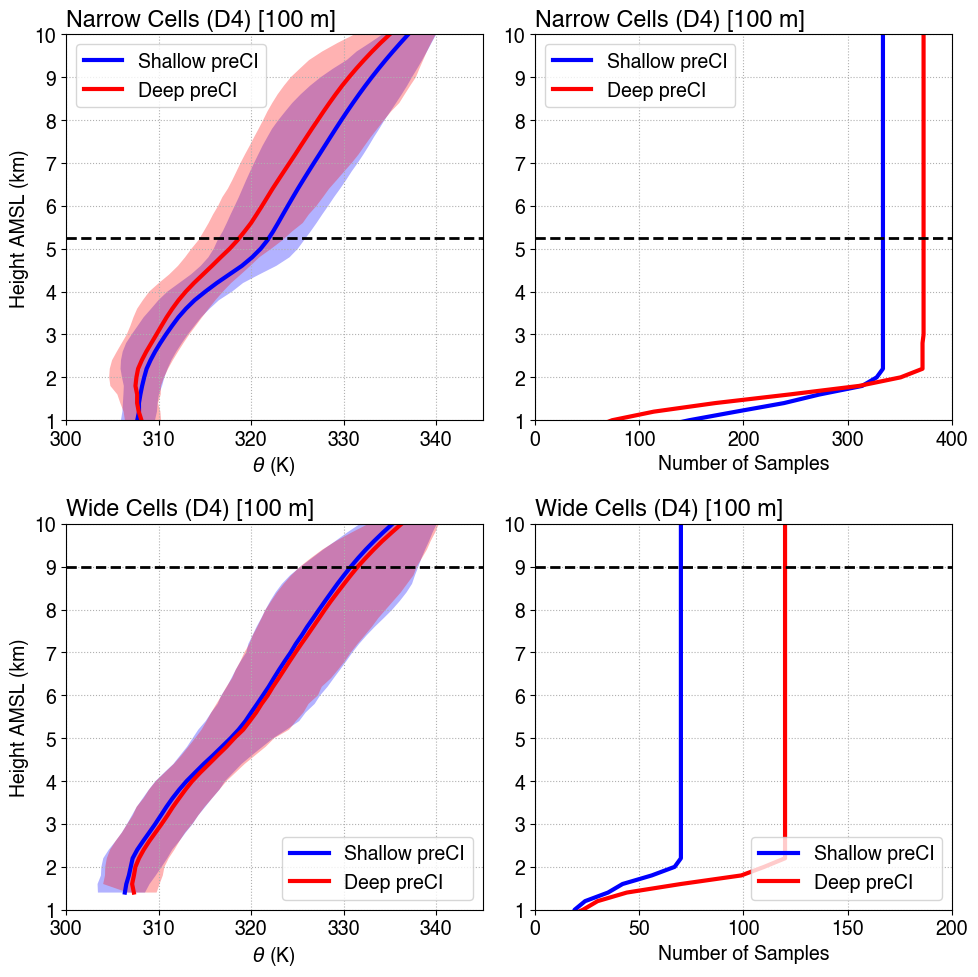

In [149]:
prof = [
    [{'d':Theta_narrow_deep_avg_d4.where(ns_narrow_deep_prof_d4 > min_ns_prof), 's':Theta_narrow_shallow_avg_d4.where(ns_narrow_shallow_prof_d4 > min_ns_prof)},
     {'d':ns_narrow_deep_prof_d4, 's':ns_narrow_shallow_prof_d4}],
    [{'d':Theta_wide_deep_avg_d4.where(ns_wide_deep_prof_d4 > min_ns_prof), 's':Theta_wide_shallow_avg_d4.where(ns_wide_shallow_prof_d4 > min_ns_prof)},
     {'d':ns_wide_deep_prof_d4, 's':ns_wide_shallow_prof_d4}],
]
z_thresh = [narrow_maxETH10dbz_thresh_d4, wide_maxETH10dbz_thresh_d4]
inqt25_w_d = Theta_wide_deep_inqt_d4.sel(quantile=0.25).where(ns_wide_deep_prof_d4 > min_ns_prof)
inqt75_w_d = Theta_wide_deep_inqt_d4.sel(quantile=0.75).where(ns_wide_deep_prof_d4 > min_ns_prof)
inqt25_w_s = Theta_wide_shallow_inqt_d4.sel(quantile=0.25).where(ns_wide_shallow_prof_d4 > min_ns_prof)
inqt75_w_s = Theta_wide_shallow_inqt_d4.sel(quantile=0.75).where(ns_wide_shallow_prof_d4 > min_ns_prof)
inqt25_n_d = Theta_narrow_deep_inqt_d4.sel(quantile=0.25).where(ns_narrow_deep_prof_d4 > min_ns_prof)
inqt75_n_d = Theta_narrow_deep_inqt_d4.sel(quantile=0.75).where(ns_narrow_deep_prof_d4 > min_ns_prof)
inqt25_n_s = Theta_narrow_shallow_inqt_d4.sel(quantile=0.25).where(ns_narrow_shallow_prof_d4 > min_ns_prof)
inqt75_n_s = Theta_narrow_shallow_inqt_d4.sel(quantile=0.75).where(ns_narrow_shallow_prof_d4 > min_ns_prof)
inqt = [{'d':(inqt25_n_d, inqt75_n_d), 's':(inqt25_n_s, inqt75_n_s)}, {'d':(inqt25_w_d, inqt75_w_d), 's':(inqt25_w_s, inqt75_w_s)}, ]
nrow = len(prof)
ncol = len(prof[0])
# nrow, ncol
xlabels = [
    [r'$\theta$ '+'(K)', 'Number of Samples'],
    [r'$\theta$ '+'(K)', 'Number of Samples'],
]
ylabels = [
    ['Height AMSL (km)', ''],
    ['Height AMSL (km)', ''],
]
titles = [
    ['Narrow Cells (D4) [100 m]', 'Narrow Cells (D4) [100 m]'],
    ['Wide Cells (D4) [100 m]', 'Wide Cells (D4) [100 m]'],
]
ylims = (1,10)
xlims = [
    [(300, 345), (0,400)],
    [(300, 345), (0,200)],
]
fontsize = 14
figsize = [10, 10]
figname = f'{figdir}PreCI_Profile_NarrowWide_Theta_d4.png'
fig = plot_mxn_prof(nrow, ncol, prof, inqt, height/1e3, z_thresh=z_thresh,
                    xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

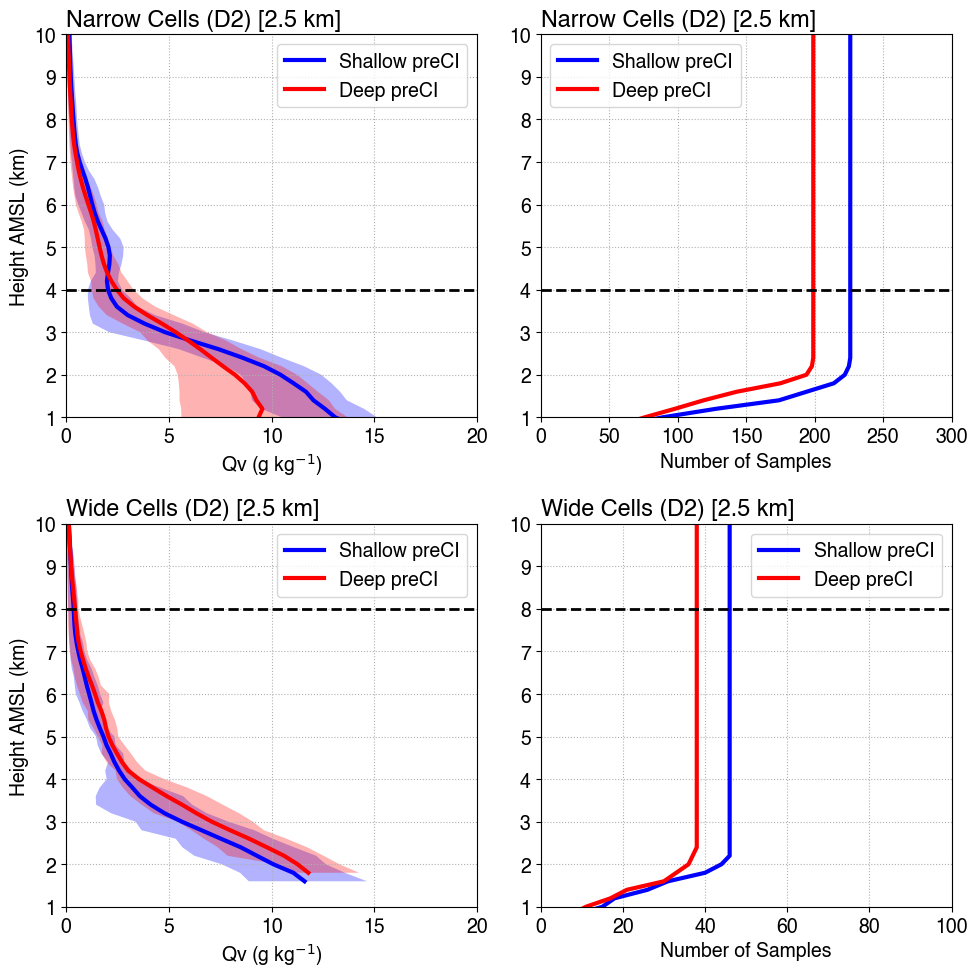

In [150]:
prof = [
    [{'d':qv_narrow_deep_avg_d2.where(ns_narrow_deep_prof_d2 > min_ns_prof)*1e3, 's':qv_narrow_shallow_avg_d2.where(ns_narrow_shallow_prof_d2 > min_ns_prof)*1e3},
     {'d':ns_narrow_deep_prof_d2, 's':ns_narrow_shallow_prof_d2}],
    [{'d':qv_wide_deep_avg_d2.where(ns_wide_deep_prof_d2 > min_ns_prof)*1e3, 's':qv_wide_shallow_avg_d2.where(ns_wide_shallow_prof_d2 > min_ns_prof)*1e3},
     {'d':ns_wide_deep_prof_d2, 's':ns_wide_shallow_prof_d2}],
]
z_thresh = [narrow_maxETH10dbz_thresh_d2, wide_maxETH10dbz_thresh_d2]
inqt25_w_d = qv_wide_deep_inqt_d2.sel(quantile=0.25).where(ns_wide_deep_prof_d2 > min_ns_prof)*1e3
inqt75_w_d = qv_wide_deep_inqt_d2.sel(quantile=0.75).where(ns_wide_deep_prof_d2 > min_ns_prof)*1e3
inqt25_w_s = qv_wide_shallow_inqt_d2.sel(quantile=0.25).where(ns_wide_shallow_prof_d2 > min_ns_prof)*1e3
inqt75_w_s = qv_wide_shallow_inqt_d2.sel(quantile=0.75).where(ns_wide_shallow_prof_d2 > min_ns_prof)*1e3
inqt25_n_d = qv_narrow_deep_inqt_d2.sel(quantile=0.25).where(ns_narrow_deep_prof_d2 > min_ns_prof)*1e3
inqt75_n_d = qv_narrow_deep_inqt_d2.sel(quantile=0.75).where(ns_narrow_deep_prof_d2 > min_ns_prof)*1e3
inqt25_n_s = qv_narrow_shallow_inqt_d2.sel(quantile=0.25).where(ns_narrow_shallow_prof_d2 > min_ns_prof)*1e3
inqt75_n_s = qv_narrow_shallow_inqt_d2.sel(quantile=0.75).where(ns_narrow_shallow_prof_d2 > min_ns_prof)*1e3
inqt = [{'d':(inqt25_n_d, inqt75_n_d), 's':(inqt25_n_s, inqt75_n_s)}, {'d':(inqt25_w_d, inqt75_w_d), 's':(inqt25_w_s, inqt75_w_s)}, ]
nrow = len(prof)
ncol = len(prof[0])
# nrow, ncol
xlabels = [
    ['Qv (g kg$^{-1}$)', 'Number of Samples'],
    ['Qv (g kg$^{-1}$)', 'Number of Samples'],
]
ylabels = [
    ['Height AMSL (km)', ''],
    ['Height AMSL (km)', ''],
]
titles = [
    ['Narrow Cells (D2) [2.5 km]', 'Narrow Cells (D2) [2.5 km]'],
    ['Wide Cells (D2) [2.5 km]', 'Wide Cells (D2) [2.5 km]'],
]
ylims = (1,10)
# xlims = None
xlims = [
    [(0, 20), (0,300)],
    [(0, 20), (0,100)],
]
fontsize = 14
figsize = [10, 10]
figname = f'{figdir}PreCI_Profile_NarrowWide_qv_d2.png'
fig = plot_mxn_prof(nrow, ncol, prof, inqt, height/1e3, z_thresh=z_thresh,
                    xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

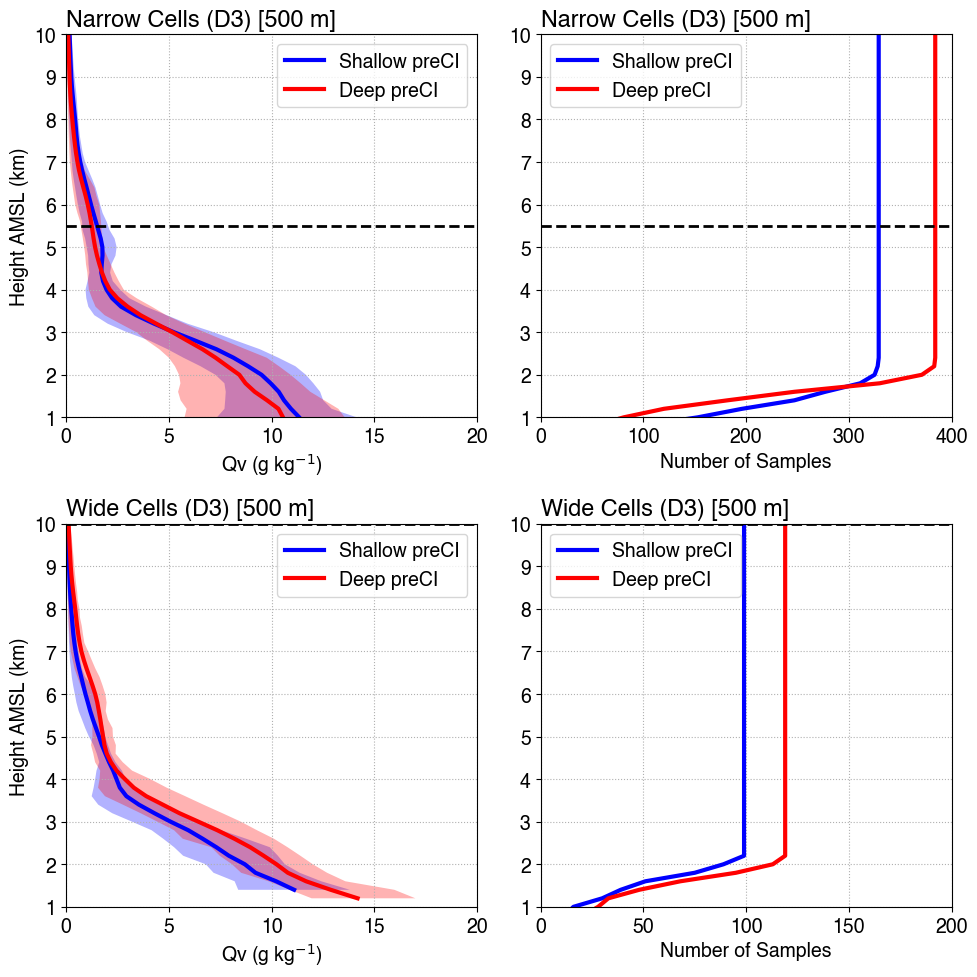

In [151]:
prof = [
    [{'d':qv_narrow_deep_avg_d3.where(ns_narrow_deep_prof_d3 > min_ns_prof)*1e3, 's':qv_narrow_shallow_avg_d3.where(ns_narrow_shallow_prof_d3 > min_ns_prof)*1e3},
     {'d':ns_narrow_deep_prof_d3, 's':ns_narrow_shallow_prof_d3}],
    [{'d':qv_wide_deep_avg_d3.where(ns_wide_deep_prof_d3 > min_ns_prof)*1e3, 's':qv_wide_shallow_avg_d3.where(ns_wide_shallow_prof_d3 > min_ns_prof)*1e3},
     {'d':ns_wide_deep_prof_d3, 's':ns_wide_shallow_prof_d3}],
]
z_thresh = [narrow_maxETH10dbz_thresh_d3, wide_maxETH10dbz_thresh_d3]
inqt25_w_d = qv_wide_deep_inqt_d3.sel(quantile=0.25).where(ns_wide_deep_prof_d3 > min_ns_prof)*1e3
inqt75_w_d = qv_wide_deep_inqt_d3.sel(quantile=0.75).where(ns_wide_deep_prof_d3 > min_ns_prof)*1e3
inqt25_w_s = qv_wide_shallow_inqt_d3.sel(quantile=0.25).where(ns_wide_shallow_prof_d3 > min_ns_prof)*1e3
inqt75_w_s = qv_wide_shallow_inqt_d3.sel(quantile=0.75).where(ns_wide_shallow_prof_d3 > min_ns_prof)*1e3
inqt25_n_d = qv_narrow_deep_inqt_d3.sel(quantile=0.25).where(ns_narrow_deep_prof_d3 > min_ns_prof)*1e3
inqt75_n_d = qv_narrow_deep_inqt_d3.sel(quantile=0.75).where(ns_narrow_deep_prof_d3 > min_ns_prof)*1e3
inqt25_n_s = qv_narrow_shallow_inqt_d3.sel(quantile=0.25).where(ns_narrow_shallow_prof_d3 > min_ns_prof)*1e3
inqt75_n_s = qv_narrow_shallow_inqt_d3.sel(quantile=0.75).where(ns_narrow_shallow_prof_d3 > min_ns_prof)*1e3
inqt = [{'d':(inqt25_n_d, inqt75_n_d), 's':(inqt25_n_s, inqt75_n_s)}, {'d':(inqt25_w_d, inqt75_w_d), 's':(inqt25_w_s, inqt75_w_s)}, ]
nrow = len(prof)
ncol = len(prof[0])
# nrow, ncol
xlabels = [
    ['Qv (g kg$^{-1}$)', 'Number of Samples'],
    ['Qv (g kg$^{-1}$)', 'Number of Samples'],
]
ylabels = [
    ['Height AMSL (km)', ''],
    ['Height AMSL (km)', ''],
]
titles = [
    ['Narrow Cells (D3) [500 m]', 'Narrow Cells (D3) [500 m]'],
    ['Wide Cells (D3) [500 m]', 'Wide Cells (D3) [500 m]'],
]
ylims = (1,10)
# xlims = None
xlims = [
    [(0, 20), (0,400)],
    [(0, 20), (0,200)],
]
fontsize = 14
figsize = [10, 10]
figname = f'{figdir}PreCI_Profile_NarrowWide_qv_d3.png'
fig = plot_mxn_prof(nrow, ncol, prof, inqt, height/1e3, z_thresh=z_thresh,
                    xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

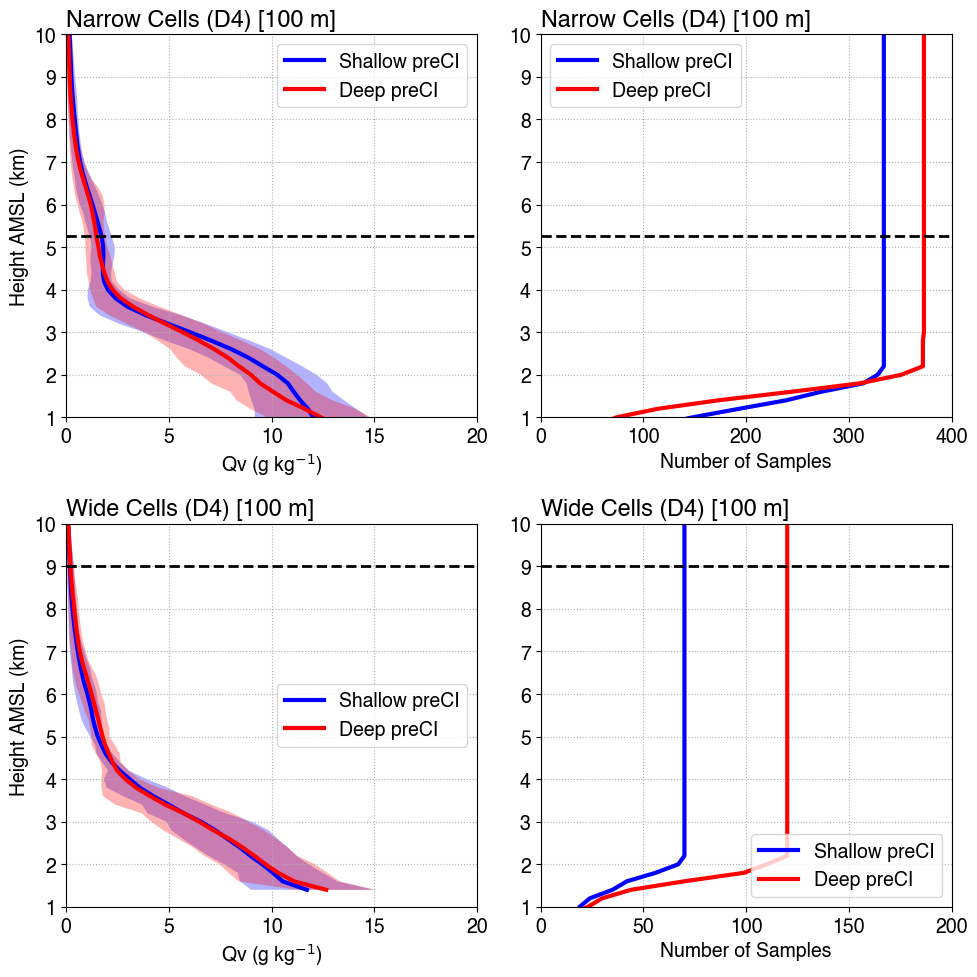

In [152]:
prof = [
    [{'d':qv_narrow_deep_avg_d4.where(ns_narrow_deep_prof_d4 > min_ns_prof)*1e3, 's':qv_narrow_shallow_avg_d4.where(ns_narrow_shallow_prof_d4 > min_ns_prof)*1e3},
     {'d':ns_narrow_deep_prof_d4, 's':ns_narrow_shallow_prof_d4}],
    [{'d':qv_wide_deep_avg_d4.where(ns_wide_deep_prof_d4 > min_ns_prof)*1e3, 's':qv_wide_shallow_avg_d4.where(ns_wide_shallow_prof_d4 > min_ns_prof)*1e3},
     {'d':ns_wide_deep_prof_d4, 's':ns_wide_shallow_prof_d4}],
]
z_thresh = [narrow_maxETH10dbz_thresh_d4, wide_maxETH10dbz_thresh_d4]
inqt25_w_d = qv_wide_deep_inqt_d4.sel(quantile=0.25).where(ns_wide_deep_prof_d4 > min_ns_prof)*1e3
inqt75_w_d = qv_wide_deep_inqt_d4.sel(quantile=0.75).where(ns_wide_deep_prof_d4 > min_ns_prof)*1e3
inqt25_w_s = qv_wide_shallow_inqt_d4.sel(quantile=0.25).where(ns_wide_shallow_prof_d4 > min_ns_prof)*1e3
inqt75_w_s = qv_wide_shallow_inqt_d4.sel(quantile=0.75).where(ns_wide_shallow_prof_d4 > min_ns_prof)*1e3
inqt25_n_d = qv_narrow_deep_inqt_d4.sel(quantile=0.25).where(ns_narrow_deep_prof_d4 > min_ns_prof)*1e3
inqt75_n_d = qv_narrow_deep_inqt_d4.sel(quantile=0.75).where(ns_narrow_deep_prof_d4 > min_ns_prof)*1e3
inqt25_n_s = qv_narrow_shallow_inqt_d4.sel(quantile=0.25).where(ns_narrow_shallow_prof_d4 > min_ns_prof)*1e3
inqt75_n_s = qv_narrow_shallow_inqt_d4.sel(quantile=0.75).where(ns_narrow_shallow_prof_d4 > min_ns_prof)*1e3
inqt = [{'d':(inqt25_n_d, inqt75_n_d), 's':(inqt25_n_s, inqt75_n_s)}, {'d':(inqt25_w_d, inqt75_w_d), 's':(inqt25_w_s, inqt75_w_s)}, ]
nrow = len(prof)
ncol = len(prof[0])
# nrow, ncol
xlabels = [
    ['Qv (g kg$^{-1}$)', 'Number of Samples'],
    ['Qv (g kg$^{-1}$)', 'Number of Samples'],
]
ylabels = [
    ['Height AMSL (km)', ''],
    ['Height AMSL (km)', ''],
]
titles = [
    ['Narrow Cells (D4) [100 m]', 'Narrow Cells (D4) [100 m]'],
    ['Wide Cells (D4) [100 m]', 'Wide Cells (D4) [100 m]'],
]
ylims = (1,10)
# xlims = None
xlims = [
    [(0, 20), (0,400)],
    [(0, 20), (0,200)],
]
fontsize = 14
figsize = [10, 10]
figname = f'{figdir}PreCI_Profile_NarrowWide_qv_d4.png'
fig = plot_mxn_prof(nrow, ncol, prof, inqt, height/1e3, z_thresh=z_thresh,
                    xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

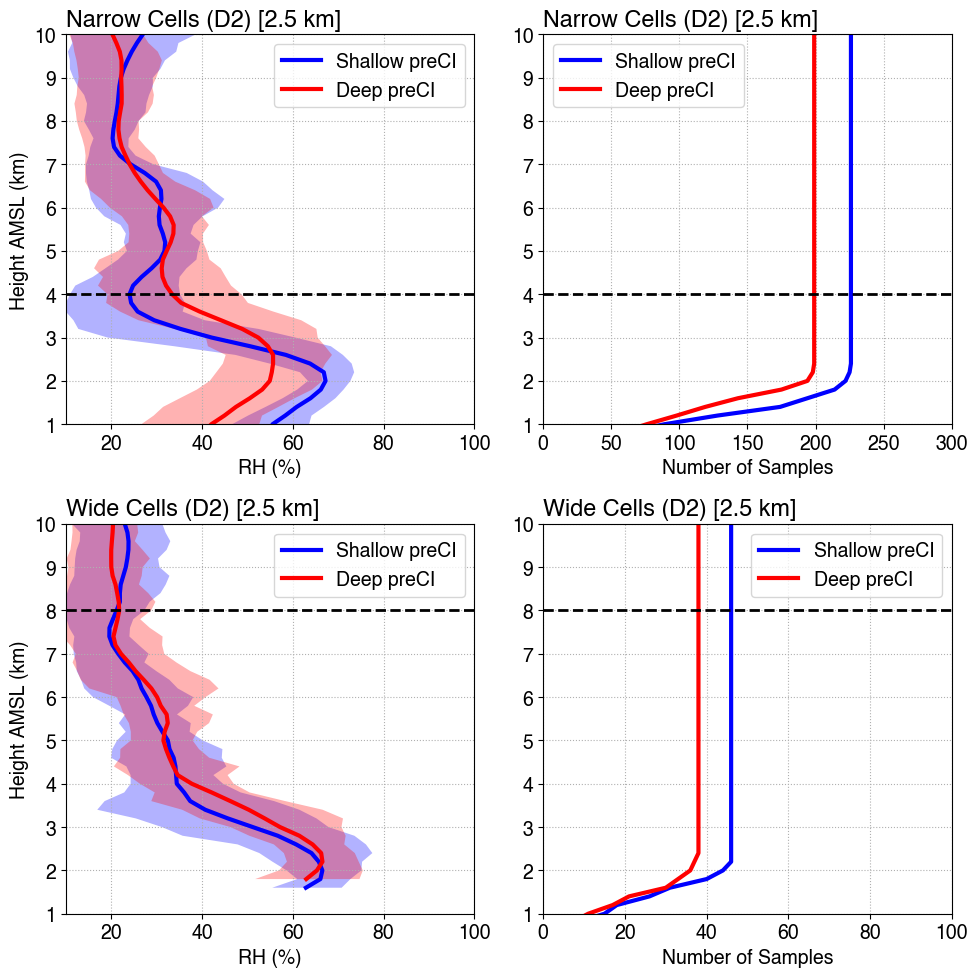

In [153]:
prof = [
    [{'d':rh_narrow_deep_avg_d2.where(ns_narrow_deep_prof_d2 > min_ns_prof), 's':rh_narrow_shallow_avg_d2.where(ns_narrow_shallow_prof_d2 > min_ns_prof)},
     {'d':ns_narrow_deep_prof_d2, 's':ns_narrow_shallow_prof_d2}],
    [{'d':rh_wide_deep_avg_d2.where(ns_wide_deep_prof_d2 > min_ns_prof), 's':rh_wide_shallow_avg_d2.where(ns_wide_shallow_prof_d2 > min_ns_prof)},
     {'d':ns_wide_deep_prof_d2, 's':ns_wide_shallow_prof_d2}],
]
z_thresh = [narrow_maxETH10dbz_thresh_d2, wide_maxETH10dbz_thresh_d2]
inqt25_w_d = rh_wide_deep_inqt_d2.sel(quantile=0.25).where(ns_wide_deep_prof_d2 > min_ns_prof)
inqt75_w_d = rh_wide_deep_inqt_d2.sel(quantile=0.75).where(ns_wide_deep_prof_d2 > min_ns_prof)
inqt25_w_s = rh_wide_shallow_inqt_d2.sel(quantile=0.25).where(ns_wide_shallow_prof_d2 > min_ns_prof)
inqt75_w_s = rh_wide_shallow_inqt_d2.sel(quantile=0.75).where(ns_wide_shallow_prof_d2 > min_ns_prof)
inqt25_n_d = rh_narrow_deep_inqt_d2.sel(quantile=0.25).where(ns_narrow_deep_prof_d2 > min_ns_prof)
inqt75_n_d = rh_narrow_deep_inqt_d2.sel(quantile=0.75).where(ns_narrow_deep_prof_d2 > min_ns_prof)
inqt25_n_s = rh_narrow_shallow_inqt_d2.sel(quantile=0.25).where(ns_narrow_shallow_prof_d2 > min_ns_prof)
inqt75_n_s = rh_narrow_shallow_inqt_d2.sel(quantile=0.75).where(ns_narrow_shallow_prof_d2 > min_ns_prof)
inqt = [{'d':(inqt25_n_d, inqt75_n_d), 's':(inqt25_n_s, inqt75_n_s)}, {'d':(inqt25_w_d, inqt75_w_d), 's':(inqt25_w_s, inqt75_w_s)}, ]
nrow = len(prof)
ncol = len(prof[0])
# nrow, ncol
xlabels = [
    ['RH (%)', 'Number of Samples'],
    ['RH (%)', 'Number of Samples'],
]
ylabels = [
    ['Height AMSL (km)', ''],
    ['Height AMSL (km)', ''],
]
titles = [
    ['Narrow Cells (D2) [2.5 km]', 'Narrow Cells (D2) [2.5 km]'],
    ['Wide Cells (D2) [2.5 km]', 'Wide Cells (D2) [2.5 km]'],
]
ylims = (1,10)
# xlims = None
xlims = [
    [(10, 100), (0,300)],
    [(10, 100), (0,100)],
]
fontsize = 14
figsize = [10, 10]
figname = f'{figdir}PreCI_Profile_NarrowWide_rh_d2.png'
fig = plot_mxn_prof(nrow, ncol, prof, inqt, height/1e3, z_thresh=z_thresh,
                    xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

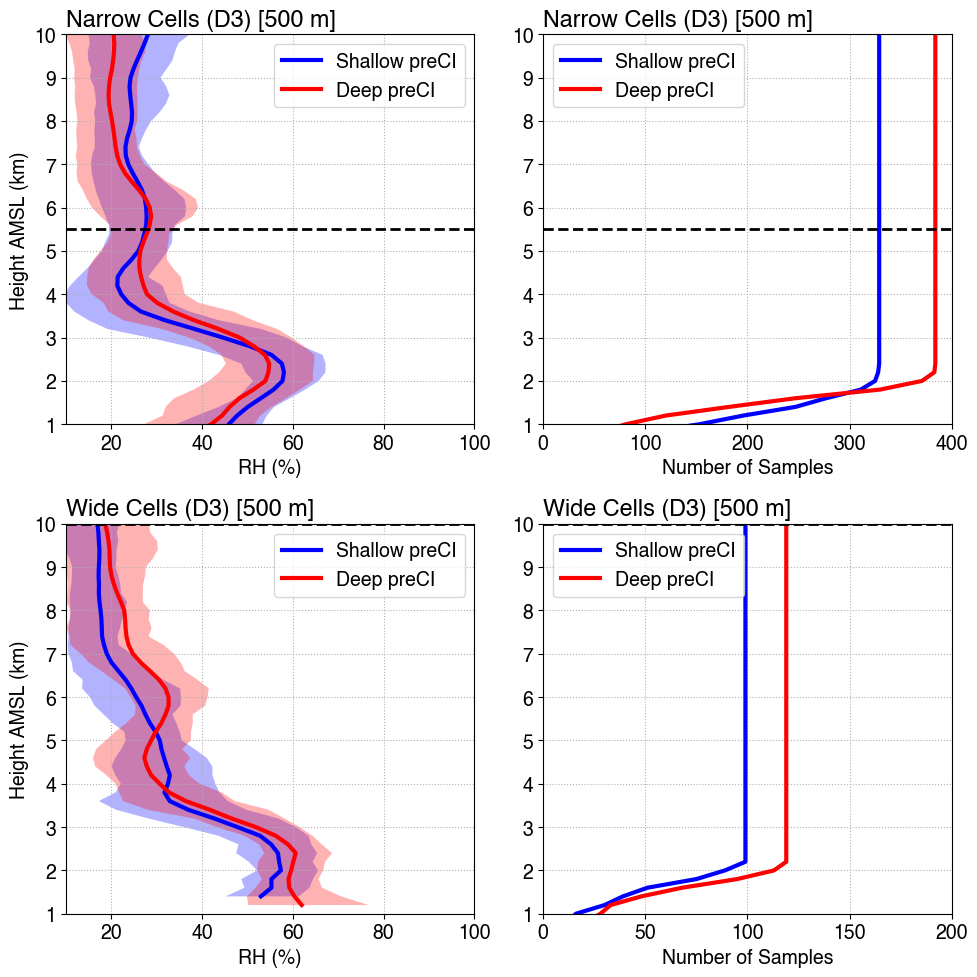

In [154]:
prof = [
    [{'d':rh_narrow_deep_avg_d3.where(ns_narrow_deep_prof_d3 > min_ns_prof), 's':rh_narrow_shallow_avg_d3.where(ns_narrow_shallow_prof_d3 > min_ns_prof)},
     {'d':ns_narrow_deep_prof_d3, 's':ns_narrow_shallow_prof_d3}],
    [{'d':rh_wide_deep_avg_d3.where(ns_wide_deep_prof_d3 > min_ns_prof), 's':rh_wide_shallow_avg_d3.where(ns_wide_shallow_prof_d3 > min_ns_prof)},
     {'d':ns_wide_deep_prof_d3, 's':ns_wide_shallow_prof_d3}],
]
z_thresh = [narrow_maxETH10dbz_thresh_d3, wide_maxETH10dbz_thresh_d3]
inqt25_w_d = rh_wide_deep_inqt_d3.sel(quantile=0.25).where(ns_wide_deep_prof_d3 > min_ns_prof)
inqt75_w_d = rh_wide_deep_inqt_d3.sel(quantile=0.75).where(ns_wide_deep_prof_d3 > min_ns_prof)
inqt25_w_s = rh_wide_shallow_inqt_d3.sel(quantile=0.25).where(ns_wide_shallow_prof_d3 > min_ns_prof)
inqt75_w_s = rh_wide_shallow_inqt_d3.sel(quantile=0.75).where(ns_wide_shallow_prof_d3 > min_ns_prof)
inqt25_n_d = rh_narrow_deep_inqt_d3.sel(quantile=0.25).where(ns_narrow_deep_prof_d3 > min_ns_prof)
inqt75_n_d = rh_narrow_deep_inqt_d3.sel(quantile=0.75).where(ns_narrow_deep_prof_d3 > min_ns_prof)
inqt25_n_s = rh_narrow_shallow_inqt_d3.sel(quantile=0.25).where(ns_narrow_shallow_prof_d3 > min_ns_prof)
inqt75_n_s = rh_narrow_shallow_inqt_d3.sel(quantile=0.75).where(ns_narrow_shallow_prof_d3 > min_ns_prof)
inqt = [{'d':(inqt25_n_d, inqt75_n_d), 's':(inqt25_n_s, inqt75_n_s)}, {'d':(inqt25_w_d, inqt75_w_d), 's':(inqt25_w_s, inqt75_w_s)}, ]
nrow = len(prof)
ncol = len(prof[0])
# nrow, ncol
xlabels = [
    ['RH (%)', 'Number of Samples'],
    ['RH (%)', 'Number of Samples'],
]
ylabels = [
    ['Height AMSL (km)', ''],
    ['Height AMSL (km)', ''],
]
titles = [
    ['Narrow Cells (D3) [500 m]', 'Narrow Cells (D3) [500 m]'],
    ['Wide Cells (D3) [500 m]', 'Wide Cells (D3) [500 m]'],
]
ylims = (1,10)
# xlims = None
xlims = [
    [(10, 100), (0,400)],
    [(10, 100), (0,200)],
]
fontsize = 14
figsize = [10, 10]
figname = f'{figdir}PreCI_Profile_NarrowWide_rh_d3.png'
fig = plot_mxn_prof(nrow, ncol, prof, inqt, height/1e3, z_thresh=z_thresh,
                    xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

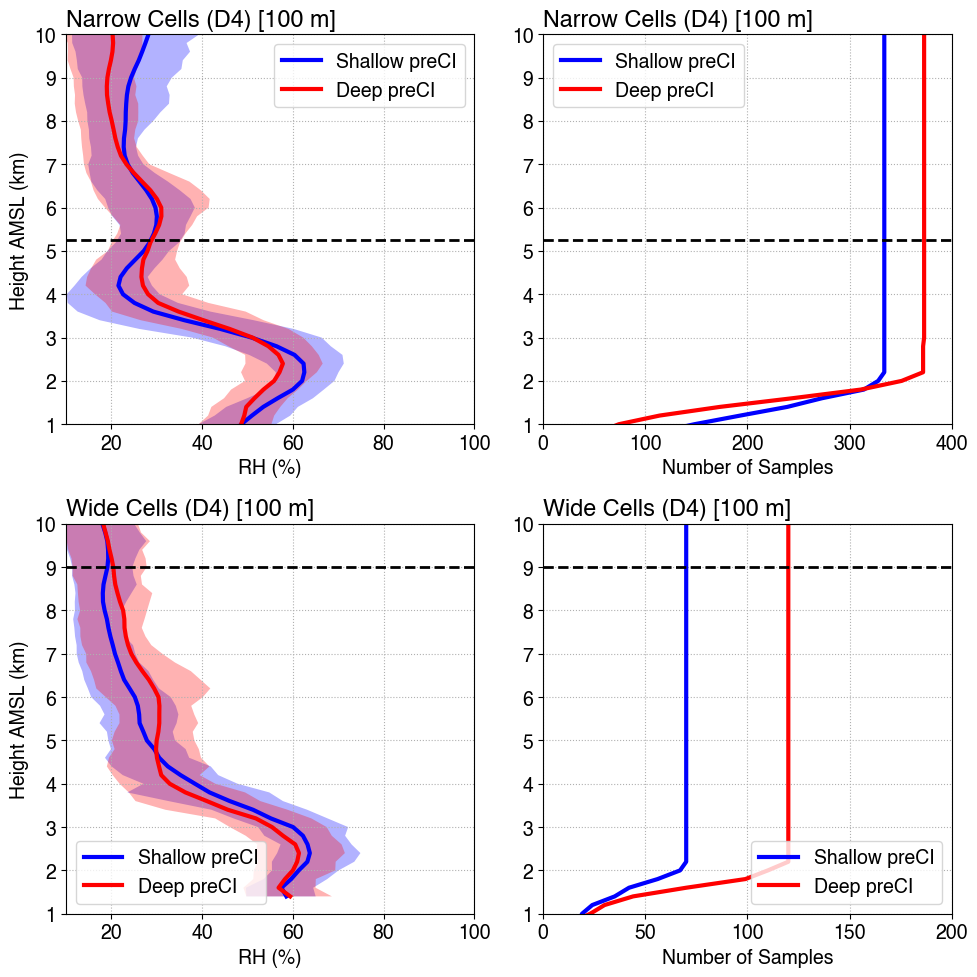

In [155]:
prof = [
    [{'d':rh_narrow_deep_avg_d4.where(ns_narrow_deep_prof_d4 > min_ns_prof), 's':rh_narrow_shallow_avg_d4.where(ns_narrow_shallow_prof_d4 > min_ns_prof)},
     {'d':ns_narrow_deep_prof_d4, 's':ns_narrow_shallow_prof_d4}],
    [{'d':rh_wide_deep_avg_d4.where(ns_wide_deep_prof_d4 > min_ns_prof), 's':rh_wide_shallow_avg_d4.where(ns_wide_shallow_prof_d4 > min_ns_prof)},
     {'d':ns_wide_deep_prof_d4, 's':ns_wide_shallow_prof_d4}],
]
z_thresh = [narrow_maxETH10dbz_thresh_d4, wide_maxETH10dbz_thresh_d4]
inqt25_w_d = rh_wide_deep_inqt_d4.sel(quantile=0.25).where(ns_wide_deep_prof_d4 > min_ns_prof)
inqt75_w_d = rh_wide_deep_inqt_d4.sel(quantile=0.75).where(ns_wide_deep_prof_d4 > min_ns_prof)
inqt25_w_s = rh_wide_shallow_inqt_d4.sel(quantile=0.25).where(ns_wide_shallow_prof_d4 > min_ns_prof)
inqt75_w_s = rh_wide_shallow_inqt_d4.sel(quantile=0.75).where(ns_wide_shallow_prof_d4 > min_ns_prof)
inqt25_n_d = rh_narrow_deep_inqt_d4.sel(quantile=0.25).where(ns_narrow_deep_prof_d4 > min_ns_prof)
inqt75_n_d = rh_narrow_deep_inqt_d4.sel(quantile=0.75).where(ns_narrow_deep_prof_d4 > min_ns_prof)
inqt25_n_s = rh_narrow_shallow_inqt_d4.sel(quantile=0.25).where(ns_narrow_shallow_prof_d4 > min_ns_prof)
inqt75_n_s = rh_narrow_shallow_inqt_d4.sel(quantile=0.75).where(ns_narrow_shallow_prof_d4 > min_ns_prof)
inqt = [{'d':(inqt25_n_d, inqt75_n_d), 's':(inqt25_n_s, inqt75_n_s)}, {'d':(inqt25_w_d, inqt75_w_d), 's':(inqt25_w_s, inqt75_w_s)}, ]
nrow = len(prof)
ncol = len(prof[0])
# nrow, ncol
xlabels = [
    ['RH (%)', 'Number of Samples'],
    ['RH (%)', 'Number of Samples'],
]
ylabels = [
    ['Height AMSL (km)', ''],
    ['Height AMSL (km)', ''],
]
titles = [
    ['Narrow Cells (D4) [100 m]', 'Narrow Cells (D4) [100 m]'],
    ['Wide Cells (D4) [100 m]', 'Wide Cells (D4) [100 m]'],
]
ylims = (1,10)
# xlims = None
xlims = [
    [(10, 100), (0,400)],
    [(10, 100), (0,200)],
]
fontsize = 14
figsize = [10, 10]
figname = f'{figdir}PreCI_Profile_NarrowWide_rh_d4.png'
fig = plot_mxn_prof(nrow, ncol, prof, inqt, height/1e3, z_thresh=z_thresh,
                    xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)